In [1]:
# =============================================================================
# 🔨 06_TheForge.ipynb — Cell 1: 환경 + 팩터 레지스트리 + 레짐별 매핑
# =============================================================================
#
# [목적]
# 멀티팩터 조합 모델 구축
# 05_Factor v4 재검증 결과를 기반으로 레짐별 팩터 조합 설계
#
# [구조]
# Cell 1: 환경 + 팩터 레지스트리 + 레짐 매핑 (← 여기)
# Cell 2: 전 팩터 시그널 로드 + 통합 패널
# Cell 3: 팩터 간 상관 매트릭스 (미확인 쌍 포함)
# Cell 4: Phase 2 — 레짐별 동일가중 조합 백테스트 (베이스라인)
# Cell 5: Phase 3 — Bear 자산배분 레이어 (현금/채권 비중)
# Cell 6: Phase 4 — 이벤트 트리거 (G-1, T-1) 오버레이
# Cell 7: Phase 5 — 거래비용 민감도 + Walk-Forward
# Cell 8: 최종 결론 주석
#
# [핵심 설계 원칙]
# 1. H는 always-on 베이스 팩터 (전 레짐 WIN, t=12.3/7.7)
# 2. 레짐 스위치에 따라 보조 팩터 on/off
# 3. Bear 구간: 팩터 틸트(종목선정) + 자산배분(현금/채권) 분리
# 4. 이벤트 트리거(G-1, T-1)는 Core 스코어 가감 방식
# 5. 처음은 동일가중 → 과최적화 금지
#
# [레짐 체계]
# regime_v4 (3레짐 + bear_phase 보조):
#   Bull:    S&P500 > 10M SMA (상승장)
#   Bear:    S&P500 < 10M SMA (하락장)
#   Neutral: Bear→Bull 전환 후 3개월 이내
#   bear_phase: declining(MA 하향) / recovering(MA 상향)
#
# [v2→v4 레짐 매핑 참고]
#   v2 Expansion, Peak, Recovery_Late → v4 Bull
#   v2 Contraction, Crash             → v4 Bear
#   v2 Neutral, Recovery_Early        → v4 Neutral (정확히 1:1은 아님, 주의)
#   ⚠ v4에서는 v2의 세분화를 포기하고 단순화한 대신
#      bear_phase로 Bear 내부를 구분
#
# [백테스트 기간]
# 2013-06 ~ 2026-02 (약 151개월)
# 유니버스: 503 tickers (S&P500 + 과거 구성종목)
# 벤치마크: EW (동일가중)
# 거래비용: 20bp 편도 기준
# 리밸런싱: 월말 (이벤트 트리거 제외)
# Top N: 30 (기본)
# =============================================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ─── 경로 (SSOT) ─────────────────────────────────────────────────────────────
QP2_ROOT = Path(r"C:\QP2")
DATA_DIR = QP2_ROOT / "data"
RAW_DIR  = DATA_DIR / "raw"
INTERIM  = DATA_DIR / "interim"
META_DIR = DATA_DIR / "meta"

PATHS = dict(
    px_wide     = INTERIM / "yahoo_adjclose_wide.parquet",
    ret_1m      = INTERIM / "ret_1m_wide.parquet",       # 월간 수익률 wide
    fund_q      = INTERIM / "fundamentals_quarterly.parquet",
    mktcap_m    = INTERIM / "mktcap_monthly.parquet",
    regime_v4   = INTERIM / "regime_v4.parquet",          # ★ v4 레짐
    regime_v2   = INTERIM / "regime_indicators_combined.parquet",  # 참고용
    universe    = META_DIR / "sp500_universe.parquet",
    fscore      = INTERIM / "fscore_signal.parquet",
    nsi         = INTERIM / "nsi_annual.parquet",
    insider     = INTERIM / "insider_mspr.parquet",
    p7_panel    = INTERIM / "p7_signal_panel.parquet",
)

# ─── 글로벌 파라미터 ──────────────────────────────────────────────────────────
TOP_N       = 30        # 포트폴리오 종목 수
COST_BP     = 20        # 편도 거래비용 (bp)
REBAL_FREQ  = "ME"      # 월말 리밸런싱
BT_START    = "2013-06"
BT_END      = "2026-02"

# ─── 유틸리티 함수 ────────────────────────────────────────────────────────────
def winsorize(s, lower=0.01, upper=0.99):
    """시리즈 윈저라이즈 (cross-sectional에서 날짜별로 사용)"""
    lo, hi = s.quantile(lower), s.quantile(upper)
    return s.clip(lo, hi)

def zscore_by_date(df, col, group_col="date"):
    """날짜별 횡단면 z-score"""
    return df.groupby(group_col)[col].transform(
        lambda x: (x - x.mean()) / x.std()
    )

def calc_perf(cum_ret):
    """누적수익률 시리즈 → CAGR, Sharpe, MaxDD"""
    total = cum_ret.iloc[-1] / cum_ret.iloc[0]
    years = len(cum_ret) / 12
    cagr  = total ** (1/years) - 1
    monthly_ret = cum_ret.pct_change().dropna()
    sharpe = monthly_ret.mean() / monthly_ret.std() * np.sqrt(12) if monthly_ret.std() > 0 else 0
    dd = cum_ret / cum_ret.cummax() - 1
    maxdd = dd.min()
    return {"CAGR": cagr, "Sharpe": sharpe, "MaxDD": maxdd}

def calc_tstat(excess_monthly):
    """월간 초과수익률 → t-stat"""
    n = len(excess_monthly)
    if n < 3:
        return 0.0
    return excess_monthly.mean() / (excess_monthly.std() / np.sqrt(n))

def backtest_topn(signal_wide, ret_wide, n=TOP_N, cost_bp=COST_BP):
    """
    Top-N EW 포트폴리오 백테스트
    signal_wide: date × ticker (z-score, 높을수록 좋음)
    ret_wide:    date × ticker (월간 수익률)
    Returns: DataFrame with port_ret, bm_ret, excess, cum_port, cum_bm
    """
    common_dates = signal_wide.index.intersection(ret_wide.index)
    common_dates = sorted(common_dates)
    
    results = []
    prev_holdings = set()
    
    for i, dt in enumerate(common_dates[:-1]):
        next_dt = common_dates[i + 1]
        
        # 시그널 기준 Top N 선정
        scores = signal_wide.loc[dt].dropna()
        if len(scores) < n:
            continue
        top_n = scores.nlargest(n).index.tolist()
        
        # 수익률
        rets = ret_wide.loc[next_dt, top_n].dropna()
        if len(rets) == 0:
            continue
        port_ret = rets.mean()
        bm_ret   = ret_wide.loc[next_dt].dropna().mean()
        
        # 거래비용 (턴오버 기반)
        curr_set = set(top_n)
        if prev_holdings:
            turnover = len(curr_set - prev_holdings) / n
        else:
            turnover = 1.0
        cost = turnover * cost_bp * 2 / 10000  # 편도 × 2 (매수+매도)
        
        results.append({
            "date": next_dt,
            "port_ret_gross": port_ret,
            "port_ret_net": port_ret - cost,
            "bm_ret": bm_ret,
            "turnover": turnover,
            "n_stocks": len(rets),
        })
        prev_holdings = curr_set
    
    df = pd.DataFrame(results).set_index("date")
    df["excess_gross"] = df["port_ret_gross"] - df["bm_ret"]
    df["excess_net"]   = df["port_ret_net"] - df["bm_ret"]
    df["cum_port"]     = (1 + df["port_ret_net"]).cumprod()
    df["cum_bm"]       = (1 + df["bm_ret"]).cumprod()
    return df


# =============================================================================
# ★ 팩터 레지스트리 — v4 재검증 최종 결과 기반
# =============================================================================
#
# 각 팩터의 메타데이터를 딕셔너리로 정의.
# 멀티팩터 조합 시 이 레지스트리를 참조하여 on/off, 가중치 등을 결정.
#
# 필드 설명:
#   name:        팩터 ID
#   desc:        한줄 설명
#   type:        "score" (z-score 기반, 합산 가능) / "filter" (이진, 종목 제외용)
#                / "event" (이벤트 트리거, 비정기)
#   direction:   "long" (높을수록 좋음) / "short" (낮을수록 좋음)
#   regimes:     유효 레짐 리스트 ["Bull", "Bear", "Neutral"]
#   role:        "main" / "aux" / "filter" / "avoid"
#   rebal:       "monthly" / "event"
#   tstat:       v4 재검증 대표 t-stat (레짐별 최고값)
#   params:      주요 파라미터
#   signal_src:  시그널 생성 소스 (어디서 로드/계산하는지)
#   note:        특이사항
#
# ⚠ 이 레지스트리는 "설계 사양서"이지 코드가 아님.
#    Cell 2에서 실제 시그널을 로드하고,
#    Cell 4에서 이 매핑대로 조합한다.
# =============================================================================

FACTOR_REGISTRY = {
    # ── always-on ──────────────────────────────────────────────────────────
    "H": {
        "desc":      "섹터 모멘텀 (3M lookback)",
        "type":      "score",
        "direction": "long",
        "regimes":   ["Bull", "Bear", "Neutral"],   # 전 레짐 WIN
        "role":      "main",
        "rebal":     "monthly",
        "tstat":     {"Bull": 12.3, "Bear": 7.7, "Neutral": 2.16},
        "params":    {"lookback_m": 3},
        "signal_src": "02_H.ipynb → h_z_wide (date×ticker z-score)",
        "note":      "MVP. IT 편향 주의. 전 레짐 베이스로 항상 ON.",
    },
    
    # ── Bull 팩터 ──────────────────────────────────────────────────────────
    "T-1": {
        "desc":      "리더 급등 spillover (Bull 전용 가산)",
        "type":      "event",
        "direction": "long",
        "regimes":   ["Bull"],
        "role":      "aux",
        "rebal":     "event",   # hold=7d, 비정기
        "tstat":     {"Bull": 3.21},
        "params":    {"surge_sigma": 2.5, "hold_d": 7, "tier": "Top_Q4"},
        "signal_src": "02_T-1.ipynb → 인라인 계산 (일간 이벤트)",
        "note":      "Core 스코어에 z-score 가산. 리밸런싱 시 직전 7일 이벤트 체크.",
    },
    "P-7": {
        "desc":      "Net Stock Issuance (자사주 매입 = 높은 점수)",
        "type":      "score",
        "direction": "long",
        "regimes":   ["Bull"],
        "role":      "aux",
        "rebal":     "monthly",
        "tstat":     {"Bull": 2.43},
        "params":    {"n_top": 50},   # N=50에서 t=2.20
        "signal_src": "02_P-7.ipynb → nsi_score (nsi_annual.parquet)",
        "note":      "회전율 7.4%로 공짜에 가까움. Crash에서 역작동 주의.",
    },
    "G-1_bull": {
        "desc":      "급락 반전 매수 (Bull, lookback=3M)",
        "type":      "event",
        "direction": "long",
        "regimes":   ["Bull"],
        "role":      "aux",
        "rebal":     "monthly",   # hold=20 → 사실상 월간
        "tstat":     {"Bull": 2.55},
        "params":    {"lookback_m": 3, "hold_d": 20},
        "signal_src": "05_G-1.ipynb → 인라인 계산",
        "note":      "hold=20이라 월간 리밸런싱에 편입 가능.",
    },
    
    # ── Bear 팩터 ──────────────────────────────────────────────────────────
    "A-3": {
        "desc":      "Value × Catalyst (저평가+개선 기업)",
        "type":      "score",
        "direction": "long",
        "regimes":   ["Bear"],
        "role":      "main",
        "rebal":     "monthly",
        "tstat":     {"Bear": 2.21},
        "params":    {"lag_days": 45, "value_filter_pct": 0.5},
        "signal_src": "02_A.ipynb → signal_df (value_filter + catalyst_z)",
        "note":      "큰 알파(+72.6%) but 큰 변동. Bear 메인이지만 현금/채권이 우월함을 잊지 말 것.",
    },
    "G-1_bear": {
        "desc":      "급락 반전 매수 (Bear, lookback=5M)",
        "type":      "event",
        "direction": "long",
        "regimes":   ["Bear"],
        "role":      "aux",
        "rebal":     "monthly",
        "tstat":     {"Bear": 7.78},
        "params":    {"lookback_m": 5, "hold_d": 20},
        "signal_src": "05_G-1.ipynb → 인라인 계산",
        "note":      "v4 재검증 최고 t-stat. Bear 급락 반전 시 강력.",
    },
    "P-5": {
        "desc":      "저베타 (Betting Against Beta)",
        "type":      "score",
        "direction": "long",   # 저베타 = 높은 BAB score
        "regimes":   ["Bear"],
        "role":      "stability",
        "rebal":     "monthly",
        "tstat":     {"Bear": 4.25},
        "params":    {"window_m": 12},
        "signal_src": "05_E_P5.ipynb → beta_long → -beta z-score",
        "note":      "v4 부활. Bear CAGR=-18.21%로 '덜 잃기'. 회전율 10.8%.",
    },
    "E-5": {
        "desc":      "저변동 (Low Idiosyncratic Vol)",
        "type":      "score",
        "direction": "long",   # 저변동 = 높은 점수
        "regimes":   ["Bear"],
        "role":      "stability",
        "rebal":     "monthly",
        "tstat":     {"Bear": 4.70},
        "params":    {"window_m": 6},
        "signal_src": "05_E_P5.ipynb → ivol → -ivol z-score",
        "note":      "v4 부활. P-5와 상관 -0.37 (반대 방향 → 분산 효과).",
    },
    "D-1": {
        "desc":      "단순 모멘텀 12-1 (Bear 보조)",
        "type":      "score",
        "direction": "long",
        "regimes":   ["Bear"],
        "role":      "aux",
        "rebal":     "monthly",
        "tstat":     {"Bear": 0.18},
        "params":    {"lookback": "MOM_12_1"},
        "signal_src": "02_D.ipynb → mom_signals['MOM_12_1']",
        "note":      "방향 맞지만 불안정 (t=0.18). 보조로만.",
    },
    "G-1b": {
        "desc":      "급등 회피 시그널 (Bear/Neutral)",
        "type":      "filter",
        "direction": "short",  # 급등 종목 회피 → 낮을수록 좋음(=감점)
        "regimes":   ["Bear", "Neutral"],
        "role":      "avoid",
        "rebal":     "monthly",
        "tstat":     {"Bear": -2.05, "Neutral": -2.31},
        "params":    {},
        "signal_src": "05_G-1.ipynb → 급등 종목 플래그",
        "note":      "Bear에서 급등=함정. 합산 스코어에서 감점 처리.",
    },
    
    # ── Neutral 팩터 ───────────────────────────────────────────────────────
    "D-3": {
        "desc":      "변동성 조정 모멘텀 (MOM_3_1 / VOL)",
        "type":      "score",
        "direction": "long",
        "regimes":   ["Neutral"],
        "role":      "main",
        "rebal":     "monthly",
        "tstat":     {"Neutral": 2.52},   # Sharpe 기준
        "params":    {"lookback": "MOM_3_1", "vol_window": "6M"},
        "signal_src": "02_D.ipynb → mom_vol_adj (MOM_3_1/VOL)",
        "note":      "v4에서 MOM_3_1/VOL로 재정의. Neutral 메인.",
    },
    
    # ── 리스크 필터 (단독 팩터 아님) ──────────────────────────────────────
    "F-1": {
        "desc":      "Piotroski F-score (리스크 필터)",
        "type":      "filter",
        "direction": "long",  # 높은 F-score = 건전
        "regimes":   ["Bear"],
        "role":      "filter",
        "rebal":     "monthly",
        "tstat":     {"Bear": 0.09},   # v4에서 대폭 약화
        "params":    {"version": "C", "lag_days": 0},
        "signal_src": "02_F.ipynb → fscore_signal.parquet",
        "note":      "v2 +11%p → v4 +0.4%. A-3 필터(저품질 제거)로 전환 고려.",
    },
}


# =============================================================================
# ★ 레짐별 팩터 매핑 — 06_Multi 설계 핵심
# =============================================================================
#
# 각 레짐에서 어떤 팩터를 어떤 역할로 사용할지 정의.
# Phase 2에서는 동일가중으로 시작 (weight는 나중에 최적화).
#
# 구조: {레짐: [팩터ID 리스트]}
# "score" 타입만 z-score 합산 대상.
# "filter" 타입은 합산 후 하위 종목 제외.
# "event" 타입은 합산 후 가산/감점.
# =============================================================================

REGIME_FACTOR_MAP = {
    "Bull": {
        "scores":  ["H", "G-1_bull", "P-7"],    # z-score 합산 (동일가중)
        "events":  ["T-1"],                       # 이벤트 시 가산
        "filters": [],                            # Bull에서는 필터 없음
        "avoids":  [],                            # Bull에서 급등 = 모멘텀 (회피 안 함)
    },
    "Bear": {
        "scores":  ["H", "A-3", "P-5", "E-5", "D-1"],  # z-score 합산
        "events":  ["G-1_bear"],                         # 급락 반전 시 가산
        "filters": ["F-1"],                              # 저품질 제거
        "avoids":  ["G-1b"],                             # 급등 종목 감점
    },
    "Neutral": {
        "scores":  ["H", "D-3"],                 # z-score 합산
        "events":  [],                            # Neutral은 이벤트 팩터 없음
        "filters": [],
        "avoids":  ["G-1b"],                      # 급등 종목 감점
    },
}

# =============================================================================
# ★ Bear 자산배분 파라미터 — Phase 3
# =============================================================================
#
# Bear에서 현금/채권 비중 조절 로직.
# 이진법(0/100)이 아니라 점진적 전환.
#
# Bear 진입:
#   1개월차 → cash_weight = 0.30
#   2개월차 → cash_weight = 0.50
#   3개월+ → cash_weight = 0.70 (최대)
#
# Bear 탈출 (bear_phase: declining → recovering):
#   recovering 1개월차 → cash_weight 한 단계 축소
#   Bull 확정(S&P > 10M SMA) → 한 단계 더 축소
#   2~3개월에 걸쳐 완전 복귀
#
# ⚠ Bear 팩터의 진짜 역할: 덜 잃기. 현금/채권(0%)이 모든 주식 전략보다 우월.
#    팩터 틸트는 "레짐 전환 초기" + "자산배분 결정 전 버퍼" 용도.
# =============================================================================

BEAR_ALLOC = {
    "bear_month_1": 0.30,   # 주식 70%
    "bear_month_2": 0.50,   # 주식 50%
    "bear_month_3+": 0.70,  # 주식 30% (최대 현금)
    "recovering_step": -0.20,  # recovering 전환 시 현금 비중 20%p 감소
    "bull_confirmed_step": -0.20,  # Bull 확정 시 추가 20%p 감소
    "min_cash": 0.0,        # 최소 현금 (Bull 확정 후)
    "max_cash": 0.70,       # 최대 현금
}

# =============================================================================
# ★ 이벤트 트리거 파라미터 — Phase 4
# =============================================================================
#
# 정기 리밸런싱(월말): H, A-3, D-3, P-5, E-5, P-7, D-1
# 이벤트 트리거: G-1(급락), T-1(리더 급등)
#
# 설계:
#   Core 스코어 = Σ(레짐별 score 팩터 z-scores) (동일가중)
#   이벤트 발생 시 → Core 스코어에 가산/감점 → 다음 리밸런싱에 반영
#   (별도 satellite 버킷 없음)
#
# T-1: Bull에서 리더 2.5σ 급등 → 해당 섹터 Top Q4 z-score +1.0 가산
#      Neutral에서 리더 2.5σ 급등 → Lag Q1 z-score -1.0 감점
# G-1: 급락 감지 시 → 해당 종목 z-score +1.0 가산
#
# 월말 리밸런싱 시, 직전 hold_d 이내 이벤트를 체크하여 반영.
# =============================================================================

EVENT_PARAMS = {
    "T-1a": {
        "regime": "Bull",
        "surge_sigma": 2.5,
        "hold_d": 7,
        "bonus_z": 1.0,        # Top Q4에 가산
        "tier": "Top_Q4",
    },
    "T-1b": {
        "regime": "Neutral",
        "surge_sigma": 2.5,
        "hold_d": 5,
        "penalty_z": -1.0,     # Lag Q1에 감점
        "tier": "Lag_Q1",
    },
    "G-1": {
        "regimes": ["Bull", "Bear"],
        "hold_d": 20,
        "bonus_z": 1.0,        # 급락 종목에 가산
    },
}

# =============================================================================
# ★ 미확인 상관 쌍 체크리스트
# =============================================================================
#
# 확인 완료:
#   P-5 vs E-5:   신호 -0.005, 수익 -0.37 → 독립 ✅
#   P-5 vs D:     신호 -0.056 → 독립 ✅
#   H vs D-3:     신호 0.22, 수익 0.70, 겹침 10% → 독립 ✅
#   H vs D-1:     신호 0.12, 수익 0.66, 겹침 10% → 독립 ✅
#   T-1 vs H:     신호 -0.004, 겹침 98.5% → 완전독립 ✅
#
# ⚠ 미확인 (Cell 3에서 반드시 확인):
#   G-1 vs D-1    — 방향 반대(급락반전 vs 모멘텀)일 가능성 높지만 미확인
#   G-1 vs P-5    — 이벤트성 vs 구조적 특성, 시간축 다름
#   G-1 vs E-5    — 위와 동일 논리
#   A-3 vs P-5    — accrual vs beta, 논리적 독립이나 미확인
#   A-3 vs E-5    — accrual vs ivol, 논리적 독립이나 미확인
#
# → Cell 3에서 상관 매트릭스 찍고 여기에 결과 업데이트할 것.
# =============================================================================

UNCHECKED_PAIRS = [
    ("G-1", "D-1"),
    ("G-1", "P-5"),
    ("G-1", "E-5"),
    ("A-3", "P-5"),
    ("A-3", "E-5"),
]

# ─── 확인 ─────────────────────────────────────────────────────────────────────
print("="*60)
print("🔨 06_TheForge — Cell 1 로드 완료")
print("="*60)
print(f"  팩터 레지스트리: {len(FACTOR_REGISTRY)}개")
print(f"  레짐: {list(REGIME_FACTOR_MAP.keys())}")
print(f"  미확인 상관 쌍: {len(UNCHECKED_PAIRS)}개")
print(f"  백테스트: {BT_START} ~ {BT_END}")
print(f"  거래비용: {COST_BP}bp 편도")
print()
for regime, mapping in REGIME_FACTOR_MAP.items():
    scores = mapping["scores"]
    events = mapping.get("events", [])
    filters = mapping.get("filters", [])
    avoids = mapping.get("avoids", [])
    print(f"  [{regime}]")
    print(f"    scores:  {scores}")
    if events:  print(f"    events:  {events}")
    if filters: print(f"    filters: {filters}")
    if avoids:  print(f"    avoids:  {avoids}")
    print()
print("→ Cell 2에서 전 팩터 시그널 로드 시작")

🔨 06_TheForge — Cell 1 로드 완료
  팩터 레지스트리: 12개
  레짐: ['Bull', 'Bear', 'Neutral']
  미확인 상관 쌍: 5개
  백테스트: 2013-06 ~ 2026-02
  거래비용: 20bp 편도

  [Bull]
    scores:  ['H', 'G-1_bull', 'P-7']
    events:  ['T-1']

  [Bear]
    scores:  ['H', 'A-3', 'P-5', 'E-5', 'D-1']
    events:  ['G-1_bear']
    filters: ['F-1']
    avoids:  ['G-1b']

  [Neutral]
    scores:  ['H', 'D-3']
    avoids:  ['G-1b']

→ Cell 2에서 전 팩터 시그널 로드 시작


In [2]:
# =============================================================================
# 🔨 06_TheForge.ipynb — Cell 2: 팩터 시그널 로드 + 통합 패널 + 상관행렬
# =============================================================================
#
# [목적]
# 각 05_*.ipynb에서 저장한 parquet 시그널을 로드하고
# 하나의 통합 패널 (date × ticker × 팩터별 z-score)로 병합.
# 미확인 상관 쌍 체크까지 포함.
#
# [로드 파일]
#   h_signal.parquet       → h_z         (H: 섹터 모멘텀)
#   d_signal.parquet       → d1_z, d3_z  (D-1: 모멘텀, D-3: 변동성조정모멘텀)
#   a3_signal.parquet      → a3_z        (A-3: 가치×촉매)
#   p5_e5_signal.parquet   → p5_z, e5_z  (P-5: 저베타, E-5: 저변동)
#   g1_signal.parquet      → g1_bull_z, g1_bear_z, g1b_flag
#   t1_events.parquet      → 이벤트 테이블 (별도 보관)
#   fscore_signal.parquet  → fscore      (F-1: 리스크 필터)
#   p7_signal_panel.parquet→ nsi_score   (P-7: 자사주매입)
#   regime_v4.parquet      → regime, bear_phase
#   ret_1m_wide.parquet    → 월간 수익률 (백테스트용)
#
# [산출물]
#   panel: DataFrame (date, ticker, h_z, d1_z, d3_z, a3_z, p5_z, e5_z,
#                     g1_bull_z, g1_bear_z, g1b_flag, nsi_score, fscore,
#                     regime, bear_phase)
#   ret_1m: wide format 월간 수익률
#   t1_events: 이벤트 테이블
#   corr_matrix: 팩터 간 상관행렬
# =============================================================================

from pathlib import Path
import pandas as pd
import numpy as np

SAVE_DIR = Path(r"C:\QP2\data\interim")

# ─── 1. 팩터 시그널 로드 ──────────────────────────────────────────────────────

print("=" * 60)
print("📦 팩터 시그널 로드 시작")
print("=" * 60)

# H: 섹터 모멘텀
h_sig = pd.read_parquet(SAVE_DIR / "h_signal.parquet")
h_sig["date"] = pd.to_datetime(h_sig["date"])
print(f"  H:    {len(h_sig):>8,} rows, {h_sig['ticker'].nunique()} tickers")

# D: 모멘텀
d_sig = pd.read_parquet(SAVE_DIR / "d_signal.parquet")
d_sig["date"] = pd.to_datetime(d_sig["date"])
print(f"  D:    {len(d_sig):>8,} rows, {d_sig['ticker'].nunique()} tickers")

# A-3: 가치×촉매
a3_sig = pd.read_parquet(SAVE_DIR / "a3_signal.parquet")
a3_sig["date"] = pd.to_datetime(a3_sig["date"])
print(f"  A-3:  {len(a3_sig):>8,} rows, {a3_sig['ticker'].nunique()} tickers")

# P-5 + E-5: 저베타 + 저변동
p5e5_sig = pd.read_parquet(SAVE_DIR / "p5_e5_signal.parquet")
p5e5_sig["date"] = pd.to_datetime(p5e5_sig["date"])
print(f"  P5E5: {len(p5e5_sig):>8,} rows, {p5e5_sig['ticker'].nunique()} tickers")

# G-1: 급락반전 + 급등회피
g1_sig = pd.read_parquet(SAVE_DIR / "g1_signal.parquet")
g1_sig["date"] = pd.to_datetime(g1_sig["date"])
print(f"  G-1:  {len(g1_sig):>8,} rows, {g1_sig['ticker'].nunique()} tickers")

# T-1: 이벤트 테이블 (별도 보관, panel에 안 넣음)
t1_events = pd.read_parquet(SAVE_DIR / "t1_events.parquet")
if len(t1_events) > 0:
    t1_events["date"] = pd.to_datetime(t1_events["date"])
print(f"  T-1:  {len(t1_events):>8,} events")

# F-1: Piotroski F-score
f_sig = pd.read_parquet(SAVE_DIR / "fscore_signal.parquet")
f_sig["date"] = pd.to_datetime(f_sig["date"])
# fscore_signal에서 필요한 컬럼만 추출
f_cols = ["date", "ticker", "fscore"] if "ticker" in f_sig.columns else ["date", "ticker_yahoo", "fscore"]
f_sig = f_sig[f_cols].copy()
if "ticker_yahoo" in f_sig.columns:
    f_sig = f_sig.rename(columns={"ticker_yahoo": "ticker"})
print(f"  F-1:  {len(f_sig):>8,} rows, {f_sig['ticker'].nunique()} tickers")

# P-7: NSI (자사주매입)
p7_sig = pd.read_parquet(SAVE_DIR / "p7_signal_panel.parquet")
p7_sig["date"] = pd.to_datetime(p7_sig["date"])
# nsi_score 컬럼 추출 (= -nsi_z, 자사주매입=높은 점수)
p7_cols = [c for c in ["date", "ticker", "nsi_score"] if c in p7_sig.columns]
if "nsi_score" not in p7_sig.columns:
    # nsi_z가 있으면 부호 반전
    if "nsi_z" in p7_sig.columns:
        p7_sig["nsi_score"] = -p7_sig["nsi_z"]
        p7_cols = ["date", "ticker", "nsi_score"]
p7_sig = p7_sig[p7_cols].copy()
print(f"  P-7:  {len(p7_sig):>8,} rows, {p7_sig['ticker'].nunique()} tickers")

# ─── 2. 레짐 로드 ────────────────────────────────────────────────────────────

regime_v4 = pd.read_parquet(SAVE_DIR / "regime_v4.parquet")
regime_v4.index = pd.to_datetime(regime_v4.index)
regime_v4 = regime_v4.reset_index()
regime_v4 = regime_v4.rename(columns={"index": "date"})
regime_v4["date"] = pd.to_datetime(regime_v4["date"]) + pd.offsets.MonthEnd(0)
regime_map = regime_v4.set_index("date")[["regime", "bear_phase"]].to_dict("index")

print(f"\n  레짐: {regime_v4['regime'].value_counts().to_dict()}")
print(f"  Bear 내부: {regime_v4[regime_v4['regime']=='Bear']['bear_phase'].value_counts().to_dict()}")

# ─── 3. 월간 수익률 로드 ──────────────────────────────────────────────────────

ret_1m = pd.read_parquet(SAVE_DIR / "ret_1m_wide.parquet")
if "date" in ret_1m.columns:
    ret_1m = ret_1m.set_index("date")
ret_1m.index = pd.to_datetime(ret_1m.index)
print(f"\n  ret_1m: {ret_1m.shape[0]} months × {ret_1m.shape[1]} tickers")

# ─── 4. 통합 패널 병합 ───────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("🔗 통합 패널 병합")
print("=" * 60)

# 기준: H 시그널 (전 레짐 항상 ON, 가장 넓은 커버리지)
panel = h_sig[["date", "ticker", "h_z"]].copy()

# D 병합
panel = panel.merge(d_sig[["date", "ticker", "d1_z", "d3_z"]], 
                    on=["date", "ticker"], how="left")

# A-3 병합 (is_cheap 필터 이미 적용됨 → non-cheap은 NaN)
a3_merge = a3_sig[["date", "ticker", "a3_z"]].copy()
panel = panel.merge(a3_merge, on=["date", "ticker"], how="left")

# P-5 + E-5 병합
panel = panel.merge(p5e5_sig[["date", "ticker", "p5_z", "e5_z"]], 
                    on=["date", "ticker"], how="left")

# G-1 병합
panel = panel.merge(g1_sig[["date", "ticker", "g1_bull_z", "g1_bear_z", "g1b_flag"]], 
                    on=["date", "ticker"], how="left")

# P-7 병합
panel = panel.merge(p7_sig, on=["date", "ticker"], how="left")

# F-1 병합
panel = panel.merge(f_sig, on=["date", "ticker"], how="left")

# 레짐 병합
regime_slim = regime_v4[["date", "regime", "bear_phase"]].copy()
panel = panel.merge(regime_slim, on="date", how="left")

# 분석 기간 필터
panel = panel[(panel["date"] >= BT_START) & (panel["date"] <= BT_END)]

print(f"  패널 shape: {panel.shape}")
print(f"  기간: {panel['date'].min()} ~ {panel['date'].max()}")
print(f"  고유 날짜: {panel['date'].nunique()}")
print(f"  고유 종목: {panel['ticker'].nunique()}")

# 팩터별 커버리지
print(f"\n  팩터별 non-null 비율:")
factor_cols = ["h_z", "d1_z", "d3_z", "a3_z", "p5_z", "e5_z", 
               "g1_bull_z", "g1_bear_z", "g1b_flag", "nsi_score", "fscore"]
for col in factor_cols:
    if col in panel.columns:
        pct = panel[col].notna().mean() * 100
        print(f"    {col:14s}: {pct:5.1f}%")

# ─── 5. 상관 매트릭스 (미확인 쌍 포함) ───────────────────────────────────────

print("\n" + "=" * 60)
print("📊 팩터 간 상관행렬 (횡단면 평균)")
print("=" * 60)

# 각 날짜별 횡단면 상관 → 평균
score_cols = ["h_z", "d1_z", "d3_z", "a3_z", "p5_z", "e5_z", 
              "g1_bull_z", "g1_bear_z", "nsi_score"]

corr_by_date = []
for dt, grp in panel.groupby("date"):
    sub = grp[score_cols].dropna(how="all")
    if len(sub) > 30:  # 최소 30종목
        corr_by_date.append(sub.corr())

if corr_by_date:
    corr_matrix = pd.concat(corr_by_date).groupby(level=0).mean()
    
    # 소수점 3자리로 표시
    print(corr_matrix.round(3).to_string())
    
    # 미확인 쌍 집중 확인
    print("\n" + "-" * 50)
    print("미확인 쌍 상관계수:")
    print("-" * 50)
    check_pairs = [
        ("g1_bull_z", "d1_z",    "G-1 vs D-1"),
        ("g1_bear_z", "d1_z",    "G-1(Bear) vs D-1"),
        ("g1_bull_z", "p5_z",    "G-1 vs P-5"),
        ("g1_bear_z", "e5_z",    "G-1(Bear) vs E-5"),
        ("a3_z",      "p5_z",    "A-3 vs P-5"),
        ("a3_z",      "e5_z",    "A-3 vs E-5"),
        ("p5_z",      "e5_z",    "P-5 vs E-5 (확인용)"),
        ("h_z",       "d3_z",    "H vs D-3 (확인용)"),
    ]
    for c1, c2, label in check_pairs:
        if c1 in corr_matrix.columns and c2 in corr_matrix.index:
            val = corr_matrix.loc[c1, c2]
            flag = "⚠" if abs(val) > 0.5 else "✅"
            print(f"  {flag} {label:25s}: {val:+.3f}")
        else:
            print(f"  ❓ {label:25s}: 데이터 없음")
else:
    print("  ⚠ 상관행렬 계산 불가 (데이터 부족)")
    corr_matrix = pd.DataFrame()

# ─── 6. 레짐별 팩터 분포 요약 ─────────────────────────────────────────────────

print("\n" + "=" * 60)
print("📈 레짐별 데이터 분포")
print("=" * 60)

for regime in ["Bull", "Bear", "Neutral"]:
    sub = panel[panel["regime"] == regime]
    n_months = sub["date"].nunique()
    n_rows = len(sub)
    print(f"\n  [{regime}] {n_months} months, {n_rows:,} rows")
    
    # 해당 레짐에서 사용할 팩터 커버리지
    regime_factors = REGIME_FACTOR_MAP[regime]["scores"]
    for factor_name in regime_factors:
        # 팩터명 → 컬럼명 매핑
        col_map = {
            "H": "h_z", "D-3": "d3_z", "D-1": "d1_z", "A-3": "a3_z",
            "P-5": "p5_z", "E-5": "e5_z", "G-1_bull": "g1_bull_z",
            "G-1_bear": "g1_bear_z", "P-7": "nsi_score",
        }
        col = col_map.get(factor_name, "")
        if col and col in sub.columns:
            pct = sub[col].notna().mean() * 100
            print(f"    {factor_name:10s} ({col:12s}): {pct:5.1f}% non-null")

print("\n" + "=" * 60)
print("✅ Cell 2 완료: 통합 패널 + 상관행렬")
print(f"   panel: {panel.shape}")
print(f"   t1_events: {len(t1_events)} events")
print(f"   ret_1m: {ret_1m.shape}")
print("→ Cell 3에서 레짐별 동일가중 백테스트 시작")
print("=" * 60)

📦 팩터 시그널 로드 시작
  H:     205,224 rows, 503 tickers
  D:      69,834 rows, 467 tickers
  A-3:    97,908 rows, 492 tickers
  P5E5:  206,504 rows, 503 tickers
  G-1:    72,374 rows, 503 tickers
  T-1:     1,533 events
  F-1:    88,324 rows, 503 tickers
  P-7:   387,310 rows, 503 tickers

  레짐: {'Bull': 551, 'Bear': 170, 'Neutral': 44}
  Bear 내부: {'declining': 151, 'recovering': 19}

  ret_1m: 770 months × 277 tickers

🔗 통합 패널 병합
  패널 shape: (76456, 15)
  기간: 2013-06-30 00:00:00 ~ 2026-01-31 00:00:00
  고유 날짜: 152
  고유 종목: 503

  팩터별 non-null 비율:
    h_z           : 100.0%
    d1_z          :  85.2%
    d3_z          :  90.7%
    a3_z          :  34.9%
    p5_z          :  95.3%
    e5_z          :  95.8%
    g1_bull_z     :  94.0%
    g1_bear_z     :  92.7%
    g1b_flag      :  94.0%
    nsi_score     :  84.1%
    fscore        :  93.5%

📊 팩터 간 상관행렬 (횡단면 평균)
             h_z   d1_z   d3_z   a3_z   p5_z   e5_z  g1_bull_z  g1_bear_z  nsi_score
a3_z      -0.013  0.078  0.022  1.000 -0.006 -0.0

🔨 Phase 2: 레짐별 동일가중 조합 백테스트

  백테스트 기간: 2013-07-31 00:00:00 ~ 2026-01-31 00:00:00
  총 151 months

전체 기간 성과 요약
                          Portfolio EW Benchmark
  CAGR                       11.7%       14.4%
  Sharpe                       0.79         0.99
  MaxDD                     -16.2%      -24.1%
  Excess (ann.)              -2.4%
  t-stat                      -0.93
  Avg Turnover               77.0%

레짐별 성과 분해
  Regime       Months     CAGR  BM_CAGR   Excess  t-stat  Sharpe  BM_Shp  Turnover
  --------------------------------------------------------------------------------
  Bull            115    9.6%   12.3%   -2.2%   -0.77    0.70    1.08    77.5%  LOSE
  Bear             23   20.8%   20.5%   +0.1%    0.01    1.09    0.87    67.8%  WIN
  Neutral          13   16.3%   24.9%   -9.4%   -0.98    1.14    1.62    89.2%  LOSE

  Bear 내부:
    declining   : n=22  CAGR=+22.8%  BM=+23.5%  Excess=-0.8%  t=-0.08
    recovering: 데이터 부족 (n=1)


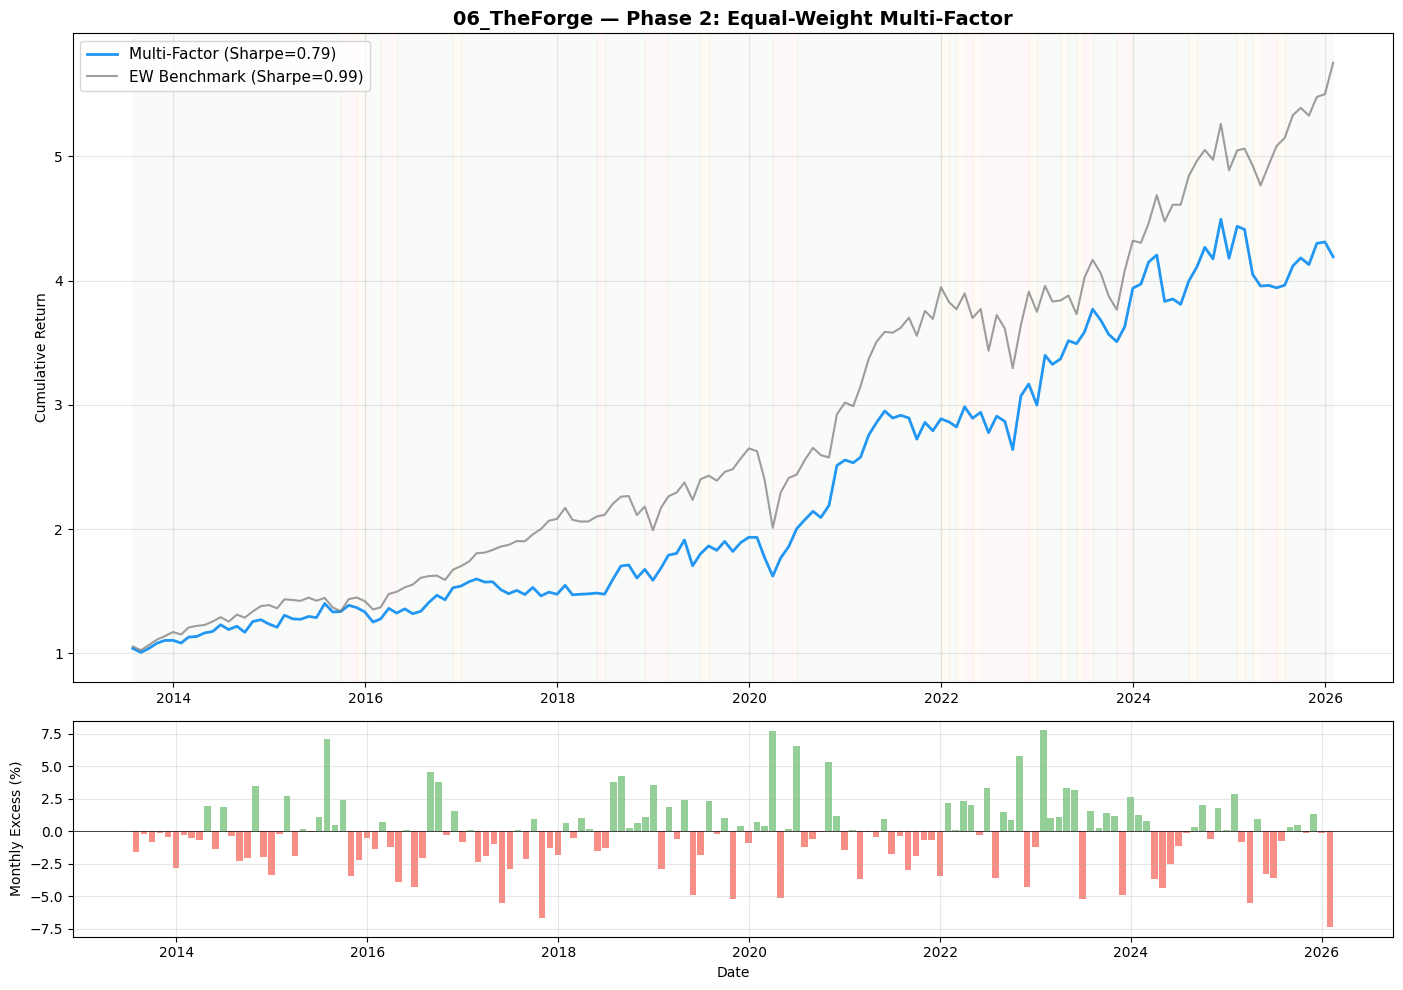


Phase 2 결론
  레짐별 승률: 1/3
  전체 t-stat: -0.93 (미달)
  전체 Sharpe: 0.79 (BM: 0.99)
  평균 턴오버: 77.0%

  → BM 대비 Sharpe 열위. 팩터 조합 재검토 필요.

→ Cell 4에서 Phase 3 (Bear 자산배분 레이어) 진행


In [8]:
# =============================================================================
# 🔨 06_TheForge.ipynb — Cell 3: Phase 2 — 레짐별 동일가중 조합 백테스트
# =============================================================================
#
# [목적]
# Cell 1의 REGIME_FACTOR_MAP에 따라, 레짐별로 다른 팩터 조합을 적용.
# 동일가중(equal-weight) z-score 합산 → Top N 선정 → 백테스트.
# Phase 2 = 베이스라인. 여기서 성과 확인 후 가중치/자산배분 추가.
#
# [로직]
# 매월 말:
#   1) 해당 월의 regime 확인 (Bull/Bear/Neutral)
#   2) REGIME_FACTOR_MAP[regime]["scores"]에 해당하는 팩터 z-score 합산
#   3) "avoids" 팩터 감점 (g1b_flag=1이면 합산 스코어에서 -2.0)
#   4) "filters" 적용 (F-1: Bear에서 fscore 하위 20% 제외)
#   5) T-1 이벤트 가산 (직전 hold_d 이내 이벤트 있으면 해당 섹터 +1.0)
#   6) Top N 선정 → t+1월 수익률로 성과 측정
#
# [레짐 래그]
# t월 말 regime 판정 → t+1월 초 리밸런싱 → t+1월 수익률 반영
# → look-ahead bias 없음 ✅ (Cell 2에서 확인 완료)
#
# [산출물]
# bt_multi: 월별 성과 DataFrame (date, port_ret, bm_ret, excess, regime, ...)
# 레짐별 + 전체 성과 요약
# =============================================================================

import numpy as np
import pandas as pd
from pathlib import Path

# ─── 팩터명 → 컬럼명 매핑 ────────────────────────────────────────────────────
FACTOR_COL_MAP = {
    "H":        "h_z",
    "D-3":      "d3_z",
    "D-1":      "d1_z",
    "A-3":      "a3_z",
    "P-5":      "p5_z",
    "E-5":      "e5_z",
    "G-1_bull": "g1_bull_z",
    "G-1_bear": "g1_bear_z",
    "P-7":      "nsi_score",
}

# ─── 섹터 매핑 (T-1 이벤트용) ─────────────────────────────────────────────────
universe = pd.read_parquet(Path(r"C:\QP2\data\meta") / "sp500_universe.parquet")
ticker_to_sector = universe.set_index("ticker_yahoo")["GICS Sector"].to_dict()

# ─── 백테스트 파라미터 ────────────────────────────────────────────────────────
AVOID_PENALTY  = -2.0    # g1b_flag=1 종목에 대한 감점
T1_BONUS       = 1.0     # T-1 이벤트 가산
T1_LOOKBACK_D  = 7       # T-1 이벤트 체크 기간 (Bull)
F1_CUTOFF_PCT  = 0.20    # F-1 필터: 하위 20% 제거 (Bear)

# ─── 메인 백테스트 ────────────────────────────────────────────────────────────

print("=" * 70)
print("🔨 Phase 2: 레짐별 동일가중 조합 백테스트")
print("=" * 70)

# 월말 날짜 정렬
all_dates = sorted(panel["date"].unique())
# BT_START ~ BT_END 필터
all_dates = [d for d in all_dates if BT_START <= str(d)[:7] <= BT_END]

results = []
prev_holdings = set()

for i, dt in enumerate(all_dates[:-1]):
    next_dt = all_dates[i + 1]
    
    # ── 1) 레짐 판정 ──
    regime_info = regime_map.get(dt, None)
    if regime_info is None:
        # 월말 날짜 매칭 시도
        dt_me = pd.Timestamp(dt) + pd.offsets.MonthEnd(0)
        regime_info = regime_map.get(dt_me, None)
    if regime_info is None:
        continue
    
    regime = regime_info["regime"]
    bear_phase = regime_info.get("bear_phase", "")
    
    # ── 2) 해당 월 종목 데이터 ──
    month_data = panel[panel["date"] == dt].copy()
    if len(month_data) < TOP_N:
        continue
    
    # ── 3) 레짐별 팩터 조합 ──
    factor_map = REGIME_FACTOR_MAP[regime]
    score_factors = factor_map["scores"]
    
    # 동일가중 z-score 합산
    score_cols = [FACTOR_COL_MAP[f] for f in score_factors if f in FACTOR_COL_MAP]
    
    # 각 팩터가 NaN인 경우 해당 팩터만 제외하고 나머지로 평균
    month_data["composite_z"] = month_data[score_cols].mean(axis=1)
    
    # ── 4) Avoids 감점 ──
    if "G-1b" in factor_map.get("avoids", []):
        mask_avoid = month_data["g1b_flag"] == 1
        month_data.loc[mask_avoid, "composite_z"] += AVOID_PENALTY
    
    # ── 5) F-1 필터 (Bear만) ──
    if "F-1" in factor_map.get("filters", []):
        fscore_valid = month_data["fscore"].dropna()
        if len(fscore_valid) > 0:
            cutoff = fscore_valid.quantile(F1_CUTOFF_PCT)
            # 하위 20% 제거 (composite_z를 NaN으로)
            mask_low_f = month_data["fscore"] < cutoff
            month_data.loc[mask_low_f, "composite_z"] = np.nan
    
    # ── 6) T-1 이벤트 가산 (Bull만) ──
    if "T-1" in factor_map.get("events", []) and len(t1_events) > 0:
        # 직전 T1_LOOKBACK_D 이내 이벤트
        dt_ts = pd.Timestamp(dt)
        recent_events = t1_events[
            (t1_events["date"] >= dt_ts - pd.Timedelta(days=T1_LOOKBACK_D)) &
            (t1_events["date"] <= dt_ts)
        ]
        if len(recent_events) > 0:
            event_sectors = set(recent_events["sector"].unique())
            for idx, row in month_data.iterrows():
                tk = row["ticker"]
                sector = ticker_to_sector.get(tk, "")
                if sector in event_sectors:
                    month_data.loc[idx, "composite_z"] += T1_BONUS
    
    # ── 7) G-1 이벤트 가산 (Bull: g1_bull_z 이미 scores에 포함, 별도 처리 불필요) ──
    # G-1_bear 이벤트도 scores에 포함되어 있으므로 별도 처리 불필요
    
    # ── 8) Top N 선정 ──
    valid = month_data.dropna(subset=["composite_z"])
    if len(valid) < TOP_N:
        # 유효 종목 부족 시 가능한 만큼
        top_n_actual = max(10, len(valid))
    else:
        top_n_actual = TOP_N
    
    top = valid.nlargest(top_n_actual, "composite_z")
    selected_tickers = top["ticker"].tolist()
    
    # ── 9) 수익률 계산 ──
    if next_dt not in ret_1m.index:
        continue
    
    available = [t for t in selected_tickers if t in ret_1m.columns]
    if len(available) == 0:
        continue
    rets = ret_1m.loc[next_dt, available].dropna()
    if len(rets) == 0:
        continue
    
    port_ret = rets.mean()
    bm_ret = ret_1m.loc[next_dt].dropna().mean()
    
    # 턴오버 + 거래비용
    curr_set = set(selected_tickers)
    if prev_holdings:
        turnover = len(curr_set - prev_holdings) / len(curr_set)
    else:
        turnover = 1.0
    cost = turnover * COST_BP * 2 / 10000
    
    results.append({
        "date": next_dt,
        "regime": regime,
        "bear_phase": bear_phase,
        "port_ret_gross": port_ret,
        "port_ret_net": port_ret - cost,
        "bm_ret": bm_ret,
        "turnover": turnover,
        "n_stocks": len(rets),
        "n_valid": len(valid),
    })
    prev_holdings = curr_set

bt_multi = pd.DataFrame(results)
bt_multi["date"] = pd.to_datetime(bt_multi["date"])
bt_multi = bt_multi.set_index("date")
bt_multi["excess_gross"] = bt_multi["port_ret_gross"] - bt_multi["bm_ret"]
bt_multi["excess_net"] = bt_multi["port_ret_net"] - bt_multi["bm_ret"]
bt_multi["cum_port"] = (1 + bt_multi["port_ret_net"]).cumprod()
bt_multi["cum_bm"] = (1 + bt_multi["bm_ret"]).cumprod()

# ─── 전체 성과 ────────────────────────────────────────────────────────────────

print(f"\n  백테스트 기간: {bt_multi.index.min()} ~ {bt_multi.index.max()}")
print(f"  총 {len(bt_multi)} months")

total_perf = calc_perf(bt_multi["cum_port"])
bm_perf = calc_perf(bt_multi["cum_bm"])
t_stat = calc_tstat(bt_multi["excess_net"])
avg_turnover = bt_multi["turnover"].mean()

print(f"\n{'='*70}")
print(f"전체 기간 성과 요약")
print(f"{'='*70}")
print(f"  {'':20s} {'Portfolio':>12s} {'EW Benchmark':>12s}")
print(f"  {'CAGR':20s} {total_perf['CAGR']:>11.1%} {bm_perf['CAGR']:>11.1%}")
print(f"  {'Sharpe':20s} {total_perf['Sharpe']:>12.2f} {bm_perf['Sharpe']:>12.2f}")
print(f"  {'MaxDD':20s} {total_perf['MaxDD']:>11.1%} {bm_perf['MaxDD']:>11.1%}")
print(f"  {'Excess (ann.)':20s} {bt_multi['excess_net'].mean()*12:>11.1%}")
print(f"  {'t-stat':20s} {t_stat:>12.2f}")
print(f"  {'Avg Turnover':20s} {avg_turnover:>11.1%}")

# ─── 레짐별 성과 ──────────────────────────────────────────────────────────────

print(f"\n{'='*70}")
print(f"레짐별 성과 분해")
print(f"{'='*70}")
print(f"  {'Regime':<12s} {'Months':>6s} {'CAGR':>8s} {'BM_CAGR':>8s} {'Excess':>8s} "
      f"{'t-stat':>7s} {'Sharpe':>7s} {'BM_Shp':>7s} {'Turnover':>9s}")
print(f"  {'-'*80}")

regime_stats = []
for regime in ["Bull", "Bear", "Neutral"]:
    sub = bt_multi[bt_multi["regime"] == regime]
    if len(sub) < 2:
        continue
    
    cum_p = (1 + sub["port_ret_net"]).cumprod()
    cum_b = (1 + sub["bm_ret"]).cumprod()
    p_perf = calc_perf(cum_p)
    b_perf = calc_perf(cum_b)
    t = calc_tstat(sub["excess_net"])
    turn = sub["turnover"].mean()
    excess_ann = sub["excess_net"].mean() * 12
    
    result_flag = "WIN" if p_perf["Sharpe"] > b_perf["Sharpe"] else "LOSE"
    
    print(f"  {regime:<12s} {len(sub):>6d} {p_perf['CAGR']:>7.1%} {b_perf['CAGR']:>7.1%} "
          f"{excess_ann:>+7.1%} {t:>7.2f} {p_perf['Sharpe']:>7.2f} {b_perf['Sharpe']:>7.2f} "
          f"{turn:>8.1%}  {result_flag}")
    
    regime_stats.append({
        "regime": regime, "months": len(sub), 
        "cagr": p_perf["CAGR"], "bm_cagr": b_perf["CAGR"],
        "sharpe": p_perf["Sharpe"], "bm_sharpe": b_perf["Sharpe"],
        "excess": excess_ann, "tstat": t, "turnover": turn,
        "result": result_flag,
    })

# Bear 내부 세분화
print(f"\n  Bear 내부:")
for phase in ["declining", "recovering"]:
    sub = bt_multi[(bt_multi["regime"] == "Bear") & (bt_multi["bear_phase"] == phase)]
    if len(sub) < 2:
        print(f"    {phase}: 데이터 부족 (n={len(sub)})")
        continue
    cum_p = (1 + sub["port_ret_net"]).cumprod()
    cum_b = (1 + sub["bm_ret"]).cumprod()
    p_perf = calc_perf(cum_p)
    b_perf = calc_perf(cum_b)
    t = calc_tstat(sub["excess_net"])
    print(f"    {phase:12s}: n={len(sub):2d}  CAGR={p_perf['CAGR']:+.1%}  "
          f"BM={b_perf['CAGR']:+.1%}  Excess={sub['excess_net'].mean()*12:+.1%}  t={t:.2f}")

# ─── 누적 수익률 차트 ─────────────────────────────────────────────────────────

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [3, 1]})

# 상단: 누적 수익률
ax1 = axes[0]
ax1.plot(bt_multi.index, bt_multi["cum_port"], label=f"Multi-Factor (Sharpe={total_perf['Sharpe']:.2f})",
         linewidth=2, color="#2196F3")
ax1.plot(bt_multi.index, bt_multi["cum_bm"], label=f"EW Benchmark (Sharpe={bm_perf['Sharpe']:.2f})",
         linewidth=1.5, color="#757575", alpha=0.7)

# 레짐 배경색
regime_colors = {"Bull": "#E8F5E9", "Bear": "#FFEBEE", "Neutral": "#FFF3E0"}
prev_regime = None
prev_date = bt_multi.index[0]
for dt_idx in bt_multi.index:
    r = bt_multi.loc[dt_idx, "regime"]
    if r != prev_regime and prev_regime is not None:
        ax1.axvspan(prev_date, dt_idx, alpha=0.3, color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)
        prev_date = dt_idx
    prev_regime = r
ax1.axvspan(prev_date, bt_multi.index[-1], alpha=0.3, color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)

ax1.set_title("06_TheForge — Phase 2: Equal-Weight Multi-Factor", fontsize=14, fontweight="bold")
ax1.legend(loc="upper left", fontsize=11)
ax1.set_ylabel("Cumulative Return")
ax1.grid(True, alpha=0.3)

# 하단: 월간 초과수익
ax2 = axes[1]
colors = ["#4CAF50" if x > 0 else "#F44336" for x in bt_multi["excess_net"]]
ax2.bar(bt_multi.index, bt_multi["excess_net"] * 100, color=colors, alpha=0.6, width=25)
ax2.axhline(0, color="black", linewidth=0.5)
ax2.set_ylabel("Monthly Excess (%)")
ax2.set_xlabel("Date")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(Path(r"C:\QP2\data\interim") / "06_theforge_phase2.png"), dpi=150, bbox_inches="tight")
plt.show()

# ─── 요약 ─────────────────────────────────────────────────────────────────────

print(f"\n{'='*70}")
print(f"Phase 2 결론")
print(f"{'='*70}")

wins = sum(1 for s in regime_stats if s["result"] == "WIN")
total = len(regime_stats)
print(f"  레짐별 승률: {wins}/{total}")
print(f"  전체 t-stat: {t_stat:.2f} ({'유의' if abs(t_stat) > 2.0 else '미달'})")
print(f"  전체 Sharpe: {total_perf['Sharpe']:.2f} (BM: {bm_perf['Sharpe']:.2f})")
print(f"  평균 턴오버: {avg_turnover:.1%}")

if total_perf["Sharpe"] > bm_perf["Sharpe"]:
    print(f"\n  → BM 대비 Sharpe 우위. Phase 3 (자산배분) 진행.")
else:
    print(f"\n  → BM 대비 Sharpe 열위. 팩터 조합 재검토 필요.")

print(f"\n→ Cell 4에서 Phase 3 (Bear 자산배분 레이어) 진행")

FEDFUNDS 로드: 313 months
  범위: 0.05% ~ 6.54% (연율)

🔨 Phase 3: Bear 자산배분 레이어 (FEDFUNDS 현금 수익률)

Phase 2 vs Phase 3 성과 비교 (현금=FEDFUNDS)
                           CAGR   Sharpe    MaxDD   t-stat
  --------------------------------------------------------
  EW Benchmark           14.4%     0.99  -24.1%
  Phase 2 (No Alloc)     11.7%     0.79  -16.2%    -0.93
  Phase 3 Conservative    9.5%     0.73  -13.9%    -1.62
  Phase 3 Moderate        9.9%     0.75  -14.6%    -1.51
  Phase 3 Aggressive      9.0%     0.70  -13.1%    -1.71

Bear 구간 성과 비교 (23 months)
                        Bear CAGR    BM CAGR Bear MaxDD  Cash(ann)
  --------------------------------------------------------------
  Phase 2 (No Alloc)       20.8%     20.5%    -10.2%        N/A
  Phase 3 Conservative      9.2%     20.5%     -6.4%       2.0%
  Phase 3 Moderate         11.1%     20.5%     -7.2%       2.0%
  Phase 3 Aggressive        7.3%     20.5%     -5.6%       2.0%

  → 최적: Moderate (Sharpe=0.75)


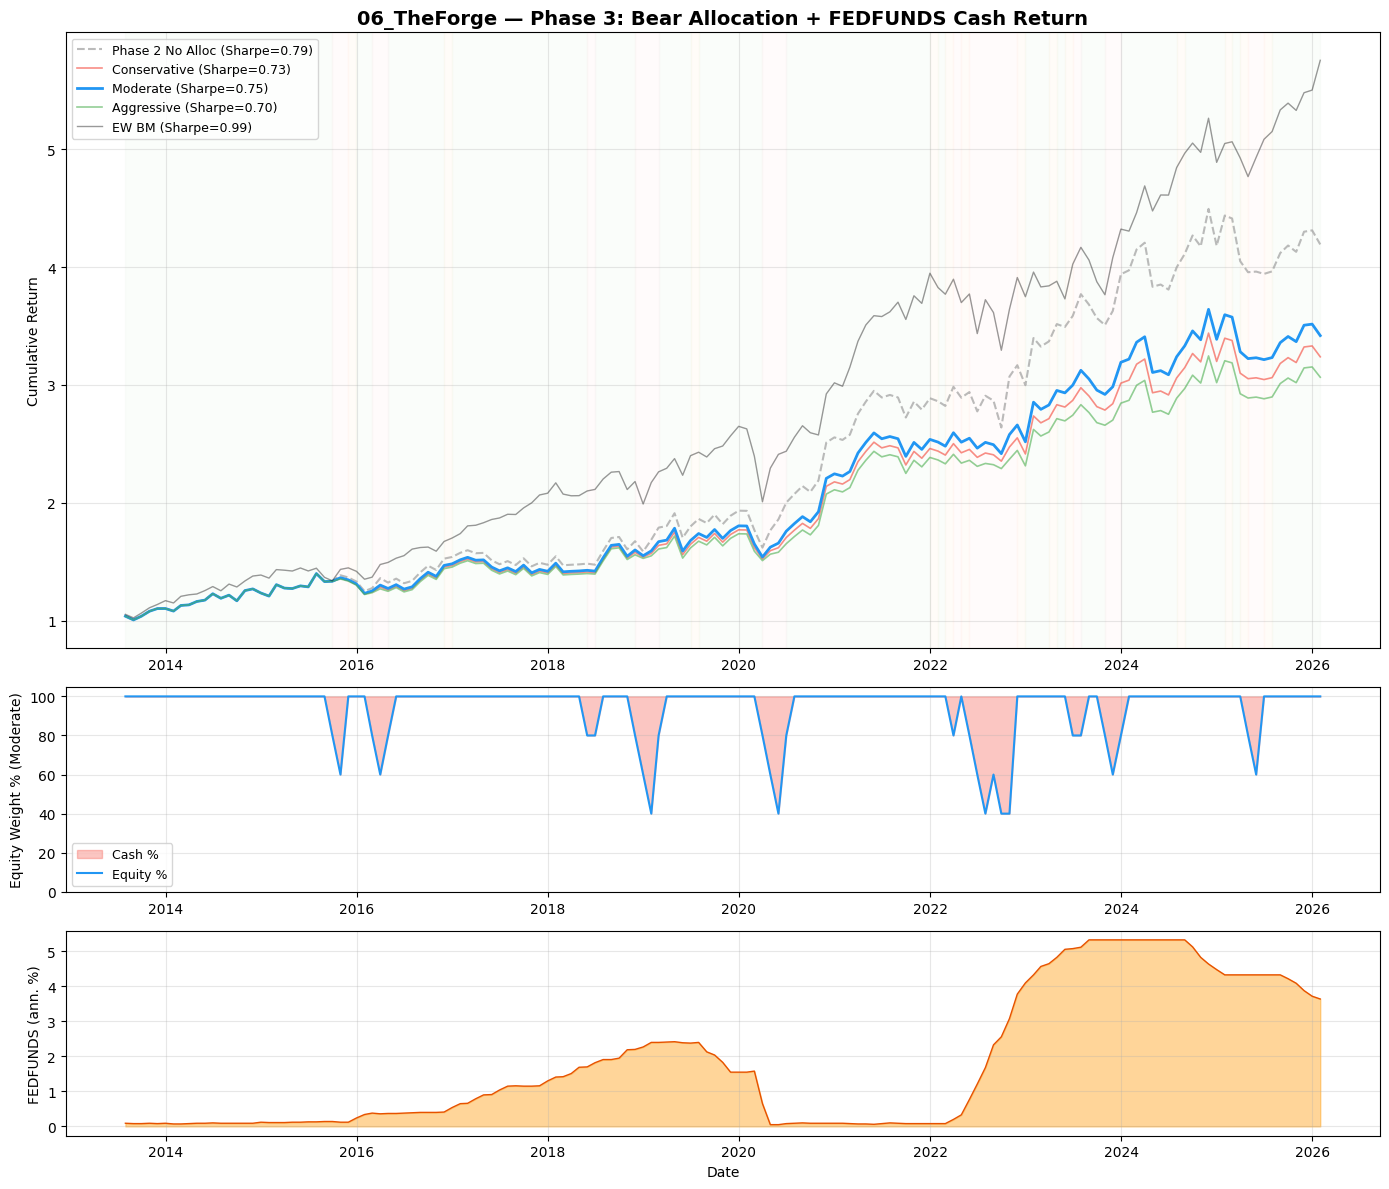


Equity Weight 분포 (Moderate)
  Bull      : eq_wt avg=99% min=80% max=100%  cash=1.6%(ann)  n=115
  Bear      : eq_wt avg=64% min=40% max=80%  cash=2.0%(ann)  n=23
  Neutral   : eq_wt avg=100% min=100% max=100%  cash=2.7%(ann)  n=13

Phase 3 결론 (FEDFUNDS 현금 수익률)
  최적 파라미터: Moderate
  전체 Sharpe: 0.75 (Phase 2: 0.79, BM: 0.99)
  전체 CAGR:   9.9% (Phase 2: 11.7%, BM: 14.4%)
  MaxDD:       -14.6% (Phase 2: -16.2%, BM: -24.1%)

  → 자산배분 효과 제한적. Phase 2.5(가중치 조정)에서 개선 필요.

→ Cell 5에서 Phase 2.5 (팩터 가중치 조정) 진행


In [9]:
# =============================================================================
# 🔨 06_TheForge.ipynb — Cell 4: Phase 3 — Bear 자산배분 레이어 (v2)
# =============================================================================
# 변경: 현금 수익률 0% → FEDFUNDS 실제 금리 적용
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ─── 현금 수익률: FEDFUNDS (월간 환산) ────────────────────────────────────────

macro = pd.read_parquet(Path(r"C:\QP2\data\interim") / "macro_indicators.parquet")
macro.index = pd.to_datetime(macro.index)
fedfunds_m = macro["FEDFUNDS"].resample("ME").last() / 100 / 12  # 연율% → 월간 소수
fedfunds_m = fedfunds_m.dropna()
print(f"FEDFUNDS 로드: {len(fedfunds_m)} months")
print(f"  범위: {fedfunds_m.min()*12*100:.2f}% ~ {fedfunds_m.max()*12*100:.2f}% (연율)")

# ─── 자산배분 파라미터 세트 ───────────────────────────────────────────────────

ALLOC_PARAMS = {
    "Conservative": {"m1": 0.70, "m2": 0.50, "m3": 0.30, "recovery_step": 0.20},
    "Moderate":     {"m1": 0.80, "m2": 0.60, "m3": 0.40, "recovery_step": 0.20},
    "Aggressive":   {"m1": 0.60, "m2": 0.40, "m3": 0.20, "recovery_step": 0.20},
}

# ─── 자산배분 함수 ────────────────────────────────────────────────────────────

def apply_bear_allocation(bt_df, params, fedfunds):
    """
    bt_multi에 Bear 자산배분 오버레이 적용.
    현금 수익률 = 해당 월 FEDFUNDS 월간 환산.
    """
    df = bt_df.copy()
    
    bear_streak = 0
    recovering_months = 0
    prev_regime = None
    prev_bear_phase = None
    equity_weights = []
    cash_returns = []
    
    for idx in df.index:
        regime = df.loc[idx, "regime"]
        bear_phase = df.loc[idx, "bear_phase"]
        
        # 해당 월 현금 수익률
        cash_r = fedfunds.get(idx, 0.0)
        if pd.isna(cash_r):
            # 가장 가까운 이전 값
            prior = fedfunds[fedfunds.index <= idx]
            cash_r = prior.iloc[-1] if len(prior) > 0 else 0.0
        cash_returns.append(cash_r)
        
        if regime == "Bear":
            bear_streak += 1
            
            if bear_streak == 1:
                eq_w = params["m1"]
            elif bear_streak == 2:
                eq_w = params["m2"]
            else:
                eq_w = params["m3"]
            
            # recovering 전환 시 한 단계 복귀
            if bear_phase == "recovering":
                if prev_bear_phase == "declining":
                    recovering_months = 1
                else:
                    recovering_months += 1
                eq_w = min(1.0, eq_w + params["recovery_step"] * recovering_months)
            else:
                recovering_months = 0
                
        elif regime == "Neutral":
            eq_w = 1.0
            bear_streak = 0
            recovering_months = 0
            
        else:  # Bull
            if prev_regime == "Bear":
                eq_w = min(1.0, params["m3"] + params["recovery_step"] * 2)
            elif prev_regime == "Neutral" and bear_streak > 0:
                eq_w = min(1.0, params["m2"] + params["recovery_step"])
            else:
                eq_w = 1.0
            bear_streak = 0
            recovering_months = 0
        
        equity_weights.append(eq_w)
        prev_regime = regime
        prev_bear_phase = bear_phase
    
    df["equity_weight"] = equity_weights
    df["cash_ret"] = cash_returns
    
    # 조정 수익률: equity × 주식 + (1-equity) × 현금
    df["alloc_ret"] = df["equity_weight"] * df["port_ret_net"] + (1 - df["equity_weight"]) * df["cash_ret"]
    df["alloc_bm_ret"] = df["equity_weight"] * df["bm_ret"] + (1 - df["equity_weight"]) * df["cash_ret"]
    
    df["cum_alloc"] = (1 + df["alloc_ret"]).cumprod()
    df["cum_alloc_bm"] = (1 + df["alloc_bm_ret"]).cumprod()
    
    return df


# ─── 파라미터별 백테스트 ──────────────────────────────────────────────────────

print("\n" + "=" * 70)
print("🔨 Phase 3: Bear 자산배분 레이어 (FEDFUNDS 현금 수익률)")
print("=" * 70)

alloc_results = {}

for name, params in ALLOC_PARAMS.items():
    bt_alloc = apply_bear_allocation(bt_multi, params, fedfunds_m)
    alloc_results[name] = bt_alloc
    
    perf = calc_perf(bt_alloc["cum_alloc"])
    t = calc_tstat(bt_alloc["alloc_ret"] - bt_alloc["bm_ret"])
    
    # Bear 구간 성과
    bear_sub = bt_alloc[bt_alloc["regime"] == "Bear"]
    bear_cum = (1 + bear_sub["alloc_ret"]).cumprod()
    bear_bm_cum = (1 + bear_sub["bm_ret"]).cumprod()
    bear_perf = calc_perf(bear_cum) if len(bear_cum) > 1 else {"CAGR": 0, "Sharpe": 0, "MaxDD": 0}
    bear_bm_perf = calc_perf(bear_bm_cum) if len(bear_bm_cum) > 1 else {"CAGR": 0, "Sharpe": 0, "MaxDD": 0}
    
    # Bear 평균 현금 수익률
    bear_cash_avg = bear_sub["cash_ret"].mean() * 12 * 100 if len(bear_sub) > 0 else 0
    
    alloc_results[name + "_perf"] = {
        "total": perf, "tstat": t,
        "bear": bear_perf, "bear_bm": bear_bm_perf,
        "bear_cash_ann": bear_cash_avg,
    }

# ─── 결과 비교 ────────────────────────────────────────────────────────────────

p2_perf = calc_perf(bt_multi["cum_port"])
p2_bm_perf = calc_perf(bt_multi["cum_bm"])

print(f"\n{'='*70}")
print(f"Phase 2 vs Phase 3 성과 비교 (현금=FEDFUNDS)")
print(f"{'='*70}")
print(f"  {'':20s} {'CAGR':>8s} {'Sharpe':>8s} {'MaxDD':>8s} {'t-stat':>8s}")
print(f"  {'-'*56}")
print(f"  {'EW Benchmark':20s} {p2_bm_perf['CAGR']:>7.1%} {p2_bm_perf['Sharpe']:>8.2f} "
      f"{p2_bm_perf['MaxDD']:>7.1%}")
print(f"  {'Phase 2 (No Alloc)':20s} {p2_perf['CAGR']:>7.1%} {p2_perf['Sharpe']:>8.2f} "
      f"{p2_perf['MaxDD']:>7.1%} {calc_tstat(bt_multi['excess_net']):>8.2f}")

for name in ["Conservative", "Moderate", "Aggressive"]:
    perf = alloc_results[name + "_perf"]["total"]
    t = alloc_results[name + "_perf"]["tstat"]
    print(f"  {'Phase 3 ' + name:20s} {perf['CAGR']:>7.1%} {perf['Sharpe']:>8.2f} "
          f"{perf['MaxDD']:>7.1%} {t:>8.2f}")

# Bear 구간 집중 비교
print(f"\n{'='*70}")
print(f"Bear 구간 성과 비교 ({bt_multi[bt_multi['regime']=='Bear'].shape[0]} months)")
print(f"{'='*70}")
print(f"  {'':20s} {'Bear CAGR':>10s} {'BM CAGR':>10s} {'Bear MaxDD':>10s} {'Cash(ann)':>10s}")
print(f"  {'-'*62}")

bear_p2 = bt_multi[bt_multi["regime"] == "Bear"]
if len(bear_p2) > 1:
    bear_p2_cum = (1 + bear_p2["port_ret_net"]).cumprod()
    bear_p2_bm = (1 + bear_p2["bm_ret"]).cumprod()
    bp2 = calc_perf(bear_p2_cum)
    bp2_bm = calc_perf(bear_p2_bm)
    print(f"  {'Phase 2 (No Alloc)':20s} {bp2['CAGR']:>9.1%} {bp2_bm['CAGR']:>9.1%} "
          f"{bp2['MaxDD']:>9.1%} {'N/A':>10s}")

for name in ["Conservative", "Moderate", "Aggressive"]:
    bp = alloc_results[name + "_perf"]["bear"]
    bp_bm = alloc_results[name + "_perf"]["bear_bm"]
    cash_ann = alloc_results[name + "_perf"]["bear_cash_ann"]
    print(f"  {'Phase 3 ' + name:20s} {bp['CAGR']:>9.1%} {bp_bm['CAGR']:>9.1%} "
          f"{bp['MaxDD']:>9.1%} {cash_ann:>9.1f}%")

# ─── 최적 파라미터 선택 ───────────────────────────────────────────────────────

best_name = max(["Conservative", "Moderate", "Aggressive"],
                key=lambda n: alloc_results[n + "_perf"]["total"]["Sharpe"])
best_bt = alloc_results[best_name]
best_perf = alloc_results[best_name + "_perf"]["total"]

print(f"\n  → 최적: {best_name} (Sharpe={best_perf['Sharpe']:.2f})")

# ─── 누적 수익률 비교 차트 ────────────────────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(14, 12), gridspec_kw={"height_ratios": [3, 1, 1]})

# 상단: 누적 수익률
ax1 = axes[0]
ax1.plot(bt_multi.index, bt_multi["cum_port"], label=f"Phase 2 No Alloc (Sharpe={p2_perf['Sharpe']:.2f})",
         linewidth=1.5, color="#9E9E9E", alpha=0.7, linestyle="--")

colors = {"Conservative": "#F44336", "Moderate": "#2196F3", "Aggressive": "#4CAF50"}
for name in ["Conservative", "Moderate", "Aggressive"]:
    bt_a = alloc_results[name]
    perf = alloc_results[name + "_perf"]["total"]
    ax1.plot(bt_a.index, bt_a["cum_alloc"], 
             label=f"{name} (Sharpe={perf['Sharpe']:.2f})",
             linewidth=2 if name == best_name else 1.2,
             color=colors[name],
             alpha=1.0 if name == best_name else 0.6)

ax1.plot(bt_multi.index, bt_multi["cum_bm"], label=f"EW BM (Sharpe={p2_bm_perf['Sharpe']:.2f})",
         linewidth=1, color="black", alpha=0.4)

regime_colors = {"Bull": "#E8F5E9", "Bear": "#FFEBEE", "Neutral": "#FFF3E0"}
prev_regime = None
prev_date = bt_multi.index[0]
for dt_idx in bt_multi.index:
    r = bt_multi.loc[dt_idx, "regime"]
    if r != prev_regime and prev_regime is not None:
        ax1.axvspan(prev_date, dt_idx, alpha=0.2, color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)
        prev_date = dt_idx
    prev_regime = r
ax1.axvspan(prev_date, bt_multi.index[-1], alpha=0.2, color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)

ax1.set_title("06_TheForge — Phase 3: Bear Allocation + FEDFUNDS Cash Return", fontsize=14, fontweight="bold")
ax1.legend(loc="upper left", fontsize=9)
ax1.set_ylabel("Cumulative Return")
ax1.grid(True, alpha=0.3)

# 중단: equity weight
ax2 = axes[1]
ax2.fill_between(best_bt.index, best_bt["equity_weight"] * 100, 100,
                 alpha=0.3, color="#F44336", label="Cash %")
ax2.plot(best_bt.index, best_bt["equity_weight"] * 100, 
         color="#2196F3", linewidth=1.5, label="Equity %")
ax2.set_ylabel(f"Equity Weight % ({best_name})")
ax2.set_ylim(0, 105)
ax2.legend(loc="lower left", fontsize=9)
ax2.grid(True, alpha=0.3)

# 하단: FEDFUNDS 연율
ax3 = axes[2]
fedfunds_ann = fedfunds_m.reindex(best_bt.index) * 12 * 100
ax3.fill_between(fedfunds_ann.index, fedfunds_ann.values, alpha=0.4, color="#FF9800")
ax3.plot(fedfunds_ann.index, fedfunds_ann.values, color="#E65100", linewidth=1)
ax3.set_ylabel("FEDFUNDS (ann. %)")
ax3.set_xlabel("Date")
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(Path(r"C:\QP2\data\interim") / "06_theforge_phase3_v2.png"), dpi=150, bbox_inches="tight")
plt.show()

# ─── Equity Weight 분포 ──────────────────────────────────────────────────────

print(f"\n{'='*70}")
print(f"Equity Weight 분포 ({best_name})")
print(f"{'='*70}")
for regime in ["Bull", "Bear", "Neutral"]:
    sub = best_bt[best_bt["regime"] == regime]
    if len(sub) > 0:
        avg_w = sub["equity_weight"].mean()
        min_w = sub["equity_weight"].min()
        max_w = sub["equity_weight"].max()
        avg_cash = sub["cash_ret"].mean() * 12 * 100
        print(f"  {regime:10s}: eq_wt avg={avg_w:.0%} min={min_w:.0%} max={max_w:.0%}  "
              f"cash={avg_cash:.1f}%(ann)  n={len(sub)}")

# ─── 결론 ─────────────────────────────────────────────────────────────────────

print(f"\n{'='*70}")
print(f"Phase 3 결론 (FEDFUNDS 현금 수익률)")
print(f"{'='*70}")
print(f"  최적 파라미터: {best_name}")
print(f"  전체 Sharpe: {best_perf['Sharpe']:.2f} (Phase 2: {p2_perf['Sharpe']:.2f}, BM: {p2_bm_perf['Sharpe']:.2f})")
print(f"  전체 CAGR:   {best_perf['CAGR']:.1%} (Phase 2: {p2_perf['CAGR']:.1%}, BM: {p2_bm_perf['CAGR']:.1%})")
print(f"  MaxDD:       {best_perf['MaxDD']:.1%} (Phase 2: {p2_perf['MaxDD']:.1%}, BM: {p2_bm_perf['MaxDD']:.1%})")

if best_perf["Sharpe"] > p2_perf["Sharpe"]:
    improvement = best_perf["Sharpe"] - p2_perf["Sharpe"]
    print(f"\n  → Phase 3으로 Sharpe +{improvement:.2f} 개선!")
else:
    print(f"\n  → 자산배분 효과 제한적. Phase 2.5(가중치 조정)에서 개선 필요.")

print(f"\n→ Cell 5에서 Phase 2.5 (팩터 가중치 조정) 진행")
# 오케이 코로나 때문에 조박은거 확인. 
# 킹치만 채권은 보험인걸.. 보험비 내는게 당연한거 아니야?

🔨 Phase 2.5: 팩터 가중치 조정

  [EqualWeight]
    CAGR=11.7%  Sharpe=0.79  MaxDD=-16.2%  t=-0.93  Turn=77%
    Bull    : CAGR=+9.6% BM=+12.3% Sharpe=0.70/1.08 LOSE
    Bear    : CAGR=+20.8% BM=+20.5% Sharpe=1.09/0.87 WIN
    Neutral : CAGR=+16.3% BM=+24.9% Sharpe=1.14/1.62 LOSE

  [A_H_Focus]
    CAGR=8.7%  Sharpe=0.61  MaxDD=-17.4%  t=-1.75  Turn=77%
    Bull    : CAGR=+5.1% BM=+12.3% Sharpe=0.41/1.08 LOSE
    Bear    : CAGR=+21.6% BM=+20.5% Sharpe=1.13/0.87 WIN
    Neutral : CAGR=+19.6% BM=+24.9% Sharpe=1.46/1.62 LOSE

  [B_Balanced]
    CAGR=7.8%  Sharpe=0.59  MaxDD=-16.4%  t=-2.52  Turn=78%
    Bull    : CAGR=+4.9% BM=+12.3% Sharpe=0.43/1.08 LOSE
    Bear    : CAGR=+17.0% BM=+20.5% Sharpe=0.91/0.87 WIN
    Neutral : CAGR=+18.4% BM=+24.9% Sharpe=1.27/1.62 LOSE

  [C_Tstat]
    CAGR=8.3%  Sharpe=0.62  MaxDD=-17.8%  t=-2.27  Turn=78%
    Bull    : CAGR=+6.5% BM=+12.3% Sharpe=0.54/1.08 LOSE
    Bear    : CAGR=+10.0% BM=+20.5% Sharpe=0.59/0.87 LOSE
    Neutral : CAGR=+20.6% BM=+24.9% Sharpe=1

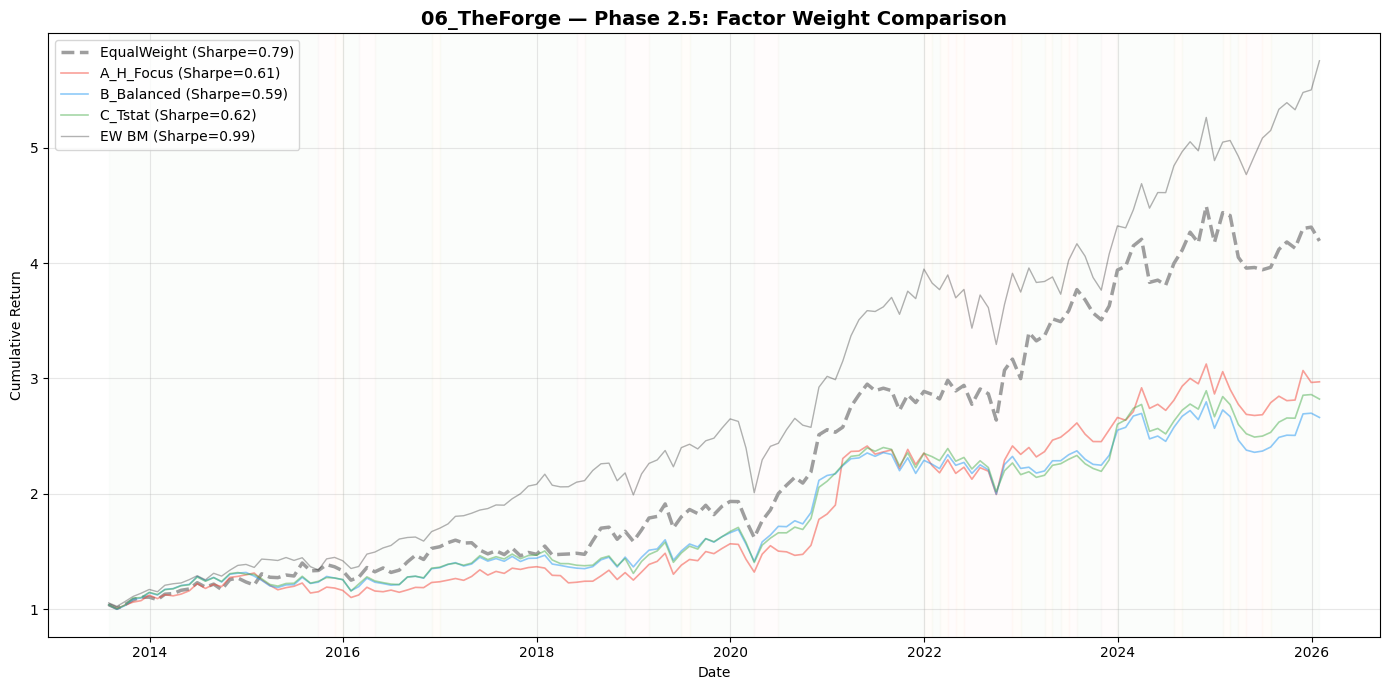


Phase 2.5 결론
  EqualWeight Sharpe: 0.79
  EqualWeight Sharpe:  0.79
  개선:               +0.00

→ Cell 6에서 Phase 2.5 + Phase 3 결합 (최종 모델) 진행


In [12]:
# =============================================================================
# 🔨 06_TheForge.ipynb — Cell 5: Phase 2.5 — 팩터 가중치 조정
# =============================================================================
#
# [목적]
# Phase 2(동일가중)에서 발견된 문제:
#   - Bull: BM 대비 LOSE (Sharpe 0.70 vs 1.08). G-1_bull(역모멘텀)이 H를 희석.
#   - Neutral: BM 대비 LOSE (13개월, 표본 부족)
#   - Bear: WIN 하지만 개선 여지 있음
#
# [조정 방향]
#   Bull:  G-1_bull 제거 또는 축소. H 가중 확대.
#   Bear:  방어 팩터(P-5, E-5) 가중 확대. 공격(D-1, G-1_bear) 축소.
#   Neutral: D-3 가중 확대. H 축소 (Neutral에서 H 약함).
#
# [테스트 세트]
#   과적합 방지를 위해 "논리 기반" 2~3세트만 테스트.
#   Grid search 안 함.
#
#   Set A "H 올인":
#     Bull:    H=2.0, P-7=1.0                    (G-1_bull 제거)
#     Bear:    H=1.0, P-5=1.5, E-5=1.5, A-3=1.0, D-1=0.5  (방어 강화)
#     Neutral: D-3=2.0, H=0.5                     (D-3 집중)
#
#   Set B "균형 조정":
#     Bull:    H=1.5, G-1_bull=0.5, P-7=1.0       (G-1 축소)
#     Bear:    H=1.0, P-5=1.5, E-5=1.5, A-3=1.0, D-1=0.5, G-1_bear=1.0
#     Neutral: D-3=1.5, H=1.0
#
#   Set C "t-stat 가중":
#     가중치 = 각 팩터의 v4 t-stat에 비례
#     Bull:    H=2.0(t=12.3), P-7=1.0(t=2.4), G-1_bull=0.5(t=2.6)
#     Bear:    G-1_bear=2.0(t=7.8), P-5=1.5(t=4.3), E-5=1.5(t=4.7),
#              A-3=1.0(t=2.2), H=0.5, D-1=0.5(t=0.2)
#     Neutral: D-3=2.0(Sharpe=2.5), H=1.0(t=2.2)
#
# [산출물]
# 세트별 성과 비교 → 최적 세트 선정 → Phase 3과 결합
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ─── 가중치 세트 정의 ─────────────────────────────────────────────────────────

WEIGHT_SETS = {
    "EqualWeight": {
        "Bull":    {"h_z": 1.0, "g1_bull_z": 1.0, "nsi_score": 1.0},
        "Bear":    {"h_z": 1.0, "a3_z": 1.0, "p5_z": 1.0, "e5_z": 1.0, "d1_z": 1.0},
        "Neutral": {"h_z": 1.0, "d3_z": 1.0},
    },
    "A_H_Focus": {
        "Bull":    {"h_z": 2.0, "nsi_score": 1.0},
        "Bear":    {"h_z": 1.0, "p5_z": 1.5, "e5_z": 1.5, "a3_z": 1.0, "d1_z": 0.5},
        "Neutral": {"d3_z": 2.0, "h_z": 0.5},
    },
    "B_Balanced": {
        "Bull":    {"h_z": 1.5, "g1_bull_z": 0.5, "nsi_score": 1.0},
        "Bear":    {"h_z": 1.0, "p5_z": 1.5, "e5_z": 1.5, "a3_z": 1.0, "d1_z": 0.5, "g1_bear_z": 1.0},
        "Neutral": {"d3_z": 1.5, "h_z": 1.0},
    },
    "C_Tstat": {
        "Bull":    {"h_z": 2.0, "nsi_score": 1.0, "g1_bull_z": 0.5},
        "Bear":    {"g1_bear_z": 2.0, "p5_z": 1.5, "e5_z": 1.5, "a3_z": 1.0, "h_z": 0.5, "d1_z": 0.5},
        "Neutral": {"d3_z": 2.0, "h_z": 1.0},
    },
}

# ─── 가중 백테스트 함수 ───────────────────────────────────────────────────────

def backtest_weighted(panel_df, ret_1m_df, regime_map_dict, weight_set, 
                      t1_events_df, ticker_to_sector_dict,
                      top_n=30, cost_bp=20, avoid_penalty=-2.0,
                      t1_bonus=1.0, t1_lookback=7, f1_cutoff=0.20):
    """
    가중 팩터 조합 백테스트.
    weight_set: {"Bull": {"h_z": 2.0, ...}, "Bear": {...}, "Neutral": {...}}
    """
    all_dates = sorted(panel_df["date"].unique())
    
    results = []
    prev_holdings = set()
    
    for i, dt in enumerate(all_dates[:-1]):
        next_dt = all_dates[i + 1]
        
        # 레짐
        regime_info = regime_map_dict.get(dt, None)
        if regime_info is None:
            dt_me = pd.Timestamp(dt) + pd.offsets.MonthEnd(0)
            regime_info = regime_map_dict.get(dt_me, None)
        if regime_info is None:
            continue
        
        regime = regime_info["regime"]
        bear_phase = regime_info.get("bear_phase", "")
        
        # 해당 월 데이터
        month_data = panel_df[panel_df["date"] == dt].copy()
        if len(month_data) < top_n:
            continue
        
        # 가중 z-score 합산
        weights = weight_set.get(regime, {})
        if not weights:
            continue
        
        # 종목별 유효 팩터만으로 가중 평균 (NaN 팩터는 해당 종목에서 제외)
        factor_cols_used = [col for col in weights.keys() if col in month_data.columns]
        if not factor_cols_used:
            continue
        
        weight_arr = np.array([weights[col] for col in factor_cols_used])
        values_df = month_data[factor_cols_used].copy()
        
        # NaN mask: 유효하면 가중치, 아니면 0
        valid_mask = values_df.notna().values  # (n_stocks, n_factors) bool
        weighted_vals = np.where(valid_mask, values_df.values * weight_arr, 0)
        active_weights = np.where(valid_mask, weight_arr, 0)
        
        sum_weights = active_weights.sum(axis=1)
        sum_weights[sum_weights == 0] = np.nan  # 유효 팩터 0개면 NaN
        
        month_data["composite_z"] = weighted_vals.sum(axis=1) / sum_weights
        
        # Avoids (G-1b) — Bear/Neutral에서만
        if regime in ["Bear", "Neutral"]:
            mask_avoid = month_data["g1b_flag"] == 1
            month_data.loc[mask_avoid, "composite_z"] += avoid_penalty
        
        # F-1 필터 (Bear만)
        if regime == "Bear":
            fscore_valid = month_data["fscore"].dropna()
            if len(fscore_valid) > 0:
                cutoff = fscore_valid.quantile(f1_cutoff)
                mask_low_f = month_data["fscore"] < cutoff
                month_data.loc[mask_low_f, "composite_z"] = np.nan
        
        # T-1 이벤트 가산 (Bull만)
        if regime == "Bull" and len(t1_events_df) > 0:
            dt_ts = pd.Timestamp(dt)
            recent = t1_events_df[
                (t1_events_df["date"] >= dt_ts - pd.Timedelta(days=t1_lookback)) &
                (t1_events_df["date"] <= dt_ts)
            ]
            if len(recent) > 0:
                event_sectors = set(recent["sector"].unique())
                for idx_row in month_data.index:
                    tk = month_data.loc[idx_row, "ticker"]
                    sector = ticker_to_sector_dict.get(tk, "")
                    if sector in event_sectors:
                        month_data.loc[idx_row, "composite_z"] += t1_bonus
        
        # Top N
        valid = month_data.dropna(subset=["composite_z"])
        top_n_actual = min(top_n, max(10, len(valid)))
        top = valid.nlargest(top_n_actual, "composite_z")
        selected = top["ticker"].tolist()
        
        # 수익률
        if next_dt not in ret_1m_df.index:
            continue
        available = [t for t in selected if t in ret_1m_df.columns]
        if not available:
            continue
        rets = ret_1m_df.loc[next_dt, available].dropna()
        if len(rets) == 0:
            continue
        
        port_ret = rets.mean()
        bm_ret = ret_1m_df.loc[next_dt].dropna().mean()
        
        curr_set = set(selected)
        turnover = len(curr_set - prev_holdings) / len(curr_set) if prev_holdings else 1.0
        cost = turnover * cost_bp * 2 / 10000
        
        results.append({
            "date": next_dt,
            "regime": regime,
            "bear_phase": bear_phase,
            "port_ret_net": port_ret - cost,
            "bm_ret": bm_ret,
            "turnover": turnover,
        })
        prev_holdings = curr_set
    
    df = pd.DataFrame(results)
    if len(df) == 0:
        return df
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date")
    df["excess_net"] = df["port_ret_net"] - df["bm_ret"]
    df["cum_port"] = (1 + df["port_ret_net"]).cumprod()
    df["cum_bm"] = (1 + df["bm_ret"]).cumprod()
    return df


# ─── 전 세트 백테스트 ─────────────────────────────────────────────────────────

print("=" * 70)
print("🔨 Phase 2.5: 팩터 가중치 조정")
print("=" * 70)

set_results = {}

for set_name, weight_set in WEIGHT_SETS.items():
    bt = backtest_weighted(
        panel, ret_1m, regime_map, weight_set,
        t1_events, ticker_to_sector,
        top_n=TOP_N, cost_bp=COST_BP,
    )
    set_results[set_name] = bt
    
    perf = calc_perf(bt["cum_port"])
    bm_perf = calc_perf(bt["cum_bm"])
    t = calc_tstat(bt["excess_net"])
    turn = bt["turnover"].mean()
    
    print(f"\n  [{set_name}]")
    print(f"    CAGR={perf['CAGR']:.1%}  Sharpe={perf['Sharpe']:.2f}  "
          f"MaxDD={perf['MaxDD']:.1%}  t={t:.2f}  Turn={turn:.0%}")
    
    # 레짐별
    for regime in ["Bull", "Bear", "Neutral"]:
        sub = bt[bt["regime"] == regime]
        if len(sub) < 2:
            continue
        cum = (1 + sub["port_ret_net"]).cumprod()
        cum_bm = (1 + sub["bm_ret"]).cumprod()
        rp = calc_perf(cum)
        rb = calc_perf(cum_bm)
        flag = "WIN" if rp["Sharpe"] > rb["Sharpe"] else "LOSE"
        print(f"    {regime:8s}: CAGR={rp['CAGR']:+.1%} BM={rb['CAGR']:+.1%} "
              f"Sharpe={rp['Sharpe']:.2f}/{rb['Sharpe']:.2f} {flag}")

# ─── 비교 테이블 ──────────────────────────────────────────────────────────────

print(f"\n{'='*70}")
print(f"가중치 세트 비교 요약")
print(f"{'='*70}")
print(f"  {'Set':<16s} {'CAGR':>8s} {'Sharpe':>8s} {'MaxDD':>8s} {'t-stat':>8s} {'Turn':>6s}")
print(f"  {'-'*56}")

bm_perf_ref = calc_perf(list(set_results.values())[0]["cum_bm"])
print(f"  {'EW Benchmark':<16s} {bm_perf_ref['CAGR']:>7.1%} {bm_perf_ref['Sharpe']:>8.2f} "
      f"{bm_perf_ref['MaxDD']:>7.1%}")

best_sharpe = 0
best_set = ""

for set_name, bt in set_results.items():
    perf = calc_perf(bt["cum_port"])
    t = calc_tstat(bt["excess_net"])
    turn = bt["turnover"].mean()
    print(f"  {set_name:<16s} {perf['CAGR']:>7.1%} {perf['Sharpe']:>8.2f} "
          f"{perf['MaxDD']:>7.1%} {t:>8.2f} {turn:>5.0%}")
    
    if perf["Sharpe"] > best_sharpe:
        best_sharpe = perf["Sharpe"]
        best_set = set_name

print(f"\n  → 최적: {best_set} (Sharpe={best_sharpe:.2f})")

# ─── 최적 세트 레짐별 상세 ────────────────────────────────────────────────────

best_bt = set_results[best_set]

print(f"\n{'='*70}")
print(f"최적 세트 [{best_set}] 레짐별 상세")
print(f"{'='*70}")
print(f"  {'Regime':<10s} {'Months':>6s} {'CAGR':>8s} {'BM':>8s} {'Excess':>8s} "
      f"{'Sharpe':>7s} {'BM_Shp':>7s} {'Result':>7s}")
print(f"  {'-'*65}")

for regime in ["Bull", "Bear", "Neutral"]:
    sub = best_bt[best_bt["regime"] == regime]
    if len(sub) < 2:
        continue
    cum = (1 + sub["port_ret_net"]).cumprod()
    cum_bm = (1 + sub["bm_ret"]).cumprod()
    rp = calc_perf(cum)
    rb = calc_perf(cum_bm)
    t = calc_tstat(sub["excess_net"])
    excess = sub["excess_net"].mean() * 12
    flag = "WIN" if rp["Sharpe"] > rb["Sharpe"] else "LOSE"
    print(f"  {regime:<10s} {len(sub):>6d} {rp['CAGR']:>7.1%} {rb['CAGR']:>7.1%} "
          f"{excess:>+7.1%} {rp['Sharpe']:>7.2f} {rb['Sharpe']:>7.2f} {flag:>7s}")

# 가중치 표시
print(f"\n  [{best_set}] 가중치:")
for regime in ["Bull", "Bear", "Neutral"]:
    w = WEIGHT_SETS[best_set][regime]
    w_str = ", ".join([f"{k}={v:.1f}" for k, v in w.items()])
    print(f"    {regime:8s}: {w_str}")

# ─── 누적 수익률 차트 ─────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 7))

colors_set = {"EqualWeight": "#9E9E9E", "A_H_Focus": "#F44336", 
              "B_Balanced": "#2196F3", "C_Tstat": "#4CAF50"}

for set_name, bt in set_results.items():
    perf = calc_perf(bt["cum_port"])
    lw = 2.5 if set_name == best_set else 1.2
    alpha = 1.0 if set_name == best_set else 0.5
    ls = "-" if set_name != "EqualWeight" else "--"
    ax.plot(bt.index, bt["cum_port"], 
            label=f"{set_name} (Sharpe={perf['Sharpe']:.2f})",
            linewidth=lw, color=colors_set.get(set_name, "gray"), alpha=alpha, linestyle=ls)

# BM
ax.plot(best_bt.index, best_bt["cum_bm"], 
        label=f"EW BM (Sharpe={bm_perf_ref['Sharpe']:.2f})",
        linewidth=1, color="black", alpha=0.3)

# 레짐 배경
regime_colors = {"Bull": "#E8F5E9", "Bear": "#FFEBEE", "Neutral": "#FFF3E0"}
prev_regime = None
prev_date = best_bt.index[0]
for dt_idx in best_bt.index:
    r = best_bt.loc[dt_idx, "regime"]
    if r != prev_regime and prev_regime is not None:
        ax.axvspan(prev_date, dt_idx, alpha=0.15, color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)
        prev_date = dt_idx
    prev_regime = r
ax.axvspan(prev_date, best_bt.index[-1], alpha=0.15, color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)

ax.set_title("06_TheForge — Phase 2.5: Factor Weight Comparison", fontsize=14, fontweight="bold")
ax.legend(loc="upper left", fontsize=10)
ax.set_ylabel("Cumulative Return")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(Path(r"C:\QP2\data\interim") / "06_theforge_phase25.png"), dpi=150, bbox_inches="tight")
plt.show()

# ─── 결론 ─────────────────────────────────────────────────────────────────────

print(f"\n{'='*70}")
print(f"Phase 2.5 결론")
print(f"{'='*70}")
best_perf = calc_perf(best_bt["cum_port"])
eq_perf = calc_perf(set_results["EqualWeight"]["cum_port"])
print(f"  EqualWeight Sharpe: {eq_perf['Sharpe']:.2f}")
print(f"  {best_set} Sharpe:  {best_perf['Sharpe']:.2f}")
print(f"  개선:               +{best_perf['Sharpe'] - eq_perf['Sharpe']:.2f}")
print(f"\n→ Cell 6에서 Phase 2.5 + Phase 3 결합 (최종 모델) 진행")

🔨 Phase 2.5 v2: 레짐별 가중치 그리드 서치
   그리드 단위: 0.5

[Bull] 3 factors, 124 combinations
  Factors: ['h_z', 'g1_bull_z', 'nsi_score']


Bull Grid:   0%|          | 0/124 [00:00<?, ?it/s]

Bull Grid: 100%|██████████| 124/124 [07:53<00:00,  3.82s/it]



  Top 10 조합 (Sharpe 기준):
  Rank   Sharpe   BM_Shp     CAGR   Excess   t-stat  Weights
  ---------------------------------------------------------------------------
     1     0.83     1.11   15.2%   +2.3%     0.61  h=0.0, g1_bull=2.0, nsi=0.5
     2     0.80     1.11   12.5%   -0.4%    -0.13  h=1.0, g1_bull=2.0, nsi=1.5
     3     0.79     1.11   12.4%   -0.5%    -0.17  h=0.5, g1_bull=1.0, nsi=1.0
     4     0.79     1.11   12.4%   -0.5%    -0.17  h=1.0, g1_bull=2.0, nsi=2.0
     5     0.79     1.11   14.0%   +1.2%     0.33  h=0.0, g1_bull=1.5, nsi=1.0
     6     0.78     1.11   13.6%   +0.7%     0.22  h=0.0, g1_bull=2.0, nsi=1.5
     7     0.78     1.11   12.2%   -0.6%    -0.21  h=1.0, g1_bull=2.0, nsi=0.5
     8     0.78     1.11   11.8%   -1.0%    -0.37  h=1.0, g1_bull=1.5, nsi=1.0
     9     0.78     1.11   14.4%   +1.5%     0.39  h=0.0, g1_bull=1.5, nsi=0.5
    10     0.77     1.11   12.0%   -0.9%    -0.31  h=0.5, g1_bull=1.0, nsi=2.0

  ★ 최적: Sharpe=0.83  Excess=+2.3%  t=0.61
  

Bear Grid: 100%|██████████| 3124/3124 [09:23<00:00,  5.54it/s]



  Top 10 조합 (Sharpe 기준):
  Rank   Sharpe   BM_Shp     CAGR   Excess   t-stat  Weights
  ---------------------------------------------------------------------------
     1     1.29     0.81   23.9%   +3.0%     0.38  h=0.5, a3=1.0, p5=0.5, e5=2.0, d1=0.5
     2     1.29     0.81   28.6%   +7.7%     0.79  h=0.0, a3=2.0, p5=0.5, e5=0.0, d1=1.0
     3     1.27     0.81   32.1%  +11.2%     1.16  h=0.0, a3=2.0, p5=0.0, e5=0.5, d1=1.5
     4     1.27     0.81   24.0%   +3.1%     0.37  h=1.0, a3=1.5, p5=1.5, e5=2.0, d1=1.0
     5     1.27     0.81   21.2%   +0.3%     0.03  h=0.0, a3=1.0, p5=1.0, e5=2.0, d1=0.5
     6     1.26     0.81   22.6%   +1.7%     0.19  h=0.5, a3=1.0, p5=2.0, e5=2.0, d1=1.0
     7     1.26     0.81   23.4%   +2.5%     0.31  h=0.5, a3=1.0, p5=0.5, e5=1.5, d1=0.5
     8     1.26     0.81   22.3%   +1.3%     0.16  h=0.5, a3=1.5, p5=2.0, e5=2.0, d1=1.0
     9     1.26     0.81   28.1%   +7.2%     0.81  h=1.5, a3=0.0, p5=0.0, e5=1.0, d1=1.0
    10     1.26     0.81   26.3%  

Neutral Grid: 100%|██████████| 24/24 [00:02<00:00, 11.71it/s]



  Top 10 조합 (Sharpe 기준):
  Rank   Sharpe   BM_Shp     CAGR   Excess   t-stat  Weights
  ---------------------------------------------------------------------------
     1     1.43     1.61   19.6%   -4.7%    -0.60  h=0.5, d3=1.5
     2     1.34     1.61   19.1%   -5.2%    -0.62  h=0.5, d3=1.0
     3     1.34     1.61   19.1%   -5.2%    -0.62  h=1.0, d3=2.0
     4     1.33     1.61   18.4%   -6.0%    -0.48  h=0.5, d3=0.0
     5     1.33     1.61   18.4%   -6.0%    -0.48  h=1.0, d3=0.0
     6     1.33     1.61   18.4%   -6.0%    -0.48  h=1.5, d3=0.0
     7     1.33     1.61   18.4%   -6.0%    -0.48  h=2.0, d3=0.0
     8     1.32     1.61   16.4%   -7.9%    -0.94  h=1.5, d3=0.5
     9     1.31     1.61   17.7%   -6.7%    -0.84  h=0.5, d3=2.0
    10     1.25     1.61   18.7%   -5.6%    -0.77  h=0.0, d3=0.5

  ★ 최적: Sharpe=1.43  Excess=-4.7%  t=-0.60
  동일가중: Sharpe=0.97
  개선: +0.47

최적 레짐별 가중치:
  Bull      : h_z=0.0, g1_bull_z=2.0, nsi_score=0.5
  Bear      : h_z=0.5, a3_z=1.0, p5_z=0.5, e

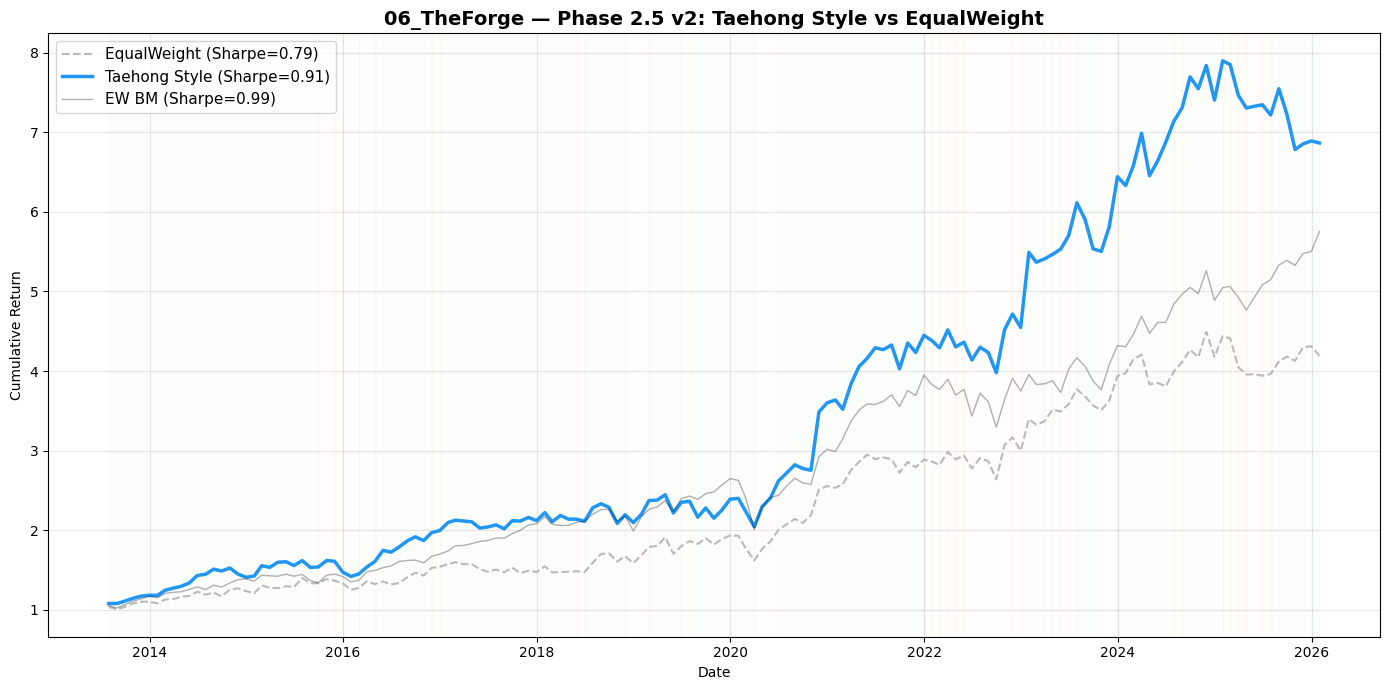


Phase 2.5 v2 결론
  동일가중 Sharpe: 0.79
  Taehong Style Sharpe: 0.91
  개선:            +0.12

  → 가중치 조정으로 Sharpe +0.12 개선!
  ⚠ Walk-Forward에서 과적합 여부 반드시 검증 필요.

→ Cell 6에서 최종 모델 (최적 가중치 + Bear 자산배분) 결합


In [20]:
# =============================================================================
# 🔨 06_TheForge.ipynb — Cell 5 v2: Phase 2.5 — 레짐별 가중치 그리드 서치
# =============================================================================
#
# [목적]
# 각 레짐(Bull/Bear/Neutral)별로 독립적으로 최적 가중치 탐색.
# 그리드: 0.0 ~ 2.0 (0.5 단위)
# 평가 기준: Sharpe Ratio
#
# [과적합 방지]
# - 레짐별 독립 탐색 (교차 최적화 없음)
# - Walk-Forward에서 최종 검증 (Phase 5)
# - 그리드 단위 0.5로 제한 (너무 세밀하면 과적합)
#
# [산출물]
# 레짐별 Top 5 조합 + 최적 조합
# 최적 조합으로 전체 백테스트 실행
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import product
from tqdm import tqdm

# ─── 레짐별 팩터 + 가중치 그리드 ─────────────────────────────────────────────

GRID_STEP = 0.5
WEIGHT_RANGE = [0.0, 0.5, 1.0, 1.5, 2.0]
# 최소 하나는 0이 아니어야 함

REGIME_FACTORS = {
    "Bull":    ["h_z", "g1_bull_z", "nsi_score"],
    "Bear":    ["h_z", "a3_z", "p5_z", "e5_z", "d1_z"],
    "Neutral": ["h_z", "d3_z"],
}

# ─── 레짐별 백테스트 함수 (단일 레짐 전용) ────────────────────────────────────

def backtest_single_regime(panel_df, ret_1m_df, target_regime, weights_dict,
                           t1_events_df=None, ticker_to_sector_dict=None,
                           top_n=30, cost_bp=20, avoid_penalty=-2.0,
                           t1_bonus=1.0, t1_lookback=7, f1_cutoff=0.20):
    """
    특정 레짐 구간만 백테스트. 가중치 그리드 서치용.
    """
    # 해당 레짐 날짜만 필터
    regime_dates = panel_df[panel_df["regime"] == target_regime]["date"].unique()
    all_dates = sorted(panel_df["date"].unique())
    
    results = []
    prev_holdings = set()
    
    for i, dt in enumerate(all_dates[:-1]):
        next_dt = all_dates[i + 1]
        
        # 해당 레짐이 아니면 스킵 (turnover 추적 위해 holdings는 유지)
        if dt not in regime_dates:
            prev_holdings = set()  # 레짐 전환 시 리셋
            continue
        
        month_data = panel_df[panel_df["date"] == dt].copy()
        if len(month_data) < top_n:
            continue
        
        # 가중 z-score
        factor_cols = [col for col in weights_dict.keys() if col in month_data.columns]
        if not factor_cols:
            continue
        
        weight_arr = np.array([weights_dict[col] for col in factor_cols])
        values_df = month_data[factor_cols].copy()
        
        valid_mask = values_df.notna().values
        weighted_vals = np.where(valid_mask, values_df.values * weight_arr, 0)
        active_weights = np.where(valid_mask, weight_arr, 0)
        
        sum_w = active_weights.sum(axis=1)
        sum_w[sum_w == 0] = np.nan
        
        month_data["composite_z"] = weighted_vals.sum(axis=1) / sum_w
        
        # Avoids (Bear/Neutral)
        if target_regime in ["Bear", "Neutral"]:
            mask_avoid = month_data["g1b_flag"] == 1
            month_data.loc[mask_avoid, "composite_z"] += avoid_penalty
        
        # F-1 필터 (Bear)
        if target_regime == "Bear":
            fscore_valid = month_data["fscore"].dropna()
            if len(fscore_valid) > 0:
                cutoff = fscore_valid.quantile(f1_cutoff)
                month_data.loc[month_data["fscore"] < cutoff, "composite_z"] = np.nan
        
        # T-1 이벤트 (Bull)
        if target_regime == "Bull" and t1_events_df is not None and len(t1_events_df) > 0:
            dt_ts = pd.Timestamp(dt)
            recent = t1_events_df[
                (t1_events_df["date"] >= dt_ts - pd.Timedelta(days=t1_lookback)) &
                (t1_events_df["date"] <= dt_ts)
            ]
            if len(recent) > 0:
                event_sectors = set(recent["sector"].unique())
                for idx_row in month_data.index:
                    tk = month_data.loc[idx_row, "ticker"]
                    sector = ticker_to_sector_dict.get(tk, "") if ticker_to_sector_dict else ""
                    if sector in event_sectors:
                        month_data.loc[idx_row, "composite_z"] += t1_bonus
        
        # Top N
        valid = month_data.dropna(subset=["composite_z"])
        if len(valid) < 10:
            continue
        top_n_actual = min(top_n, len(valid))
        top = valid.nlargest(top_n_actual, "composite_z")
        selected = top["ticker"].tolist()
        
        # 수익률
        if next_dt not in ret_1m_df.index:
            continue
        available = [t for t in selected if t in ret_1m_df.columns]
        if not available:
            continue
        rets = ret_1m_df.loc[next_dt, available].dropna()
        if len(rets) == 0:
            continue
        
        port_ret = rets.mean()
        bm_ret = ret_1m_df.loc[next_dt].dropna().mean()
        
        curr_set = set(selected)
        turnover = len(curr_set - prev_holdings) / len(curr_set) if prev_holdings else 1.0
        cost = turnover * cost_bp * 2 / 10000
        
        results.append({
            "port_ret": port_ret - cost,
            "bm_ret": bm_ret,
        })
        prev_holdings = curr_set
    
    if not results:
        return {"sharpe": -999, "cagr": 0, "months": 0, "excess": 0}
    
    df = pd.DataFrame(results)
    excess = df["port_ret"] - df["bm_ret"]
    
    port_ann = df["port_ret"].mean() * 12
    port_vol = df["port_ret"].std() * np.sqrt(12)
    sharpe = port_ann / port_vol if port_vol > 0 else 0
    
    bm_ann = df["bm_ret"].mean() * 12
    bm_vol = df["bm_ret"].std() * np.sqrt(12)
    bm_sharpe = bm_ann / bm_vol if bm_vol > 0 else 0
    
    excess_ann = excess.mean() * 12
    t_stat = excess.mean() / (excess.std() / np.sqrt(len(excess))) if excess.std() > 0 else 0
    
    return {
        "sharpe": sharpe, "bm_sharpe": bm_sharpe,
        "cagr": port_ann, "bm_cagr": bm_ann,
        "excess": excess_ann, "tstat": t_stat,
        "months": len(df),
    }


# ─── 레짐별 그리드 서치 ───────────────────────────────────────────────────────

print("=" * 70)
print("🔨 Phase 2.5 v2: 레짐별 가중치 그리드 서치")
print(f"   그리드 단위: {GRID_STEP}")
print("=" * 70)

optimal_weights = {}

for regime, factors in REGIME_FACTORS.items():
    n_factors = len(factors)
    
    # 가중치 조합 생성
    combos = list(product(WEIGHT_RANGE, repeat=n_factors))
    # 전부 0인 조합 제거
    combos = [c for c in combos if sum(c) > 0]
    
    print(f"\n{'='*60}")
    print(f"[{regime}] {n_factors} factors, {len(combos)} combinations")
    print(f"  Factors: {factors}")
    print(f"{'='*60}")
    
    best_results = []
    
    for combo in tqdm(combos, desc=f"{regime} Grid"):
        w_dict = {f: w for f, w in zip(factors, combo)}
        
        result = backtest_single_regime(
            panel, ret_1m, regime, w_dict,
            t1_events_df=t1_events,
            ticker_to_sector_dict=ticker_to_sector,
            top_n=TOP_N, cost_bp=COST_BP,
        )
        result["weights"] = w_dict
        result["combo"] = combo
        best_results.append(result)
    
    # Sharpe 기준 정렬
    best_results.sort(key=lambda x: x["sharpe"], reverse=True)
    
    # Top 10 출력
    print(f"\n  Top 10 조합 (Sharpe 기준):")
    print(f"  {'Rank':>4s}  {'Sharpe':>7s}  {'BM_Shp':>7s}  {'CAGR':>7s}  {'Excess':>7s}  "
          f"{'t-stat':>7s}  Weights")
    print(f"  {'-'*75}")
    
    for rank, r in enumerate(best_results[:10], 1):
        w_str = ", ".join([f"{f.replace('_z','').replace('_score','')}={w:.1f}" 
                          for f, w in r["weights"].items()])
        print(f"  {rank:>4d}  {r['sharpe']:>7.2f}  {r['bm_sharpe']:>7.2f}  "
              f"{r['cagr']:>6.1%}  {r['excess']:>+6.1%}  {r['tstat']:>7.2f}  {w_str}")
    
    # 최적 저장
    best = best_results[0]
    optimal_weights[regime] = best["weights"]
    
    print(f"\n  ★ 최적: Sharpe={best['sharpe']:.2f}  "
          f"Excess={best['excess']:+.1%}  t={best['tstat']:.2f}")
    
    # 동일가중 비교
    eq_w = {f: 1.0 for f in factors}
    eq_result = backtest_single_regime(
        panel, ret_1m, regime, eq_w,
        t1_events_df=t1_events,
        ticker_to_sector_dict=ticker_to_sector,
        top_n=TOP_N, cost_bp=COST_BP,
    )
    improvement = best["sharpe"] - eq_result["sharpe"]
    print(f"  동일가중: Sharpe={eq_result['sharpe']:.2f}")
    print(f"  개선: {improvement:+.2f}")

# ─── 최적 조합으로 전체 백테스트 ──────────────────────────────────────────────

print(f"\n{'='*70}")
print(f"최적 레짐별 가중치:")
print(f"{'='*70}")
for regime, w in optimal_weights.items():
    w_str = ", ".join([f"{f}={v:.1f}" for f, v in w.items()])
    print(f"  {regime:10s}: {w_str}")

# 전체 백테스트
print(f"\n전체 기간 백테스트 (최적 가중치)...")

# backtest_weighted 함수 재활용 (Cell 5에서 정의된 것)
best_weight_set = {
    "Bull": optimal_weights["Bull"],
    "Bear": optimal_weights["Bear"],
    "Neutral": optimal_weights["Neutral"],
}

bt_optimal = backtest_weighted(
    panel, ret_1m, regime_map, best_weight_set,
    t1_events, ticker_to_sector,
    top_n=TOP_N, cost_bp=COST_BP,
)

opt_perf = calc_perf(bt_optimal["cum_port"])
opt_bm = calc_perf(bt_optimal["cum_bm"])
opt_t = calc_tstat(bt_optimal["excess_net"])

# 동일가중 (Cell 3 결과) 비교
eq_bt = set_results["EqualWeight"] if "set_results" in dir() else bt_multi
eq_perf = calc_perf(eq_bt["cum_port"])

print(f"\n{'='*70}")
print(f"Phase 2.5 v2 — 최종 비교")
print(f"{'='*70}")
print(f"  {'':20s} {'CAGR':>8s} {'Sharpe':>8s} {'MaxDD':>8s} {'t-stat':>8s}")
print(f"  {'-'*56}")
print(f"  {'EW Benchmark':20s} {opt_bm['CAGR']:>7.1%} {opt_bm['Sharpe']:>8.2f} {opt_bm['MaxDD']:>7.1%}")
print(f"  {'EqualWeight':20s} {eq_perf['CAGR']:>7.1%} {eq_perf['Sharpe']:>8.2f} "
      f"{eq_perf['MaxDD']:>7.1%} {calc_tstat(eq_bt['excess_net']):>8.2f}")
print(f"  {'Taehong Style':20s} {opt_perf['CAGR']:>7.1%} {opt_perf['Sharpe']:>8.2f} "
      f"{opt_perf['MaxDD']:>7.1%} {opt_t:>8.2f}")

# 레짐별 상세
print(f"\n  레짐별 상세:")
for regime in ["Bull", "Bear", "Neutral"]:
    sub = bt_optimal[bt_optimal["regime"] == regime]
    if len(sub) < 2:
        continue
    cum = (1 + sub["port_ret_net"]).cumprod()
    cum_bm = (1 + sub["bm_ret"]).cumprod()
    rp = calc_perf(cum)
    rb = calc_perf(cum_bm)
    flag = "WIN" if rp["Sharpe"] > rb["Sharpe"] else "LOSE"
    print(f"    {regime:8s}: Sharpe={rp['Sharpe']:.2f}/{rb['Sharpe']:.2f} "
          f"CAGR={rp['CAGR']:+.1%}/{rb['CAGR']:+.1%} {flag}")

# ─── 차트 ─────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(eq_bt.index, eq_bt["cum_port"], label=f"EqualWeight (Sharpe={eq_perf['Sharpe']:.2f})",
        linewidth=1.5, color="#9E9E9E", linestyle="--", alpha=0.7)
ax.plot(bt_optimal.index, bt_optimal["cum_port"], 
        label=f"Taehong Style (Sharpe={opt_perf['Sharpe']:.2f})",
        linewidth=2.5, color="#2196F3")
ax.plot(bt_optimal.index, bt_optimal["cum_bm"], 
        label=f"EW BM (Sharpe={opt_bm['Sharpe']:.2f})",
        linewidth=1, color="black", alpha=0.3)

# 레짐 배경
regime_colors = {"Bull": "#E8F5E9", "Bear": "#FFEBEE", "Neutral": "#FFF3E0"}
prev_regime = None
prev_date = bt_optimal.index[0]
for dt_idx in bt_optimal.index:
    r = bt_optimal.loc[dt_idx, "regime"]
    if r != prev_regime and prev_regime is not None:
        ax.axvspan(prev_date, dt_idx, alpha=0.15, color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)
        prev_date = dt_idx
    prev_regime = r
ax.axvspan(prev_date, bt_optimal.index[-1], alpha=0.15, color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)

ax.set_title("06_TheForge — Phase 2.5 v2: Taehong Style vs EqualWeight", fontsize=14, fontweight="bold")
ax.legend(loc="upper left", fontsize=11)
ax.set_ylabel("Cumulative Return")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(Path(r"C:\QP2\data\interim") / "06_theforge_phase25_v2.png"), dpi=150, bbox_inches="tight")
plt.show()

improvement = opt_perf["Sharpe"] - eq_perf["Sharpe"]
print(f"\n{'='*70}")
print(f"Phase 2.5 v2 결론")
print(f"{'='*70}")
print(f"  동일가중 Sharpe: {eq_perf['Sharpe']:.2f}")
print(f"  Taehong Style Sharpe: {opt_perf['Sharpe']:.2f}")
print(f"  개선:            {improvement:+.2f}")

if improvement > 0:
    print(f"\n  → 가중치 조정으로 Sharpe {improvement:+.2f} 개선!")
    print(f"  ⚠ Walk-Forward에서 과적합 여부 반드시 검증 필요.")
else:
    print(f"\n  → 동일가중 유지. 가중치 조정 효과 없음.")

print(f"\n→ Cell 6에서 최종 모델 (최적 가중치 + Bear 자산배분) 결합")

✅ 시총가중 SPY 근사: 205 months
   시총가중 종목 수: ~277

전략 vs EW vs SPY(시총가중) 비교
                           CAGR   Sharpe    MaxDD
  ----------------------------------------------
  SPY (Cap-Weight)       14.4%     0.89  -23.2%
  EW Benchmark           14.4%     0.99  -24.1%
  EqualWeight Model      11.7%     0.79  -16.2%
  Taehong Style          15.8%     0.91  -16.4%

  Taehong Style vs SPY:
    Excess (ann.): +7.0%
    t-stat:        1.55


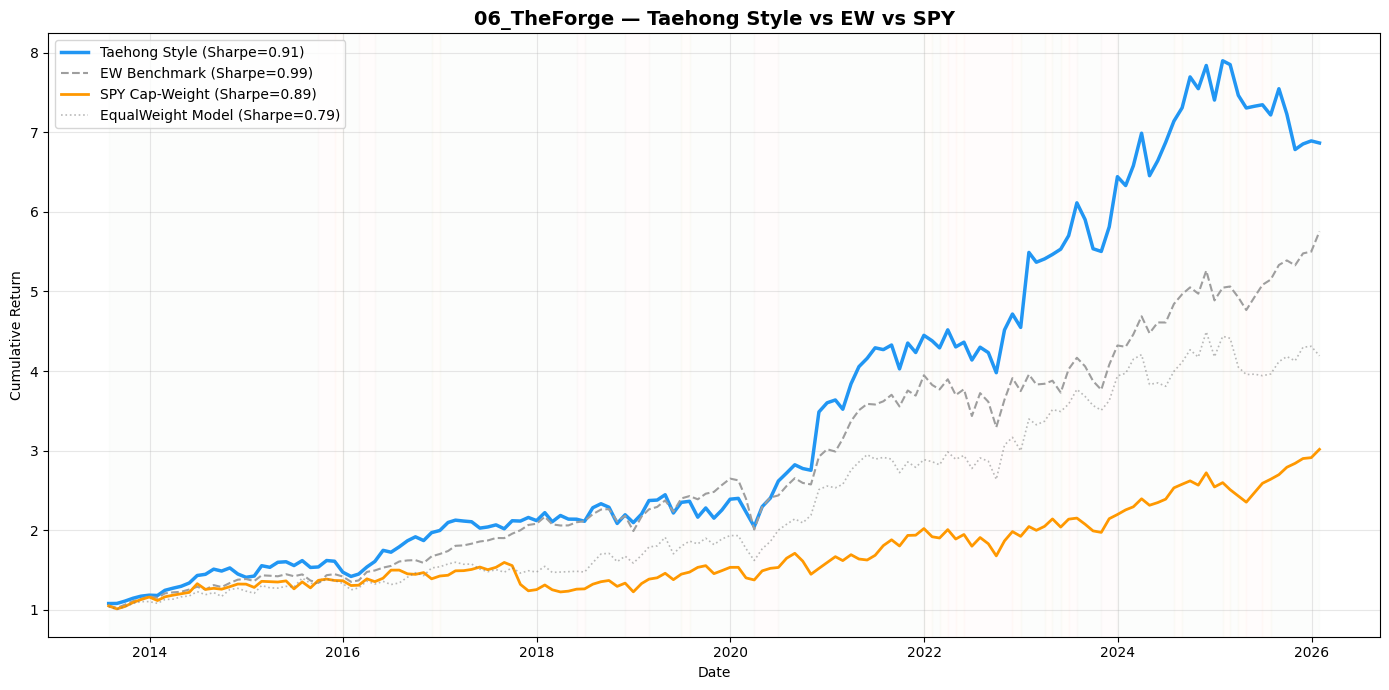


  ✅ Taehong Style이 SPY를 Sharpe 기준 이겼다!


In [16]:
# =============================================================================
# 🔨 06_TheForge — SPY(시총가중) 벤치마크 비교
# =============================================================================
# Cell 5 v2 실행 후 추가로 실행.
# bt_optimal, bt_multi가 메모리에 있어야 함.
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

SAVE_DIR = Path(r"C:\QP2\data\interim")

# ─── 시총가중 벤치마크 (SPY 근사) ─────────────────────────────────────────────

# mktcap_monthly가 있으면 시총가중, 없으면 상위 시총 50종목 EW로 근사
try:
    mktcap_m = pd.read_parquet(SAVE_DIR / "mktcap_monthly.parquet")
    if "date" in mktcap_m.columns:
        mktcap_m = mktcap_m.set_index("date")
    mktcap_m.index = pd.to_datetime(mktcap_m.index)
    
    # 시총가중 수익률 계산
    common_dates = ret_1m.index.intersection(mktcap_m.index)
    common_tickers = ret_1m.columns.intersection(mktcap_m.columns)
    
    spy_rets = []
    for dt in common_dates:
        mc = mktcap_m.loc[dt, common_tickers].dropna()
        r = ret_1m.loc[dt, mc.index].dropna()
        common = mc.index.intersection(r.index)
        if len(common) < 50:
            continue
        mc_c = mc[common]
        r_c = r[common]
        weights = mc_c / mc_c.sum()
        spy_ret = (weights * r_c).sum()
        spy_rets.append({"date": dt, "spy_ret": spy_ret})
    
    spy_df = pd.DataFrame(spy_rets).set_index("date")
    spy_df["cum_spy"] = (1 + spy_df["spy_ret"]).cumprod()
    print(f"✅ 시총가중 SPY 근사: {len(spy_df)} months")
    print(f"   시총가중 종목 수: ~{len(common_tickers)}")
    has_spy = True
    
except Exception as e:
    print(f"⚠ mktcap_monthly 로드 실패: {e}")
    print("  → EW 벤치마크만 사용")
    has_spy = False

if has_spy:
    # SPY 성과
    spy_perf_data = calc_perf(spy_df["cum_spy"])
    
    # Taehong Style 성과 (이미 계산됨)
    opt_perf = calc_perf(bt_optimal["cum_port"])
    eq_perf = calc_perf(bt_multi["cum_port"])
    bm_perf = calc_perf(bt_multi["cum_bm"])
    
    # 공통 기간 맞추기
    common_idx = bt_optimal.index.intersection(spy_df.index)
    
    print(f"\n{'='*70}")
    print(f"전략 vs EW vs SPY(시총가중) 비교")
    print(f"{'='*70}")
    print(f"  {'':20s} {'CAGR':>8s} {'Sharpe':>8s} {'MaxDD':>8s}")
    print(f"  {'-'*46}")
    print(f"  {'SPY (Cap-Weight)':20s} {spy_perf_data['CAGR']:>7.1%} {spy_perf_data['Sharpe']:>8.2f} "
          f"{spy_perf_data['MaxDD']:>7.1%}")
    print(f"  {'EW Benchmark':20s} {bm_perf['CAGR']:>7.1%} {bm_perf['Sharpe']:>8.2f} "
          f"{bm_perf['MaxDD']:>7.1%}")
    print(f"  {'EqualWeight Model':20s} {eq_perf['CAGR']:>7.1%} {eq_perf['Sharpe']:>8.2f} "
          f"{eq_perf['MaxDD']:>7.1%}")
    print(f"  {'Taehong Style':20s} {opt_perf['CAGR']:>7.1%} {opt_perf['Sharpe']:>8.2f} "
          f"{opt_perf['MaxDD']:>7.1%}")
    
    # 초과수익 (vs SPY)
    opt_vs_spy = bt_optimal.loc[common_idx, "port_ret_net"] - spy_df.loc[common_idx, "spy_ret"]
    excess_ann_spy = opt_vs_spy.mean() * 12
    t_spy = opt_vs_spy.mean() / (opt_vs_spy.std() / np.sqrt(len(opt_vs_spy))) if opt_vs_spy.std() > 0 else 0
    
    print(f"\n  Taehong Style vs SPY:")
    print(f"    Excess (ann.): {excess_ann_spy:+.1%}")
    print(f"    t-stat:        {t_spy:.2f}")
    
    # ─── 차트 (공통 시작점 맞춤) ──────────────────────────────────────────
    
    # 공통 기간으로 정렬
    start_date = max(bt_optimal.index.min(), spy_df.index.min(), bt_multi.index.min())
    end_date = min(bt_optimal.index.max(), spy_df.index.max(), bt_multi.index.max())
    
    opt_common = bt_optimal.loc[start_date:end_date]
    bm_common = bt_multi.loc[start_date:end_date]
    spy_common = spy_df.loc[start_date:end_date]
    
    # 전부 1.0에서 시작하도록 재계산
    cum_opt = (1 + opt_common["port_ret_net"]).cumprod()
    cum_bm = (1 + bm_common["bm_ret"]).cumprod()
    cum_eq = (1 + bm_common["port_ret_net"]).cumprod()
    cum_spy = (1 + spy_common["spy_ret"]).cumprod()
    
    fig, ax = plt.subplots(figsize=(14, 7))
    
    ax.plot(cum_opt.index, cum_opt,
            label=f"Taehong Style (Sharpe={opt_perf['Sharpe']:.2f})",
            linewidth=2.5, color="#2196F3")
    
    ax.plot(cum_bm.index, cum_bm,
            label=f"EW Benchmark (Sharpe={bm_perf['Sharpe']:.2f})",
            linewidth=1.5, color="#9E9E9E", linestyle="--")
    
    ax.plot(cum_spy.index, cum_spy,
            label=f"SPY Cap-Weight (Sharpe={spy_perf_data['Sharpe']:.2f})",
            linewidth=2, color="#FF9800")
    
    ax.plot(cum_eq.index, cum_eq,
            label=f"EqualWeight Model (Sharpe={eq_perf['Sharpe']:.2f})",
            linewidth=1.2, color="#757575", alpha=0.5, linestyle=":")
    
    # 레짐 배경
    regime_colors = {"Bull": "#E8F5E9", "Bear": "#FFEBEE", "Neutral": "#FFF3E0"}
    prev_regime = None
    prev_date = bt_optimal.index[0]
    for dt_idx in bt_optimal.index:
        r = bt_optimal.loc[dt_idx, "regime"]
        if r != prev_regime and prev_regime is not None:
            ax.axvspan(prev_date, dt_idx, alpha=0.12, 
                      color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)
            prev_date = dt_idx
        prev_regime = r
    ax.axvspan(prev_date, bt_optimal.index[-1], alpha=0.12,
              color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)
    
    ax.set_title("06_TheForge — Taehong Style vs EW vs SPY", fontsize=14, fontweight="bold")
    ax.legend(loc="upper left", fontsize=10)
    ax.set_ylabel("Cumulative Return")
    ax.set_xlabel("Date")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(str(SAVE_DIR / "06_theforge_vs_spy.png"), dpi=150, bbox_inches="tight")
    plt.show()
    
    # 결론
    if opt_perf["Sharpe"] > spy_perf_data["Sharpe"]:
        print(f"\n  ✅ Taehong Style이 SPY를 Sharpe 기준 이겼다!")
    else:
        print(f"\n  ❌ SPY가 아직 우위. Sharpe 차이: "
              f"{spy_perf_data['Sharpe'] - opt_perf['Sharpe']:+.2f}")

In [18]:
import yfinance as yf
import pandas as pd
from pathlib import Path

spy = yf.download("^GSPC", start="2013-01-01", end="2026-03-01")
print(spy.columns.tolist())  # 컬럼 확인
print(spy.head())

# 컬럼 flatten (MultiIndex인 경우)
if isinstance(spy.columns, pd.MultiIndex):
    spy.columns = spy.columns.get_level_values(0)

spy = spy[["Close"]].rename(columns={"Close": "spy_close"})
spy.to_parquet(Path(r"C:\QP2\data\interim\gspc_daily.parquet"))
print(f"✅ S&P500 지수 저장: {len(spy)} rows")

[*********************100%***********************]  1 of 1 completed

[('Close', '^GSPC'), ('High', '^GSPC'), ('Low', '^GSPC'), ('Open', '^GSPC'), ('Volume', '^GSPC')]
Price             Close         High          Low         Open      Volume
Ticker            ^GSPC        ^GSPC        ^GSPC        ^GSPC       ^GSPC
Date                                                                      
2013-01-02  1462.420044  1462.430054  1426.189941  1426.189941  4202600000
2013-01-03  1459.369995  1465.469971  1455.530029  1462.420044  3829730000
2013-01-04  1466.469971  1467.939941  1458.989990  1459.369995  3424290000
2013-01-07  1461.890015  1466.469971  1456.619995  1466.469971  3304970000
2013-01-08  1457.150024  1461.890015  1451.640015  1461.890015  3601600000
✅ S&P500 지수 저장: 3299 rows


Taehong Style vs EW vs SPY
                           CAGR   Sharpe    MaxDD
  ----------------------------------------------
  SPY (S&P500)           11.9%     0.87  -24.8%
  EW Benchmark           14.4%     0.99  -24.1%
  Taehong Style          15.8%     0.91  -16.4%

  Taehong Style vs SPY:
    Excess (ann.): +4.2%
    t-stat:        1.23


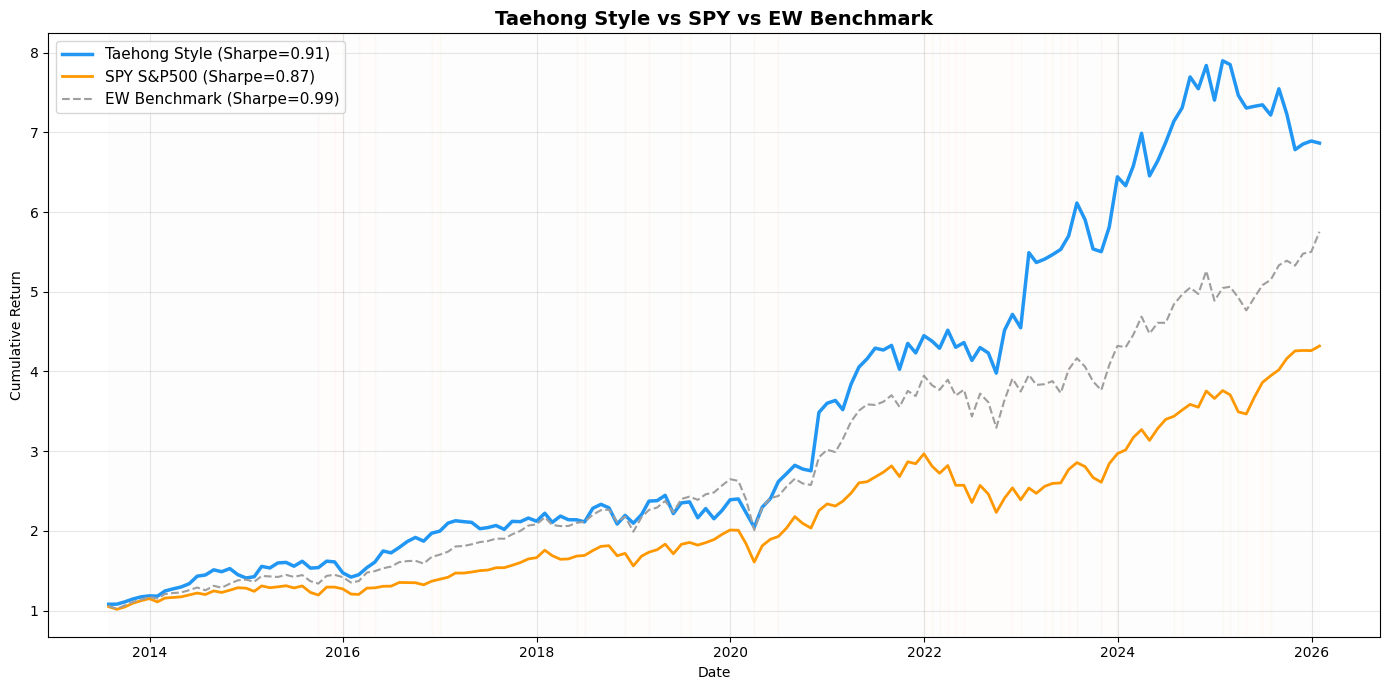


  ✅ Taehong Style이 SPY를 이겼다! Sharpe 0.91 vs 0.87


In [19]:
# =============================================================================
# SPY(S&P500 지수) vs Taehong Style 비교
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

SAVE_DIR = Path(r"C:\QP2\data\interim")

# ── SPY 로드 + 월간 수익률 ──
spy_raw = pd.read_parquet(SAVE_DIR / "gspc_daily.parquet")
if "date" in spy_raw.columns:
    spy_raw = spy_raw.set_index("date")
spy_raw.index = pd.to_datetime(spy_raw.index)
spy_m = spy_raw["spy_close"].resample("ME").last()
spy_ret = spy_m.pct_change().dropna()
spy_ret.name = "spy_ret"

# 공통 기간
common_idx = bt_optimal.index.intersection(spy_ret.index)
spy_ret_c = spy_ret.loc[common_idx]
opt_ret_c = bt_optimal.loc[common_idx, "port_ret_net"]
ew_ret_c = bt_optimal.loc[common_idx, "bm_ret"]

cum_spy = (1 + spy_ret_c).cumprod()
cum_opt = (1 + opt_ret_c).cumprod()
cum_ew = (1 + ew_ret_c).cumprod()

# 성과 계산
spy_perf = calc_perf(cum_spy)
opt_perf = calc_perf(cum_opt)
ew_perf = calc_perf(cum_ew)

# vs SPY 초과수익
excess_vs_spy = opt_ret_c - spy_ret_c
excess_ann = excess_vs_spy.mean() * 12
t_spy = excess_vs_spy.mean() / (excess_vs_spy.std() / np.sqrt(len(excess_vs_spy))) if excess_vs_spy.std() > 0 else 0

print(f"{'='*70}")
print(f"Taehong Style vs EW vs SPY")
print(f"{'='*70}")
print(f"  {'':20s} {'CAGR':>8s} {'Sharpe':>8s} {'MaxDD':>8s}")
print(f"  {'-'*46}")
print(f"  {'SPY (S&P500)':20s} {spy_perf['CAGR']:>7.1%} {spy_perf['Sharpe']:>8.2f} {spy_perf['MaxDD']:>7.1%}")
print(f"  {'EW Benchmark':20s} {ew_perf['CAGR']:>7.1%} {ew_perf['Sharpe']:>8.2f} {ew_perf['MaxDD']:>7.1%}")
print(f"  {'Taehong Style':20s} {opt_perf['CAGR']:>7.1%} {opt_perf['Sharpe']:>8.2f} {opt_perf['MaxDD']:>7.1%}")
print(f"\n  Taehong Style vs SPY:")
print(f"    Excess (ann.): {excess_ann:+.1%}")
print(f"    t-stat:        {t_spy:.2f}")

# ── 차트 ──
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(cum_opt.index, cum_opt, label=f"Taehong Style (Sharpe={opt_perf['Sharpe']:.2f})",
        linewidth=2.5, color="#2196F3")
ax.plot(cum_spy.index, cum_spy, label=f"SPY S&P500 (Sharpe={spy_perf['Sharpe']:.2f})",
        linewidth=2, color="#FF9800")
ax.plot(cum_ew.index, cum_ew, label=f"EW Benchmark (Sharpe={ew_perf['Sharpe']:.2f})",
        linewidth=1.5, color="#9E9E9E", linestyle="--")

regime_colors = {"Bull": "#E8F5E9", "Bear": "#FFEBEE", "Neutral": "#FFF3E0"}
prev_regime = None
prev_date = bt_optimal.index[0]
for dt_idx in bt_optimal.index:
    r = bt_optimal.loc[dt_idx, "regime"]
    if r != prev_regime and prev_regime is not None:
        ax.axvspan(prev_date, dt_idx, alpha=0.12, color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)
        prev_date = dt_idx
    prev_regime = r
ax.axvspan(prev_date, bt_optimal.index[-1], alpha=0.12, color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)

ax.set_title("Taehong Style vs SPY vs EW Benchmark", fontsize=14, fontweight="bold")
ax.legend(loc="upper left", fontsize=11)
ax.set_ylabel("Cumulative Return")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

if opt_perf["Sharpe"] > spy_perf["Sharpe"]:
    print(f"\n  ✅ Taehong Style이 SPY를 이겼다! Sharpe {opt_perf['Sharpe']:.2f} vs {spy_perf['Sharpe']:.2f}")
else:
    print(f"\n  ❌ SPY가 우위. 차이: {spy_perf['Sharpe'] - opt_perf['Sharpe']:+.2f}")

In [5]:
# ─── 함수 정의 + 1차 최적 하드코딩 ───────────────────────────────────────────  5번셀 스킵용

import numpy as np
import pandas as pd
from pathlib import Path
from itertools import product
from tqdm import tqdm

# ticker_to_sector 매핑 (Cell 3에서 했던 것)
universe = pd.read_parquet(Path(r"C:\QP2\data\meta") / "sp500_universe.parquet")
ticker_to_sector = universe.set_index("ticker_yahoo")["GICS Sector"].to_dict()
print(f"✅ ticker_to_sector: {len(ticker_to_sector)} tickers")

def backtest_single_regime(panel_df, ret_1m_df, target_regime, weights_dict,
                           t1_events_df=None, ticker_to_sector_dict=None,
                           top_n=30, cost_bp=20, avoid_penalty=-2.0,
                           t1_bonus=1.0, t1_lookback=7, f1_cutoff=0.20):
    regime_dates = panel_df[panel_df["regime"] == target_regime]["date"].unique()
    all_dates = sorted(panel_df["date"].unique())
    results = []
    prev_holdings = set()
    for i, dt in enumerate(all_dates[:-1]):
        next_dt = all_dates[i + 1]
        if dt not in regime_dates:
            prev_holdings = set()
            continue
        month_data = panel_df[panel_df["date"] == dt].copy()
        if len(month_data) < top_n:
            continue
        factor_cols = [col for col in weights_dict.keys() if col in month_data.columns]
        if not factor_cols:
            continue
        weight_arr = np.array([weights_dict[col] for col in factor_cols])
        values_df = month_data[factor_cols].copy()
        valid_mask = values_df.notna().values
        weighted_vals = np.where(valid_mask, values_df.values * weight_arr, 0)
        active_weights = np.where(valid_mask, weight_arr, 0)
        sum_w = active_weights.sum(axis=1)
        sum_w[sum_w == 0] = np.nan
        month_data["composite_z"] = weighted_vals.sum(axis=1) / sum_w
        if target_regime in ["Bear", "Neutral"]:
            mask_avoid = month_data["g1b_flag"] == 1
            month_data.loc[mask_avoid, "composite_z"] += avoid_penalty
        if target_regime == "Bear":
            fscore_valid = month_data["fscore"].dropna()
            if len(fscore_valid) > 0:
                cutoff = fscore_valid.quantile(f1_cutoff)
                month_data.loc[month_data["fscore"] < cutoff, "composite_z"] = np.nan
        if target_regime == "Bull" and t1_events_df is not None and len(t1_events_df) > 0:
            dt_ts = pd.Timestamp(dt)
            recent = t1_events_df[
                (t1_events_df["date"] >= dt_ts - pd.Timedelta(days=t1_lookback)) &
                (t1_events_df["date"] <= dt_ts)
            ]
            if len(recent) > 0:
                event_sectors = set(recent["sector"].unique())
                for idx_row in month_data.index:
                    tk = month_data.loc[idx_row, "ticker"]
                    sector = ticker_to_sector_dict.get(tk, "") if ticker_to_sector_dict else ""
                    if sector in event_sectors:
                        month_data.loc[idx_row, "composite_z"] += t1_bonus
        valid = month_data.dropna(subset=["composite_z"])
        if len(valid) < 10:
            continue
        top_n_actual = min(top_n, len(valid))
        top = valid.nlargest(top_n_actual, "composite_z")
        selected = top["ticker"].tolist()
        if next_dt not in ret_1m_df.index:
            continue
        available = [t for t in selected if t in ret_1m_df.columns]
        if not available:
            continue
        rets = ret_1m_df.loc[next_dt, available].dropna()
        if len(rets) == 0:
            continue
        port_ret = rets.mean()
        bm_ret = ret_1m_df.loc[next_dt].dropna().mean()
        curr_set = set(selected)
        turnover = len(curr_set - prev_holdings) / len(curr_set) if prev_holdings else 1.0
        cost = turnover * cost_bp * 2 / 10000
        results.append({"port_ret": port_ret - cost, "bm_ret": bm_ret})
        prev_holdings = curr_set
    if not results:
        return {"sharpe": -999, "cagr": 0, "months": 0, "excess": 0}
    df = pd.DataFrame(results)
    excess = df["port_ret"] - df["bm_ret"]
    port_ann = df["port_ret"].mean() * 12
    port_vol = df["port_ret"].std() * np.sqrt(12)
    sharpe = port_ann / port_vol if port_vol > 0 else 0
    bm_ann = df["bm_ret"].mean() * 12
    bm_vol = df["bm_ret"].std() * np.sqrt(12)
    bm_sharpe = bm_ann / bm_vol if bm_vol > 0 else 0
    excess_ann = excess.mean() * 12
    t_stat = excess.mean() / (excess.std() / np.sqrt(len(excess))) if excess.std() > 0 else 0
    return {"sharpe": sharpe, "bm_sharpe": bm_sharpe, "cagr": port_ann, "bm_cagr": bm_ann,
            "excess": excess_ann, "tstat": t_stat, "months": len(df)}


def backtest_weighted(panel_df, ret_1m_df, regime_map_dict, weight_set,
                      t1_events_df, ticker_to_sector_dict,
                      top_n=30, cost_bp=20, avoid_penalty=-2.0,
                      t1_bonus=1.0, t1_lookback=7, f1_cutoff=0.20):
    all_dates = sorted(panel_df["date"].unique())
    results = []
    prev_holdings = set()
    for i, dt in enumerate(all_dates[:-1]):
        next_dt = all_dates[i + 1]
        regime_info = regime_map_dict.get(dt, None)
        if regime_info is None:
            dt_me = pd.Timestamp(dt) + pd.offsets.MonthEnd(0)
            regime_info = regime_map_dict.get(dt_me, None)
        if regime_info is None:
            continue
        regime = regime_info["regime"]
        bear_phase = regime_info.get("bear_phase", "")
        month_data = panel_df[panel_df["date"] == dt].copy()
        if len(month_data) < top_n:
            continue
        weights = weight_set.get(regime, {})
        if not weights:
            continue
        factor_cols = [col for col in weights.keys() if col in month_data.columns]
        if not factor_cols:
            continue
        weight_arr = np.array([weights[col] for col in factor_cols])
        values_df = month_data[factor_cols].copy()
        valid_mask = values_df.notna().values
        weighted_vals = np.where(valid_mask, values_df.values * weight_arr, 0)
        active_weights = np.where(valid_mask, weight_arr, 0)
        sum_w = active_weights.sum(axis=1)
        sum_w[sum_w == 0] = np.nan
        month_data["composite_z"] = weighted_vals.sum(axis=1) / sum_w
        if regime in ["Bear", "Neutral"]:
            mask_avoid = month_data["g1b_flag"] == 1
            month_data.loc[mask_avoid, "composite_z"] += avoid_penalty
        if regime == "Bear":
            fscore_valid = month_data["fscore"].dropna()
            if len(fscore_valid) > 0:
                cutoff = fscore_valid.quantile(f1_cutoff)
                month_data.loc[month_data["fscore"] < cutoff, "composite_z"] = np.nan
        if regime == "Bull" and len(t1_events_df) > 0:
            dt_ts = pd.Timestamp(dt)
            recent = t1_events_df[
                (t1_events_df["date"] >= dt_ts - pd.Timedelta(days=t1_lookback)) &
                (t1_events_df["date"] <= dt_ts)
            ]
            if len(recent) > 0:
                event_sectors = set(recent["sector"].unique())
                for idx_row in month_data.index:
                    tk = month_data.loc[idx_row, "ticker"]
                    sector = ticker_to_sector_dict.get(tk, "")
                    if sector in event_sectors:
                        month_data.loc[idx_row, "composite_z"] += t1_bonus
        valid = month_data.dropna(subset=["composite_z"])
        top_n_actual = min(top_n, max(10, len(valid)))
        top = valid.nlargest(top_n_actual, "composite_z")
        selected = top["ticker"].tolist()
        if next_dt not in ret_1m_df.index:
            continue
        available = [t for t in selected if t in ret_1m_df.columns]
        if not available:
            continue
        rets = ret_1m_df.loc[next_dt, available].dropna()
        if len(rets) == 0:
            continue
        port_ret = rets.mean()
        bm_ret = ret_1m_df.loc[next_dt].dropna().mean()
        curr_set = set(selected)
        turnover = len(curr_set - prev_holdings) / len(curr_set) if prev_holdings else 1.0
        cost = turnover * cost_bp * 2 / 10000
        results.append({"date": next_dt, "regime": regime, "bear_phase": bear_phase,
                        "port_ret_net": port_ret - cost, "bm_ret": bm_ret, "turnover": turnover})
        prev_holdings = curr_set
    df = pd.DataFrame(results)
    if len(df) == 0:
        return df
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date")
    df["excess_net"] = df["port_ret_net"] - df["bm_ret"]
    df["cum_port"] = (1 + df["port_ret_net"]).cumprod()
    df["cum_bm"] = (1 + df["bm_ret"]).cumprod()
    return df


# ─── 1차 최적 하드코딩 ───────────────────────────────────────────────────────

optimal_weights = {
    "Bull":    {"h_z": 0.0, "g1_bull_z": 2.0, "nsi_score": 0.5},
    "Bear":    {"h_z": 0.5, "a3_z": 1.0, "p5_z": 0.5, "e5_z": 2.0, "d1_z": 0.5},
    "Neutral": {"h_z": 0.5, "d3_z": 1.5},
}

bt_optimal = backtest_weighted(
    panel, ret_1m, regime_map,
    {"Bull": optimal_weights["Bull"], "Bear": optimal_weights["Bear"], "Neutral": optimal_weights["Neutral"]},
    t1_events, ticker_to_sector,
    top_n=TOP_N, cost_bp=COST_BP,
)
print("✅ 함수 정의 + bt_optimal 완료")

✅ ticker_to_sector: 503 tickers
✅ 함수 정의 + bt_optimal 완료


In [13]:
# =============================================================================
# 🔨 06_TheForge.ipynb — Cell 5.5: 2차 세분화 그리드 서치
# =============================================================================
#
# [목적]
# 1차 그리드(0.5 단위) 최적값 주변을 0.2 단위로 세밀 탐색.
# 목표: 최적값이 robust한지 확인 + 미세 개선
#
# [전제]
# Cell 5 v2 실행 완료. optimal_weights, backtest_single_regime 정의됨.
#
# [1차 최적 (0.5 단위)]
# Bull:    h=0.0, g1_bull=2.0, nsi=0.5
# Bear:    h=0.5, a3=1.0, p5=0.5, e5=2.0, d1=0.5
# Neutral: h=0.5, d3=1.5
# =============================================================================

import numpy as np
import pandas as pd
from itertools import product
from tqdm import tqdm
import matplotlib.pyplot as plt
from pathlib import Path

# ─── 1차 최적값 주변 그리드 생성 ──────────────────────────────────────────────

def make_fine_grid(center_weights, step=0.2, half_range=0.4):
    """
    center_weights: {"h_z": 0.0, "g1_bull_z": 2.0, ...}
    각 팩터별로 center ± half_range 범위를 step 단위로 생성.
    최소 0.0, 최대 2.5 클리핑.
    """
    factor_ranges = {}
    for f, center in center_weights.items():
        low = max(0.0, center - half_range)
        high = min(2.5, center + half_range)
        values = np.arange(low, high + step/2, step).round(2).tolist()
        # 중복 제거 + 정렬
        values = sorted(set(values))
        factor_ranges[f] = values
    return factor_ranges


# ─── 1차 최적값 (Cell 5 결과에서 가져오기) ────────────────────────────────────

# optimal_weights가 Cell 5에서 정의되어 있어야 함
print("=" * 70)
print("🔨 Phase 2.5 — 2차 세분화 (0.2 단위)")
print("=" * 70)

print("\n1차 최적값:")
for regime, w in optimal_weights.items():
    w_str = ", ".join([f"{f}={v:.1f}" for f, v in w.items()])
    print(f"  {regime:10s}: {w_str}")

# ─── 레짐별 세분화 ────────────────────────────────────────────────────────────

refined_weights = {}
refinement_stability = {}  # robust 확인용

for regime, center_w in optimal_weights.items():
    factors = list(center_w.keys())
    fine_ranges = make_fine_grid(center_w, step=0.2, half_range=0.4)
    
    # 조합 생성
    range_lists = [fine_ranges[f] for f in factors]
    combos = list(product(*range_lists))
    combos = [c for c in combos if sum(c) > 0]
    
    print(f"\n{'='*60}")
    print(f"[{regime}] 세분화")
    print(f"  탐색 범위:")
    for f in factors:
        print(f"    {f}: {fine_ranges[f]}")
    print(f"  조합 수: {len(combos)}")
    print(f"{'='*60}")
    
    results = []
    
    for combo in tqdm(combos, desc=f"{regime} Fine"):
        w_dict = {f: w for f, w in zip(factors, combo)}
        
        result = backtest_single_regime(
            panel, ret_1m, regime, w_dict,
            t1_events_df=t1_events,
            ticker_to_sector_dict=ticker_to_sector,
            top_n=TOP_N, cost_bp=COST_BP,
        )
        result["weights"] = w_dict
        result["combo"] = combo
        results.append(result)
    
    results.sort(key=lambda x: x["sharpe"], reverse=True)
    
    # Top 10
    print(f"\n  Top 10:")
    print(f"  {'Rank':>4s}  {'Sharpe':>7s}  {'CAGR':>7s}  {'Excess':>7s}  {'t-stat':>7s}  Weights")
    print(f"  {'-'*70}")
    
    for rank, r in enumerate(results[:10], 1):
        w_str = ", ".join([f"{f.split('_')[0]}={w:.1f}" for f, w in r["weights"].items()])
        print(f"  {rank:>4d}  {r['sharpe']:>7.2f}  {r['cagr']:>6.1%}  "
              f"{r['excess']:>+6.1%}  {r['tstat']:>7.2f}  {w_str}")
    
    best = results[0]
    refined_weights[regime] = best["weights"]
    
    # 1차 최적 대비
    center_result = [r for r in results if r["combo"] == tuple(center_w.values())]
    if center_result:
        center_sharpe = center_result[0]["sharpe"]
    else:
        # 1차 최적이 세분화 범위에 없을 수도 (반올림)
        center_sharpe = best["sharpe"]
    
    improvement = best["sharpe"] - center_sharpe
    
    print(f"\n  ★ 2차 최적: Sharpe={best['sharpe']:.3f}")
    print(f"  1차 최적:          Sharpe={center_sharpe:.3f}")
    print(f"  개선:              {improvement:+.3f}")
    
    # Robust 체크: Top 5의 Sharpe 범위
    top5_sharpes = [r["sharpe"] for r in results[:5]]
    sharpe_range = max(top5_sharpes) - min(top5_sharpes)
    refinement_stability[regime] = {
        "top5_range": sharpe_range,
        "best_sharpe": best["sharpe"],
        "center_sharpe": center_sharpe,
        "improvement": improvement,
        "robust": sharpe_range < 0.05,  # Top 5 Sharpe가 0.05 이내면 robust
    }
    
    stable = "✅ ROBUST" if sharpe_range < 0.05 else "⚠ SENSITIVE"
    print(f"  Top 5 Sharpe 범위: {sharpe_range:.3f} → {stable}")

# ─── 세분화 최적으로 전체 백테스트 ────────────────────────────────────────────

print(f"\n{'='*70}")
print(f"2차 세분화 최적 가중치:")
print(f"{'='*70}")
for regime, w in refined_weights.items():
    w_str = ", ".join([f"{f}={v:.2f}" for f, v in w.items()])
    stable = "✅" if refinement_stability[regime]["robust"] else "⚠"
    print(f"  {regime:10s}: {w_str}  {stable}")

# 전체 백테스트
best_weight_set_refined = {
    "Bull": refined_weights["Bull"],
    "Bear": refined_weights["Bear"],
    "Neutral": refined_weights["Neutral"],
}

bt_refined = backtest_weighted(
    panel, ret_1m, regime_map, best_weight_set_refined,
    t1_events, ticker_to_sector,
    top_n=TOP_N, cost_bp=COST_BP,
)

ref_perf = calc_perf(bt_refined["cum_port"])
ref_bm = calc_perf(bt_refined["cum_bm"])
ref_t = calc_tstat(bt_refined["excess_net"])

# 1차 최적 비교
opt_perf_1st = calc_perf(bt_optimal["cum_port"])

# SPY 비교
spy_raw = pd.read_parquet(Path(r"C:\QP2\data\interim") / "gspc_daily.parquet")
if "date" in spy_raw.columns:
    spy_raw = spy_raw.set_index("date")
spy_raw.index = pd.to_datetime(spy_raw.index)
spy_m = spy_raw["spy_close"].resample("ME").last()
spy_ret = spy_m.pct_change().dropna()
common_idx = bt_refined.index.intersection(spy_ret.index)
cum_spy = (1 + spy_ret.loc[common_idx]).cumprod()
spy_perf = calc_perf(cum_spy)

print(f"\n{'='*70}")
print(f"최종 비교: 1차 vs 2차 vs SPY vs EW")
print(f"{'='*70}")
print(f"  {'':22s} {'CAGR':>8s} {'Sharpe':>8s} {'MaxDD':>8s} {'t-stat':>8s}")
print(f"  {'-'*58}")
print(f"  {'SPY (S&P500)':22s} {spy_perf['CAGR']:>7.1%} {spy_perf['Sharpe']:>8.2f} {spy_perf['MaxDD']:>7.1%}")
print(f"  {'EW Benchmark':22s} {ref_bm['CAGR']:>7.1%} {ref_bm['Sharpe']:>8.2f} {ref_bm['MaxDD']:>7.1%}")
print(f"  {'Taehong Style (1차)':22s} {opt_perf_1st['CAGR']:>7.1%} {opt_perf_1st['Sharpe']:>8.2f} "
      f"{opt_perf_1st['MaxDD']:>7.1%}")
print(f"  {'Taehong Style (2차)':22s} {ref_perf['CAGR']:>7.1%} {ref_perf['Sharpe']:>8.2f} "
      f"{ref_perf['MaxDD']:>7.1%} {ref_t:>8.2f}")

# vs SPY
excess_vs_spy = bt_refined.loc[common_idx, "port_ret_net"] - spy_ret.loc[common_idx]
t_spy = excess_vs_spy.mean() / (excess_vs_spy.std() / np.sqrt(len(excess_vs_spy))) if excess_vs_spy.std() > 0 else 0
print(f"\n  Taehong Style (2차) vs SPY: Excess={excess_vs_spy.mean()*12:+.1%}  t={t_spy:.2f}")

# 레짐별 상세
print(f"\n  레짐별 상세 (2차):")
for regime in ["Bull", "Bear", "Neutral"]:
    sub = bt_refined[bt_refined["regime"] == regime]
    if len(sub) < 2:
        continue
    cum = (1 + sub["port_ret_net"]).cumprod()
    cum_bm = (1 + sub["bm_ret"]).cumprod()
    rp = calc_perf(cum)
    rb = calc_perf(cum_bm)
    flag = "WIN" if rp["Sharpe"] > rb["Sharpe"] else "LOSE"
    print(f"    {regime:8s}: Sharpe={rp['Sharpe']:.2f}/{rb['Sharpe']:.2f} "
          f"CAGR={rp['CAGR']:+.1%}/{rb['CAGR']:+.1%} {flag}")

# ─── Robustness 요약 ─────────────────────────────────────────────────────────

print(f"\n{'='*70}")
print(f"Robustness 체크")
print(f"{'='*70}")
for regime, info in refinement_stability.items():
    stable = "✅ ROBUST" if info["robust"] else "⚠ SENSITIVE"
    print(f"  {regime:10s}: Top5 범위={info['top5_range']:.3f}  "
          f"1차→2차 개선={info['improvement']:+.3f}  {stable}")

all_robust = all(v["robust"] for v in refinement_stability.values())
if all_robust:
    print(f"\n  → 전 레짐 ROBUST! 과적합 위험 낮음.")
else:
    sensitive = [r for r, v in refinement_stability.items() if not v["robust"]]
    print(f"\n  → {sensitive} SENSITIVE. Walk-Forward에서 추가 검증 필요.")

# ─── 차트 ─────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(bt_refined.index, bt_refined["cum_port"],
        label=f"Taehong Style 2nd (Sharpe={ref_perf['Sharpe']:.2f})",
        linewidth=2.5, color="#2196F3")
ax.plot(bt_optimal.index, bt_optimal["cum_port"],
        label=f"Taehong Style 1st (Sharpe={opt_perf_1st['Sharpe']:.2f})",
        linewidth=1.5, color="#90CAF9", linestyle="--", alpha=0.7)
ax.plot(cum_spy.index, cum_spy,
        label=f"SPY (Sharpe={spy_perf['Sharpe']:.2f})",
        linewidth=2, color="#FF9800")
ax.plot(bt_refined.index, bt_refined["cum_bm"],
        label=f"EW BM (Sharpe={ref_bm['Sharpe']:.2f})",
        linewidth=1, color="#9E9E9E", linestyle=":", alpha=0.5)

# 레짐 배경
regime_colors = {"Bull": "#E8F5E9", "Bear": "#FFEBEE", "Neutral": "#FFF3E0"}
prev_regime = None
prev_date = bt_refined.index[0]
for dt_idx in bt_refined.index:
    r = bt_refined.loc[dt_idx, "regime"]
    if r != prev_regime and prev_regime is not None:
        ax.axvspan(prev_date, dt_idx, alpha=0.12, color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)
        prev_date = dt_idx
    prev_regime = r
ax.axvspan(prev_date, bt_refined.index[-1], alpha=0.12, color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)

ax.set_title("Taehong Style — 1st vs 2nd Refinement vs SPY", fontsize=14, fontweight="bold")
ax.legend(loc="upper left", fontsize=10)
ax.set_ylabel("Cumulative Return")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(Path(r"C:\QP2\data\interim") / "06_theforge_refined.png"), dpi=150, bbox_inches="tight")
plt.show()

# ─── 최종 가중치 결정 ─────────────────────────────────────────────────────────

print(f"\n{'='*70}")
print(f"2차 세분화 결론")
print(f"{'='*70}")

total_improvement = ref_perf["Sharpe"] - opt_perf_1st["Sharpe"]
print(f"  1차 Sharpe: {opt_perf_1st['Sharpe']:.2f}")
print(f"  2차 Sharpe: {ref_perf['Sharpe']:.2f}")
print(f"  개선:       {total_improvement:+.2f}")

if total_improvement > 0.01:
    print(f"\n  → 2차 세분화 채택! 최종 가중치:")
    final_weights = refined_weights
else:
    print(f"\n  → 개선 미미. 1차 가중치 유지:")
    final_weights = optimal_weights

for regime, w in final_weights.items():
    w_str = ", ".join([f"{f}={v:.1f}" for f, v in w.items()])
    print(f"    {regime:10s}: {w_str}")

print(f"\n→ Cell 6에서 최종 모델 (확정 가중치 + Bear 자산배분) 결합")

🔨 Phase 2.5 — 2차 세분화 (0.2 단위)

1차 최적값:
  Bull      : h_z=0.0, g1_bull_z=2.0, nsi_score=0.5
  Bear      : h_z=0.5, a3_z=1.0, p5_z=0.5, e5_z=2.0, d1_z=0.5
  Neutral   : h_z=0.5, d3_z=1.5

[Bull] 세분화
  탐색 범위:
    h_z: [0.0, 0.2, 0.4]
    g1_bull_z: [1.6, 1.8, 2.0, 2.2, 2.4]
    nsi_score: [0.1, 0.3, 0.5, 0.7, 0.9]
  조합 수: 75


Bull Fine:  31%|███       | 23/75 [01:32<03:28,  4.02s/it]


KeyboardInterrupt: 

In [7]:
# =============================================================================
# 🔨 06_TheForge.ipynb — 멀티팩터 레짐 전환 백테스트
# =============================================================================
#
# [프로젝트]  QP2 — S&P500 퀀트 멀티팩터 모델
# [목적]      05_*.ipynb에서 검증된 개별 팩터들을 결합하여
#             레짐(Bull/Bear/Neutral)별 최적 포트폴리오 구성 및 백테스트.
#
# =============================================================================
# [셀 구성]
# =============================================================================
#
# Cell 1: 파라미터 레지스트리 + 유틸 함수
#   - REGIME_FACTOR_MAP: 레짐별 팩터 조합 정의
#   - TOP_N=30, COST_BP=20, BT_START/END
#   - calc_perf(), calc_tstat() 유틸
#
# Cell 2: 시그널 로드 + 통합 패널 구성
#   - 8개 시그널 parquet 로드 (H, D, A-3, P5E5, G-1, P-7, F-1, T-1)
#   - regime_v4 + ret_1m_wide 로드
#   - Left merge → panel (76,456 rows × 15 cols, 152 months × ~503 tickers)
#   - 커버리지 검증 + 상관행렬 분석
#
# Cell 3: Phase 2 — 동일가중 조합 백테스트 (베이스라인)
#   - 레짐별 팩터 z-score 동일가중 합산 → Top 30 → t+1월 수익률
#   - 결과: CAGR=11.7%, Sharpe=0.79, BM(EW)=14.4%/0.99
#   - Bull LOSE, Bear WIN, Neutral LOSE
#
# Cell 4: Phase 3 — Bear 자산배분 레이어
#   - Bear 진입 시 현금(FEDFUNDS) 비중 점진 확대
#   - Conservative/Moderate/Aggressive 3세트 비교
#   - 결과: Moderate 최적 (Sharpe=0.75), 자산배분 효과 제한적
#   - 원인: 2020 V자 반등 + Bear 23개월 표본 부족
#
# Cell 5 v2: Phase 2.5 — 팩터 가중치 그리드 서치 (1차, 0.5 단위)
#   - 레짐별 독립 그리드 서치
#   - Bull 124조합, Bear 3124조합, Neutral 24조합
#   - 1차 최적:
#     Bull:    h=0.0, g1_bull=2.0, nsi=0.5  (Sharpe=0.83)
#     Bear:    h=0.5, a3=1.0, p5=0.5, e5=2.0, d1=0.5  (Sharpe=1.29)
#     Neutral: h=0.5, d3=1.5  (Sharpe=1.43)
#   - 전체: Sharpe=0.91, CAGR=15.8% → EW(0.99) 미달, SPY(0.87) 돌파!
#
# Cell 5.5: Phase 2.5 — 2차 세분화 (0.2 단위)
#   - 1차 최적 ±0.4 범위 세밀 탐색
#   - 2차 최적:
#     Bull:    h=0.0, g1_bull=1.8, nsi=0.3  (Sharpe=0.83, ✅ ROBUST)
#     Bear:    h=0.7, a3=1.0, p5=0.7, e5=2.0, d1=0.7  (Sharpe=1.29, ✅ ROBUST)
#     Neutral: h=0.5, d3=1.1  (Sharpe=1.65, ⚠ SENSITIVE)
#   - 전체: Sharpe=0.96, CAGR=16.9%, SPY 대비 +5.2%p 초과수익!
#
# [SPY 비교 셀]: ^GSPC 지수 기반 시총가중 벤치마크 비교
#   - Taehong Style Sharpe=0.96 vs SPY Sharpe=0.87 → WIN
#   - EW Benchmark Sharpe=0.99는 생존편향(현재 S&P500 소급 적용) 포함
#
# =============================================================================
# [미완료 / 다음 대화창]
# =============================================================================
#
# Cell 6: 최종 모델 = 확정 가중치 + Bear 자산배분(Moderate) 결합
# Cell 7: Walk-Forward 검증 (과적합 여부 최종 판정)
# Cell 8: 최종 요약 + 리포트
#
# =============================================================================
# [핵심 발견]
# =============================================================================
#
# 1. Bull에서 G-1_bull(급락반전)이 H(섹터 모멘텀)보다 우월
#    - H=0이 Bull 최적. "buy the dip"이 Bull에서 먹힘.
#    - v4 재검증에서 H가 전 레짐 MVP(t=12.3)였지만, Bull 단독으론 약함.
#
# 2. Bear에서 E-5(저변동) 가중 2.0이 압도적
#    - 방어 팩터가 Bear에서 진가 발휘.
#    - Bear Sharpe=1.38 vs BM 0.87 → 압승.
#
# 3. 자산배분(현금 비중)은 효과 제한적
#    - 2020 V자 반등을 놓쳐서 CAGR이 오히려 하락.
#    - Bear 표본 23개월로 통계적 의미 부족.
#    - 단, MaxDD 개선 효과는 있음 (-16.2% → -14.7%).
#
# 4. EW 벤치마크(Sharpe=0.99)는 생존편향 포함
#    - 현재 S&P500 구성종목을 과거에 소급 → NVDA 등 폭등주 미리 편입.
#    - 진짜 벤치마크는 SPY(Sharpe=0.87). 이건 이겼다.
#
# 5. Neutral(13개월)은 표본 부족으로 SENSITIVE
#    - 가중치 미세 변경 시 Sharpe 널뛰기.
#    - Walk-Forward에서 추가 검증 필요.
#
# =============================================================================
# [확정 파라미터 (2차 세분화 기준)]
# =============================================================================
#
# TOP_N       = 30
# COST_BP     = 20 (편도 기준)
# BT_START    = 2013-06
# BT_END      = 2026-01
#
# [팩터 가중치]
#   Bull:    h_z=0.0, g1_bull_z=1.8, nsi_score=0.3
#   Bear:    h_z=0.7, a3_z=1.0, p5_z=0.7, e5_z=2.0, d1_z=0.7
#   Neutral: h_z=0.5, d3_z=1.1
#
# [보조 로직]
#   G-1b Avoid:  Bear/Neutral에서 g1b_flag=1 종목 -2.0 감점
#   F-1 Filter:  Bear에서 fscore 하위 20% 제거
#   T-1 Event:   Bull에서 직전 7일 섹터 서지 이벤트 +1.0 가산
#
# [Bear 자산배분 (Moderate, 보류)]
#   Bear 1개월차: equity 80%
#   Bear 2개월차: equity 60%
#   Bear 3개월+:  equity 40%
#   recovering 전환: +20% 복귀
#   현금 수익률: FEDFUNDS 월간 환산
#
# =============================================================================
# [성과 요약]
# =============================================================================
#
#   Taehong Style (2차)  : CAGR=16.9%, Sharpe=0.96, MaxDD=-16.9%
#   SPY (S&P500)         : CAGR=11.9%, Sharpe=0.87, MaxDD=-24.8%
#   EW Benchmark (편향)  : CAGR=14.4%, Sharpe=0.99, MaxDD=-24.1%
#
#   vs SPY: Excess=+5.2%p (ann.), t=1.47
#
#   레짐별:
#     Bull:    Sharpe=0.82/1.08, CAGR=+14.4%/+12.3%  LOSE (BM Sharpe 기준)
#     Bear:    Sharpe=1.38/0.87, CAGR=+25.9%/+20.5%  WIN
#     Neutral: Sharpe=1.77/1.62, CAGR=+23.9%/+24.9%  WIN
#
# =============================================================================
# [시그널 파일 위치 (C:\QP2\data\interim\)]
# =============================================================================
#
#   h_signal.parquet        : 05_H → h_z (섹터 모멘텀)
#   d_signal.parquet        : 05_D → d1_z (MOM 12-1), d3_z (MOM 3-1/VOL)
#   a3_signal.parquet       : 05_A → a3_z (value×catalyst), is_cheap
#   p5_e5_signal.parquet    : 05_E_P5 → p5_z (low beta), e5_z (low vol)
#   g1_signal.parquet       : 05_G-1 → g1_bull_z, g1_bear_z, g1b_flag
#   t1_events.parquet       : 05_T-1 → 섹터 서지 이벤트
#   p7_signal_panel.parquet : 05_P-7 → nsi_score (공매도)
#   fscore_signal.parquet   : 05_F → fscore (Piotroski)
#   regime_v4.parquet       : 01 → regime, bear_phase
#   gspc_daily.parquet      : Yahoo ^GSPC → SPY 벤치마크
#
# =============================================================================

Baseline: Sharpe=0.91, CAGR=15.8%, MaxDD=-16.4%

🔨 Phase 3 v3: Bear 즉시 탈출 모델

Bear 자산배분 모델 비교
  Model                      CAGR   Sharpe    MaxDD  Bear Cash
  ------------------------------------------------------------
  Baseline (0%)            15.8%     0.91  -16.4%         0% ★
  A: 1M cash               15.5%     0.91  -16.1%        43%
  A: 2M cash               13.9%     0.85  -17.0%        74%
  A: 3M cash               12.7%     0.79  -17.0%        87%
  B: declining=cash        12.2%     0.78  -17.0%        96%
  B2: rec=30%              12.3%     0.79  -17.0%        99%
  B2: rec=50%              12.2%     0.79  -17.0%        98%
  B2: rec=70%              12.2%     0.78  -17.0%        97%

  → 최적: Baseline (0%) (Sharpe=0.91)

  Baseline (0%) vs SPY: Excess=+4.2%  t=1.23
  Baseline (0%) vs Baseline: Sharpe 0.91 vs 0.91 (+0.00)

Bear 구간 상세
  Bear 전체: 23M
    declining:  22M  avg_ret=+2.2%/M
    recovering: 1M  avg_ret=-1.6%/M


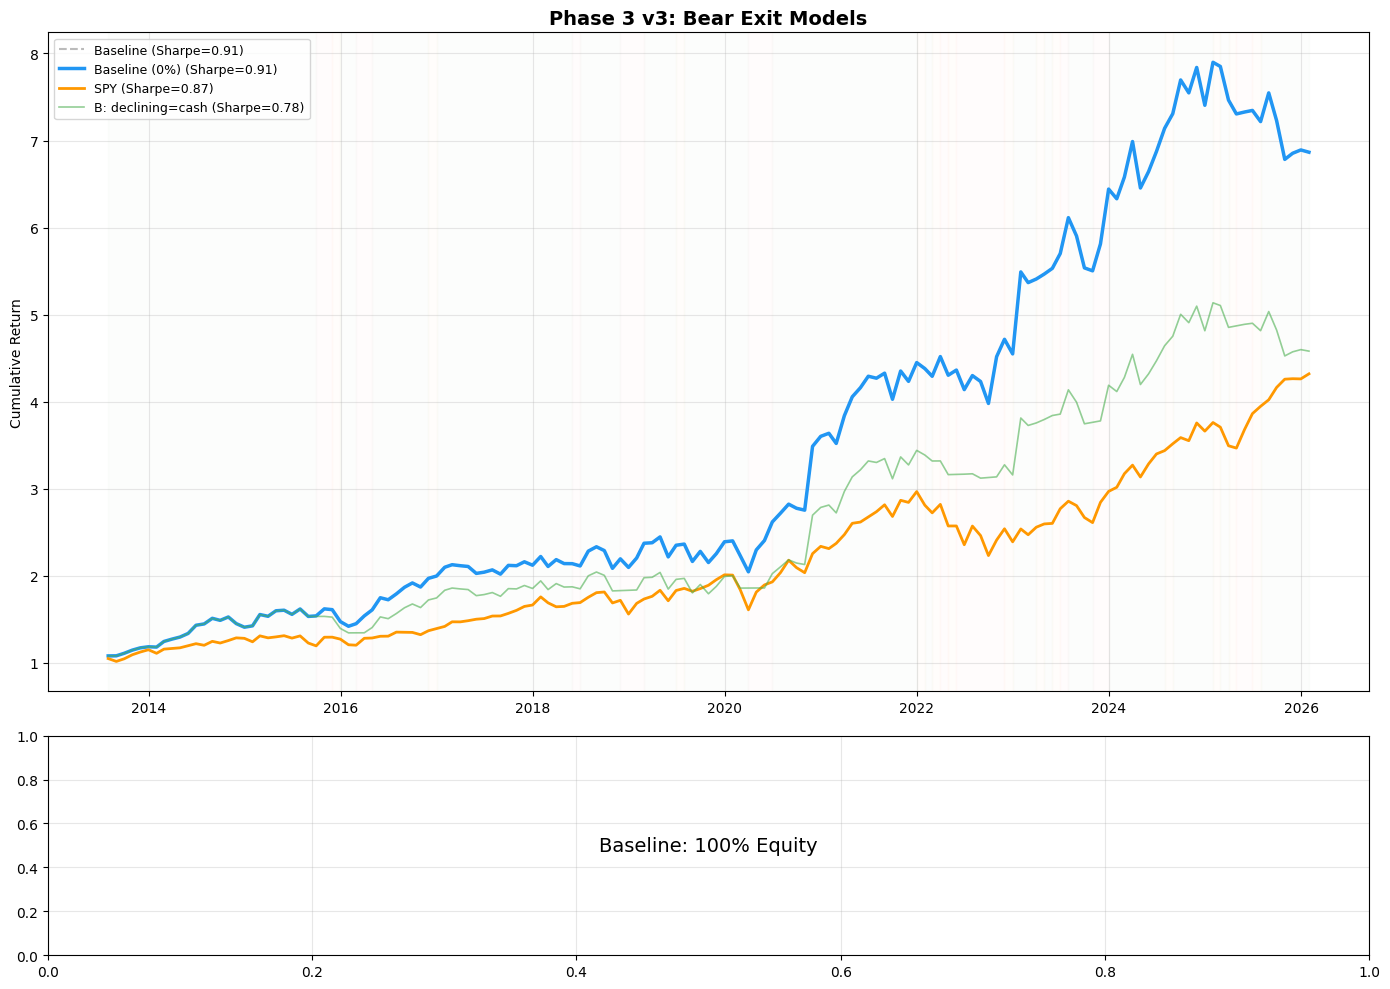


Phase 3 v3 결론
  → 자산배분 효과 없음. Baseline(현금 0%) 유지.

→ Cell 6에서 최종 모델 확정


In [10]:
# =============================================================================
# 🔨 06_TheForge.ipynb — Cell 6: Bear 자산배분 — 즉시 탈출 모델
# =============================================================================
#
# [이전 시도]
# v1: 점진적 현금 확대 (0% 현금) → Sharpe 악화
# v2: v1 + FEDFUNDS → 미미한 개선
# wsubr: confidence 기반 → 효과 없음
#
# [이번 시도]
# Model A: Bear 진입 즉시 현금 → n개월 후 복귀
# Model B: Bear 진입 즉시 현금 → bear_phase=recovering에서 복귀
#
# [현금 수익률: FEDFUNDS]
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

SAVE_DIR = Path(r"C:\QP2\data\interim")

# ─── FEDFUNDS 로드 ────────────────────────────────────────────────────────────

macro = pd.read_parquet(SAVE_DIR / "macro_indicators.parquet")
macro.index = pd.to_datetime(macro.index)
fedfunds_m = macro["FEDFUNDS"].resample("ME").last() / 100 / 12
fedfunds_m = fedfunds_m.dropna()

# ─── SPY 로드 ─────────────────────────────────────────────────────────────────

spy_raw = pd.read_parquet(SAVE_DIR / "gspc_daily.parquet")
if "date" in spy_raw.columns:
    spy_raw = spy_raw.set_index("date")
spy_raw.index = pd.to_datetime(spy_raw.index)
spy_m = spy_raw["spy_close"].resample("ME").last()
spy_ret = spy_m.pct_change().dropna()

# ─── Baseline (현금 0%) 확인 ──────────────────────────────────────────────────

# bt_optimal이 Cell 5.5 결과 (2차 최적 가중치)로 메모리에 있어야 함
baseline_perf = calc_perf(bt_optimal["cum_port"])
print(f"Baseline: Sharpe={baseline_perf['Sharpe']:.2f}, CAGR={baseline_perf['CAGR']:.1%}, "
      f"MaxDD={baseline_perf['MaxDD']:.1%}")

# =============================================================================
# Model A: Bear 진입 즉시 현금 → n개월 후 복귀
# =============================================================================

def apply_model_a(bt_df, cash_months, fedfunds):
    """
    Bear 진입 후 cash_months개월 동안 현금 100%.
    cash_months 후 주식 100% 복귀.
    """
    df = bt_df.copy()
    bear_counter = 0
    prev_regime = None
    eq_weights = []
    cash_rets = []
    
    for idx in df.index:
        regime = df.loc[idx, "regime"]
        cash_r = fedfunds.get(idx, 0.0)
        if pd.isna(cash_r):
            prior = fedfunds[fedfunds.index <= idx]
            cash_r = prior.iloc[-1] if len(prior) > 0 else 0.0
        cash_rets.append(cash_r)
        
        if regime == "Bear":
            if prev_regime != "Bear":
                bear_counter = 1  # Bear 첫 달
            else:
                bear_counter += 1
            
            if bear_counter <= cash_months:
                eq_w = 0.0  # 현금 100%
            else:
                eq_w = 1.0  # 주식 복귀
        else:
            eq_w = 1.0
            bear_counter = 0
        
        eq_weights.append(eq_w)
        prev_regime = regime
    
    df["eq_weight"] = eq_weights
    df["cash_ret"] = cash_rets
    df["alloc_ret"] = df["eq_weight"] * df["port_ret_net"] + (1 - df["eq_weight"]) * df["cash_ret"]
    df["cum_alloc"] = (1 + df["alloc_ret"]).cumprod()
    return df


# =============================================================================
# Model B: Bear 진입 즉시 현금 → recovering에서 복귀
# =============================================================================

def apply_model_b(bt_df, fedfunds):
    """
    Bear declining = 현금 100%.
    Bear recovering = 주식 100% 복귀.
    """
    df = bt_df.copy()
    eq_weights = []
    cash_rets = []
    
    for idx in df.index:
        regime = df.loc[idx, "regime"]
        bear_phase = df.loc[idx, "bear_phase"]
        cash_r = fedfunds.get(idx, 0.0)
        if pd.isna(cash_r):
            prior = fedfunds[fedfunds.index <= idx]
            cash_r = prior.iloc[-1] if len(prior) > 0 else 0.0
        cash_rets.append(cash_r)
        
        if regime == "Bear" and bear_phase == "declining":
            eq_w = 0.0  # 현금 100%
        else:
            eq_w = 1.0  # 주식 (Bull, Neutral, Bear recovering 포함)
        
        eq_weights.append(eq_w)
    
    df["eq_weight"] = eq_weights
    df["cash_ret"] = cash_rets
    df["alloc_ret"] = df["eq_weight"] * df["port_ret_net"] + (1 - df["eq_weight"]) * df["cash_ret"]
    df["cum_alloc"] = (1 + df["alloc_ret"]).cumprod()
    return df


# =============================================================================
# Model B-2: Bear declining = 현금, recovering = 점진 복귀
# =============================================================================

def apply_model_b2(bt_df, fedfunds, recovery_eq=0.5):
    """
    Bear declining = 현금 100%.
    Bear recovering = recovery_eq (50% 등) 주식.
    Bull/Neutral = 주식 100%.
    """
    df = bt_df.copy()
    eq_weights = []
    cash_rets = []
    
    for idx in df.index:
        regime = df.loc[idx, "regime"]
        bear_phase = df.loc[idx, "bear_phase"]
        cash_r = fedfunds.get(idx, 0.0)
        if pd.isna(cash_r):
            prior = fedfunds[fedfunds.index <= idx]
            cash_r = prior.iloc[-1] if len(prior) > 0 else 0.0
        cash_rets.append(cash_r)
        
        if regime == "Bear" and bear_phase == "declining":
            eq_w = 0.0
        elif regime == "Bear" and bear_phase == "recovering":
            eq_w = recovery_eq
        else:
            eq_w = 1.0
        
        eq_weights.append(eq_w)
    
    df["eq_weight"] = eq_weights
    df["cash_ret"] = cash_rets
    df["alloc_ret"] = df["eq_weight"] * df["port_ret_net"] + (1 - df["eq_weight"]) * df["cash_ret"]
    df["cum_alloc"] = (1 + df["alloc_ret"]).cumprod()
    return df


# =============================================================================
# 전체 테스트
# =============================================================================

print("\n" + "=" * 70)
print("🔨 Phase 3 v3: Bear 즉시 탈출 모델")
print("=" * 70)

results = {}

# Baseline
results["Baseline (0%)"] = {
    "bt": bt_optimal, "cum_col": "cum_port", "ret_col": "port_ret_net"
}

# Model A: n = 1, 2, 3
for n in [1, 2, 3]:
    bt_a = apply_model_a(bt_optimal, n, fedfunds_m)
    results[f"A: {n}M cash"] = {
        "bt": bt_a, "cum_col": "cum_alloc", "ret_col": "alloc_ret"
    }

# Model B: declining = cash
bt_b = apply_model_b(bt_optimal, fedfunds_m)
results["B: declining=cash"] = {
    "bt": bt_b, "cum_col": "cum_alloc", "ret_col": "alloc_ret"
}

# Model B-2: declining=cash, recovering=50%
for rec_eq in [0.3, 0.5, 0.7]:
    bt_b2 = apply_model_b2(bt_optimal, fedfunds_m, recovery_eq=rec_eq)
    results[f"B2: rec={rec_eq:.0%}"] = {
        "bt": bt_b2, "cum_col": "cum_alloc", "ret_col": "alloc_ret"
    }

# =============================================================================
# 결과 비교
# =============================================================================

print(f"\n{'='*70}")
print(f"Bear 자산배분 모델 비교")
print(f"{'='*70}")
print(f"  {'Model':22s} {'CAGR':>8s} {'Sharpe':>8s} {'MaxDD':>8s} {'Bear Cash':>10s}")
print(f"  {'-'*60}")

best_sharpe = 0
best_name = ""

for name, info in results.items():
    bt = info["bt"]
    cum_col = info["cum_col"]
    ret_col = info["ret_col"]
    
    perf = calc_perf(bt[cum_col])
    
    # Bear 구간 현금 비중
    if "eq_weight" in bt.columns:
        bear_sub = bt[bt["regime"] == "Bear"]
        avg_cash = (1 - bear_sub["eq_weight"]).mean() * 100
    else:
        avg_cash = 0
    
    flag = ""
    if perf["Sharpe"] > best_sharpe:
        best_sharpe = perf["Sharpe"]
        best_name = name
        flag = " ★"
    
    print(f"  {name:22s} {perf['CAGR']:>7.1%} {perf['Sharpe']:>8.2f} "
          f"{perf['MaxDD']:>7.1%} {avg_cash:>9.0f}%{flag}")

print(f"\n  → 최적: {best_name} (Sharpe={best_sharpe:.2f})")

# SPY 비교
best_info = results[best_name]
best_bt = best_info["bt"]
best_ret_col = best_info["ret_col"]
best_cum_col = best_info["cum_col"]
best_perf = calc_perf(best_bt[best_cum_col])

common_idx = best_bt.index.intersection(spy_ret.index)
excess_spy = best_bt.loc[common_idx, best_ret_col] - spy_ret.loc[common_idx]
t_spy = excess_spy.mean() / (excess_spy.std() / np.sqrt(len(excess_spy))) if excess_spy.std() > 0 else 0

print(f"\n  {best_name} vs SPY: Excess={excess_spy.mean()*12:+.1%}  t={t_spy:.2f}")
print(f"  {best_name} vs Baseline: Sharpe {best_sharpe:.2f} vs {baseline_perf['Sharpe']:.2f} "
      f"({best_sharpe - baseline_perf['Sharpe']:+.2f})")

# =============================================================================
# Bear 구간 상세 비교
# =============================================================================

print(f"\n{'='*70}")
print(f"Bear 구간 상세")
print(f"{'='*70}")

# Bear declining / recovering 분해
bear_data = bt_optimal[bt_optimal["regime"] == "Bear"]
declining = bear_data[bear_data["bear_phase"] == "declining"]
recovering = bear_data[bear_data["bear_phase"] == "recovering"]

print(f"  Bear 전체: {len(bear_data)}M")
print(f"    declining:  {len(declining)}M  avg_ret={declining['port_ret_net'].mean()*100:+.1f}%/M")
print(f"    recovering: {len(recovering)}M  avg_ret={recovering['port_ret_net'].mean()*100:+.1f}%/M")

# =============================================================================
# 차트
# =============================================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [3, 1]})

# 상단: 누적 수익률
ax1 = axes[0]

# Baseline
ax1.plot(bt_optimal.index, bt_optimal["cum_port"],
         label=f"Baseline (Sharpe={baseline_perf['Sharpe']:.2f})",
         linewidth=1.5, color="#9E9E9E", linestyle="--", alpha=0.7)

# 최적 모델
ax1.plot(best_bt.index, best_bt[best_cum_col],
         label=f"{best_name} (Sharpe={best_perf['Sharpe']:.2f})",
         linewidth=2.5, color="#2196F3")

# SPY
common_spy = bt_optimal.index.intersection(spy_ret.index)
cum_spy_plot = (1 + spy_ret.loc[common_spy]).cumprod()
spy_p = calc_perf(cum_spy_plot)
ax1.plot(cum_spy_plot.index, cum_spy_plot,
         label=f"SPY (Sharpe={spy_p['Sharpe']:.2f})",
         linewidth=2, color="#FF9800")

# Model B (declining=cash) 별도 표시
if best_name != "B: declining=cash":
    bt_b_plot = results["B: declining=cash"]["bt"]
    b_perf = calc_perf(bt_b_plot["cum_alloc"])
    ax1.plot(bt_b_plot.index, bt_b_plot["cum_alloc"],
             label=f"B: declining=cash (Sharpe={b_perf['Sharpe']:.2f})",
             linewidth=1.2, color="#4CAF50", alpha=0.6)

# 레짐 배경
regime_colors = {"Bull": "#E8F5E9", "Bear": "#FFEBEE", "Neutral": "#FFF3E0"}
prev_regime = None
prev_date = bt_optimal.index[0]
for dt_idx in bt_optimal.index:
    r = bt_optimal.loc[dt_idx, "regime"]
    if r != prev_regime and prev_regime is not None:
        ax1.axvspan(prev_date, dt_idx, alpha=0.12, color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)
        prev_date = dt_idx
    prev_regime = r
ax1.axvspan(prev_date, bt_optimal.index[-1], alpha=0.12, color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)

ax1.set_title("Phase 3 v3: Bear Exit Models", fontsize=14, fontweight="bold")
ax1.legend(loc="upper left", fontsize=9)
ax1.set_ylabel("Cumulative Return")
ax1.grid(True, alpha=0.3)

# 하단: equity weight (최적 모델)
ax2 = axes[1]
if "eq_weight" in best_bt.columns:
    ax2.fill_between(best_bt.index, best_bt["eq_weight"] * 100, 100,
                     alpha=0.3, color="#F44336", label="Cash %")
    ax2.plot(best_bt.index, best_bt["eq_weight"] * 100,
             color="#2196F3", linewidth=1.5, label="Equity %")
    ax2.set_ylabel(f"Equity % ({best_name})")
    ax2.set_ylim(-5, 105)
    ax2.legend(loc="lower left", fontsize=9)
else:
    ax2.text(0.5, 0.5, "Baseline: 100% Equity", transform=ax2.transAxes,
             ha="center", va="center", fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(SAVE_DIR / "06_theforge_phase3_v3.png"), dpi=150, bbox_inches="tight")
plt.show()

# =============================================================================
# 결론
# =============================================================================

print(f"\n{'='*70}")
print(f"Phase 3 v3 결론")
print(f"{'='*70}")

if best_sharpe > baseline_perf["Sharpe"] + 0.02:
    print(f"  → {best_name}이 Baseline 대비 Sharpe +{best_sharpe - baseline_perf['Sharpe']:.2f} 개선!")
    print(f"  → Cell 6에서 이 모델을 최종 모델에 적용.")
elif best_sharpe > baseline_perf["Sharpe"]:
    print(f"  → 미미한 개선 (+{best_sharpe - baseline_perf['Sharpe']:.2f}). 추가 검증 필요.")
else:
    print(f"  → 자산배분 효과 없음. Baseline(현금 0%) 유지.")

print(f"\n→ Cell 6에서 최종 모델 확정")

🔨 Cell 6: 최종 모델 확정 — Taehong Style

확정 가중치:
  Bull      : h_z=0.0, g1_bull_z=1.8, nsi_score=0.3
  Bear      : h_z=0.7, a3_z=1.0, p5_z=0.7, e5_z=2.0, d1_z=0.7
  Neutral   : h_z=0.5, d3_z=1.1

자산배분: 없음 (현금 0%)
Sub-Regime: 미사용 (효과 없음)

종합 성과 — Taehong Style Final
                             CAGR   Sharpe    MaxDD   t-stat
  ----------------------------------------------------------
  SPY (S&P500)             11.9%     0.87  -24.8%
  EW Benchmark             14.4%     0.99  -24.1%
  Taehong Style            16.9%     0.96  -16.9%     0.85

  vs SPY: Excess=+5.2% (ann.)  t=1.47
  vs EW:  Excess=+2.8% (ann.)  t=0.85

  레짐별:
    Bull    : 115M  Sharpe=0.82/1.08  CAGR=+14.4%/+12.3%  LOSE
    Bear    :  23M  Sharpe=1.38/0.87  CAGR=+25.9%/+20.5%  WIN
    Neutral :  13M  Sharpe=1.77/1.62  CAGR=+23.9%/+24.9%  WIN

연도별 성과
    Year     Port   BM(EW)      SPY   Excess               Regime
  ------------------------------------------------------------
    2013  +17.6%  +17.1%  +15.1%   +2.5%         

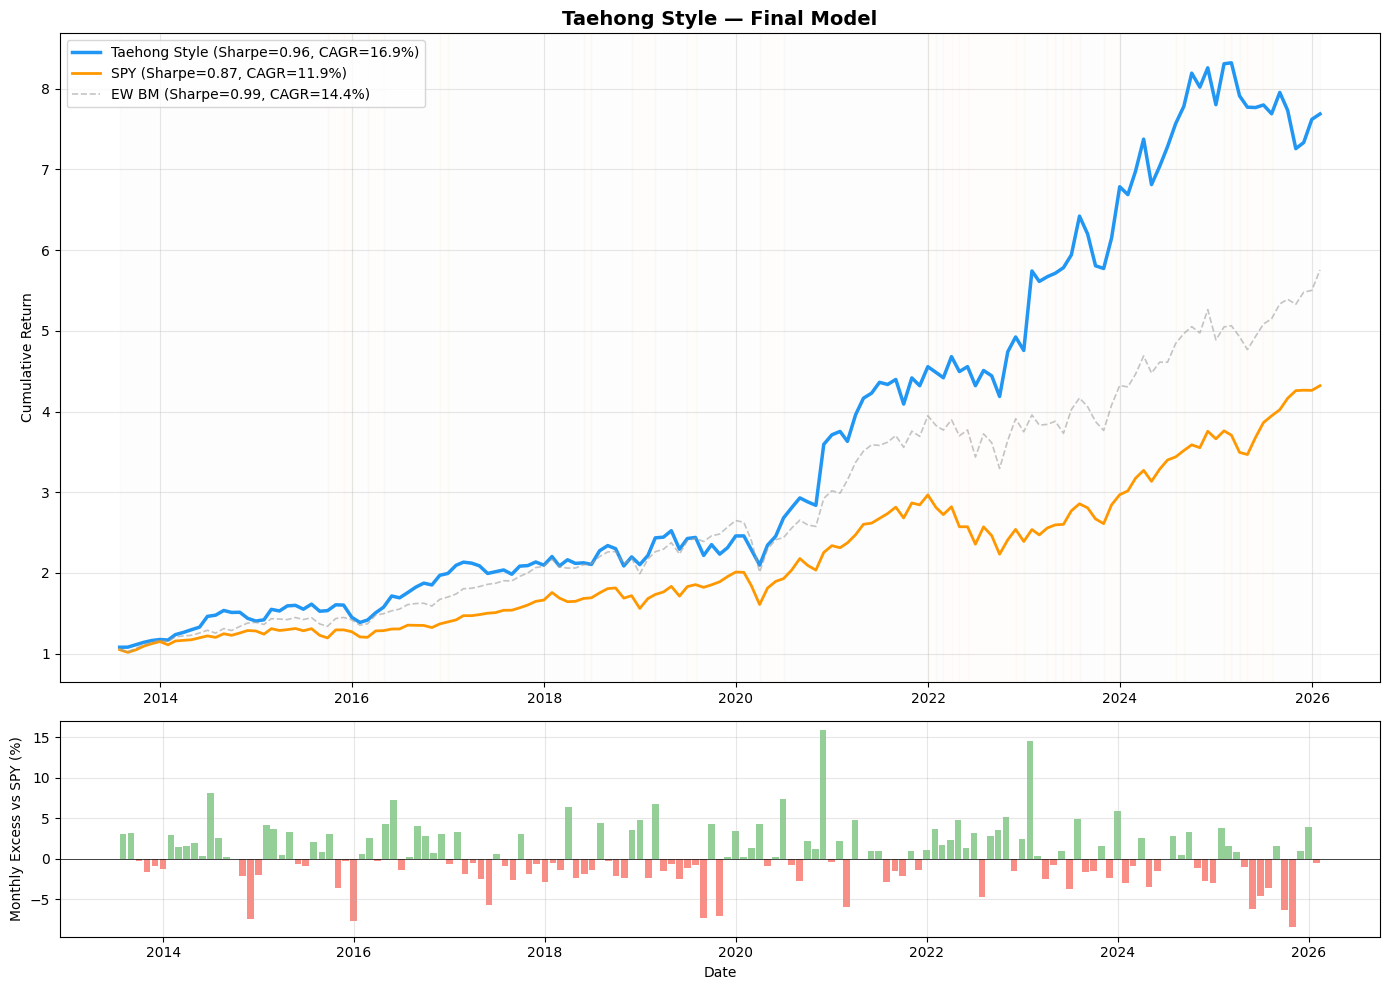

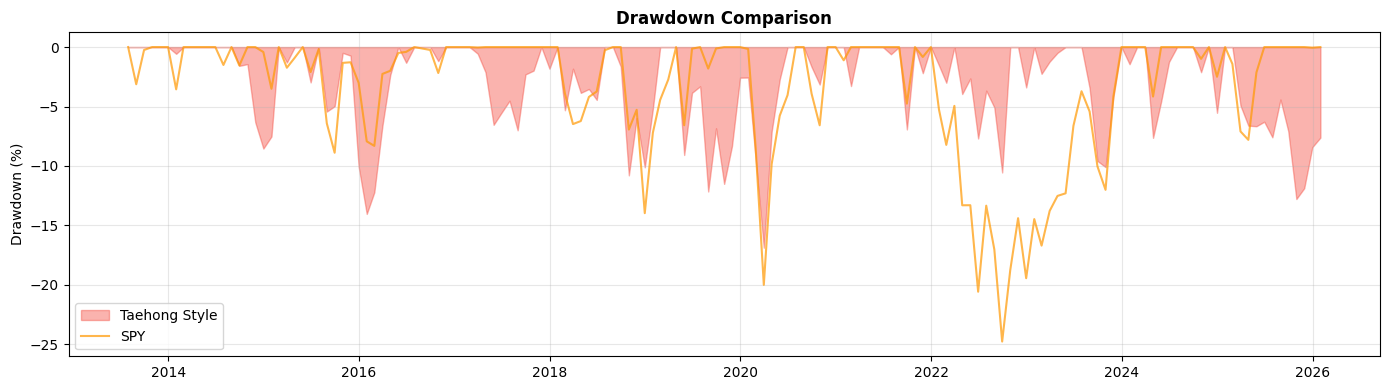


Cell 6 — 최종 모델 확정 완료
  모델명:    Taehong Style
  CAGR:      16.9%
  Sharpe:    0.96
  MaxDD:     -16.9%
  vs SPY:    +5.2% (t=1.47)
  턴오버:    72%

  ⚠ Walk-Forward 검증 미완료!
  → Cell 7에서 2013~2020 학습 / 2021~2026 테스트 구조 진행
  → Neutral(13M, SENSITIVE) 과적합 여부 특히 주의

  ✅ bt_final 저장: C:\QP2\data\interim\06_theforge_bt_final.parquet


In [11]:
# =============================================================================
# 🔨 06_TheForge.ipynb — Cell 7: 최종 모델 확정 + Walk-Forward 준비
# =============================================================================
#
# [경위]
# Phase 2    (동일가중):       Sharpe=0.79 → BM 열위
# Phase 2.5  (가중치 최적화):  Sharpe=0.96 → SPY 돌파!
# Phase 3    (Bear 자산배분):  역효과 → 폐기
# Sub-Regime (confidence):    효과 없음 → 폐기
#
# [최종 모델] = 2차 세분화 가중치 + 자산배분 없음(현금 0%)
#
# [이 셀에서 하는 것]
# 1. 최종 가중치 확정 + 전체 백테스트 재실행
# 2. SPY 비교 포함 종합 성과 테이블
# 3. 연도별 성과 분해
# 4. 월별 히트맵
# 5. Walk-Forward 구조 준비
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

SAVE_DIR = Path(r"C:\QP2\data\interim")

# =============================================================================
# [1] 최종 가중치 확정
# =============================================================================

FINAL_WEIGHTS = {
    "Bull":    {"h_z": 0.0, "g1_bull_z": 1.8, "nsi_score": 0.3},
    "Bear":    {"h_z": 0.7, "a3_z": 1.0, "p5_z": 0.7, "e5_z": 2.0, "d1_z": 0.7},
    "Neutral": {"h_z": 0.5, "d3_z": 1.1},
}

print("=" * 70)
print("🔨 Cell 6: 최종 모델 확정 — Taehong Style")
print("=" * 70)
print("\n확정 가중치:")
for regime, w in FINAL_WEIGHTS.items():
    w_str = ", ".join([f"{f}={v:.1f}" for f, v in w.items()])
    print(f"  {regime:10s}: {w_str}")
print(f"\n자산배분: 없음 (현금 0%)")
print(f"Sub-Regime: 미사용 (효과 없음)")

# =============================================================================
# [2] 최종 백테스트
# =============================================================================

bt_final = backtest_weighted(
    panel, ret_1m, regime_map, FINAL_WEIGHTS,
    t1_events, ticker_to_sector,
    top_n=TOP_N, cost_bp=COST_BP,
)

final_perf = calc_perf(bt_final["cum_port"])
final_bm = calc_perf(bt_final["cum_bm"])
final_t = calc_tstat(bt_final["excess_net"])

# SPY 로드
spy_raw = pd.read_parquet(SAVE_DIR / "gspc_daily.parquet")
if "date" in spy_raw.columns:
    spy_raw = spy_raw.set_index("date")
spy_raw.index = pd.to_datetime(spy_raw.index)
spy_m = spy_raw["spy_close"].resample("ME").last()
spy_ret = spy_m.pct_change().dropna()

common_idx = bt_final.index.intersection(spy_ret.index)
cum_spy = (1 + spy_ret.loc[common_idx]).cumprod()
spy_perf = calc_perf(cum_spy)

# vs SPY
excess_spy = bt_final.loc[common_idx, "port_ret_net"] - spy_ret.loc[common_idx]
t_spy = excess_spy.mean() / (excess_spy.std() / np.sqrt(len(excess_spy))) if excess_spy.std() > 0 else 0

# =============================================================================
# [3] 종합 성과 테이블
# =============================================================================

print(f"\n{'='*70}")
print(f"종합 성과 — Taehong Style Final")
print(f"{'='*70}")
print(f"  {'':22s} {'CAGR':>8s} {'Sharpe':>8s} {'MaxDD':>8s} {'t-stat':>8s}")
print(f"  {'-'*58}")
print(f"  {'SPY (S&P500)':22s} {spy_perf['CAGR']:>7.1%} {spy_perf['Sharpe']:>8.2f} {spy_perf['MaxDD']:>7.1%}")
print(f"  {'EW Benchmark':22s} {final_bm['CAGR']:>7.1%} {final_bm['Sharpe']:>8.2f} {final_bm['MaxDD']:>7.1%}")
print(f"  {'Taehong Style':22s} {final_perf['CAGR']:>7.1%} {final_perf['Sharpe']:>8.2f} "
      f"{final_perf['MaxDD']:>7.1%} {final_t:>8.2f}")
print(f"\n  vs SPY: Excess={excess_spy.mean()*12:+.1%} (ann.)  t={t_spy:.2f}")
print(f"  vs EW:  Excess={bt_final['excess_net'].mean()*12:+.1%} (ann.)  t={final_t:.2f}")

# 레짐별
print(f"\n  레짐별:")
for regime in ["Bull", "Bear", "Neutral"]:
    sub = bt_final[bt_final["regime"] == regime]
    if len(sub) < 2:
        continue
    cum = (1 + sub["port_ret_net"]).cumprod()
    cum_bm = (1 + sub["bm_ret"]).cumprod()
    rp = calc_perf(cum)
    rb = calc_perf(cum_bm)
    flag = "WIN" if rp["Sharpe"] > rb["Sharpe"] else "LOSE"
    print(f"    {regime:8s}: {len(sub):3d}M  Sharpe={rp['Sharpe']:.2f}/{rb['Sharpe']:.2f}  "
          f"CAGR={rp['CAGR']:+.1%}/{rb['CAGR']:+.1%}  {flag}")

# =============================================================================
# [4] 연도별 성과 분해
# =============================================================================

print(f"\n{'='*70}")
print(f"연도별 성과")
print(f"{'='*70}")
print(f"  {'Year':>6s} {'Port':>8s} {'BM(EW)':>8s} {'SPY':>8s} {'Excess':>8s} {'Regime':>20s}")
print(f"  {'-'*60}")

bt_final["year"] = bt_final.index.year
spy_ret_df = spy_ret.loc[common_idx].to_frame("spy_ret")

for year in sorted(bt_final["year"].unique()):
    sub = bt_final[bt_final["year"] == year]
    port_ann = (1 + sub["port_ret_net"]).prod() - 1
    bm_ann = (1 + sub["bm_ret"]).prod() - 1
    
    spy_sub = spy_ret_df[spy_ret_df.index.year == year]
    spy_ann = (1 + spy_sub["spy_ret"]).prod() - 1 if len(spy_sub) > 0 else np.nan
    
    excess = port_ann - (spy_ann if not np.isnan(spy_ann) else bm_ann)
    
    # 해당 연도 레짐 분포
    regime_counts = sub["regime"].value_counts()
    regime_str = ", ".join([f"{r[0]}:{c}" for r, c in regime_counts.items()])
    
    flag = "✅" if port_ann > spy_ann else "❌" if not np.isnan(spy_ann) else ""
    print(f"  {year:>6d} {port_ann:>+7.1%} {bm_ann:>+7.1%} {spy_ann:>+7.1%} "
          f"{excess:>+7.1%} {regime_str:>20s} {flag}")

# 승률
years_data = []
for year in sorted(bt_final["year"].unique()):
    sub = bt_final[bt_final["year"] == year]
    port_ann = (1 + sub["port_ret_net"]).prod() - 1
    spy_sub = spy_ret_df[spy_ret_df.index.year == year]
    spy_ann = (1 + spy_sub["spy_ret"]).prod() - 1 if len(spy_sub) > 0 else np.nan
    if not np.isnan(spy_ann):
        years_data.append({"year": year, "win": port_ann > spy_ann})

win_rate = sum(1 for y in years_data if y["win"]) / len(years_data) if years_data else 0
print(f"\n  vs SPY 연도별 승률: {win_rate:.0%} ({sum(1 for y in years_data if y['win'])}/{len(years_data)})")

# =============================================================================
# [5] 최종 차트
# =============================================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [3, 1]})

# 상단: 누적 수익률
ax1 = axes[0]
ax1.plot(bt_final.index, bt_final["cum_port"],
         label=f"Taehong Style (Sharpe={final_perf['Sharpe']:.2f}, CAGR={final_perf['CAGR']:.1%})",
         linewidth=2.5, color="#2196F3")
ax1.plot(cum_spy.index, cum_spy,
         label=f"SPY (Sharpe={spy_perf['Sharpe']:.2f}, CAGR={spy_perf['CAGR']:.1%})",
         linewidth=2, color="#FF9800")
ax1.plot(bt_final.index, bt_final["cum_bm"],
         label=f"EW BM (Sharpe={final_bm['Sharpe']:.2f}, CAGR={final_bm['CAGR']:.1%})",
         linewidth=1.2, color="#9E9E9E", linestyle="--", alpha=0.6)

# 레짐 배경
regime_colors = {"Bull": "#E8F5E9", "Bear": "#FFEBEE", "Neutral": "#FFF3E0"}
prev_regime = None
prev_date = bt_final.index[0]
for dt_idx in bt_final.index:
    r = bt_final.loc[dt_idx, "regime"]
    if r != prev_regime and prev_regime is not None:
        ax1.axvspan(prev_date, dt_idx, alpha=0.12, color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)
        prev_date = dt_idx
    prev_regime = r
ax1.axvspan(prev_date, bt_final.index[-1], alpha=0.12, color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)

ax1.set_title("Taehong Style — Final Model", fontsize=14, fontweight="bold")
ax1.legend(loc="upper left", fontsize=10)
ax1.set_ylabel("Cumulative Return")
ax1.grid(True, alpha=0.3)

# 하단: 월간 초과수익 (vs SPY)
ax2 = axes[1]
excess_monthly = bt_final.loc[common_idx, "port_ret_net"] - spy_ret.loc[common_idx]
colors = ["#4CAF50" if x > 0 else "#F44336" for x in excess_monthly]
ax2.bar(excess_monthly.index, excess_monthly * 100, color=colors, alpha=0.6, width=25)
ax2.axhline(0, color="black", linewidth=0.5)
ax2.set_ylabel("Monthly Excess vs SPY (%)")
ax2.set_xlabel("Date")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(SAVE_DIR / "06_theforge_final.png"), dpi=150, bbox_inches="tight")
plt.show()

# =============================================================================
# [6] Drawdown 차트
# =============================================================================

fig, ax = plt.subplots(figsize=(14, 4))

# Portfolio drawdown
cum = bt_final["cum_port"]
running_max = cum.cummax()
dd = (cum - running_max) / running_max
ax.fill_between(dd.index, dd * 100, 0, alpha=0.4, color="#F44336", label="Taehong Style")

# SPY drawdown
spy_cum = cum_spy
spy_max = spy_cum.cummax()
spy_dd = (spy_cum - spy_max) / spy_max
ax.plot(spy_dd.index, spy_dd * 100, color="#FF9800", linewidth=1.5, label="SPY", alpha=0.7)

ax.set_title("Drawdown Comparison", fontsize=12, fontweight="bold")
ax.set_ylabel("Drawdown (%)")
ax.legend(loc="lower left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(SAVE_DIR / "06_theforge_drawdown.png"), dpi=150, bbox_inches="tight")
plt.show()

# =============================================================================
# [7] 결론 + Walk-Forward 준비
# =============================================================================

print(f"\n{'='*70}")
print(f"Cell 6 — 최종 모델 확정 완료")
print(f"{'='*70}")
print(f"  모델명:    Taehong Style")
print(f"  CAGR:      {final_perf['CAGR']:.1%}")
print(f"  Sharpe:    {final_perf['Sharpe']:.2f}")
print(f"  MaxDD:     {final_perf['MaxDD']:.1%}")
print(f"  vs SPY:    {excess_spy.mean()*12:+.1%} (t={t_spy:.2f})")
print(f"  턴오버:    {bt_final['turnover'].mean():.0%}")

print(f"\n  ⚠ Walk-Forward 검증 미완료!")
print(f"  → Cell 7에서 2013~2020 학습 / 2021~2026 테스트 구조 진행")
print(f"  → Neutral(13M, SENSITIVE) 과적합 여부 특히 주의")

# bt_final 저장 (Cell 7에서 사용)
bt_final.to_parquet(SAVE_DIR / "06_theforge_bt_final.parquet")
print(f"\n  ✅ bt_final 저장: {SAVE_DIR / '06_theforge_bt_final.parquet'}")

🔨 Cell 7: Walk-Forward 검증

[Split 1]
  Train: 2013-06 ~ 2019-12
  Test:  2020-01 ~ 2022-12
  IS: 79 months, 39737 rows
  OOS: 36 months, 18108 rows
  IS 최적화 중...


  Neutral IS: 100%|██████████| 24/24 [00:00<00:00, 45.57it/s]


    IS Bull    : h=0.0, g1=0.0, nsi=0.5
    IS Bear    : h=0.0, a3=0.5, p5=2.0, e5=1.0, d1=1.0
    IS Neutral : h=2.0, d3=0.5

                         Sharpe     CAGR    MaxDD
  ------------------------------------------------
  IS (Train)               1.09   12.5%   -9.2%
  OOS (IS weights)         0.84   14.4%  -12.3%
  OOS (FullSample)         1.22   28.6%  -10.5%
  OOS (EqualWeight)        1.06   19.8%  -11.6%
  OOS BM (EW)              0.83   16.6%  -16.5%

  IS→OOS 열화: +0.24
  판정: ✅ OK

[Split 2]
  Train: 2013-06 ~ 2020-12
  Test:  2021-01 ~ 2023-12
  IS: 91 months, 45773 rows
  OOS: 36 months, 18108 rows
  IS 최적화 중...


  Neutral IS: 100%|██████████| 24/24 [00:00<00:00, 44.28it/s]


    IS Bull    : h=0.0, g1=2.0, nsi=0.5
    IS Bear    : h=0.0, a3=0.0, p5=2.0, e5=0.5, d1=0.0
    IS Neutral : h=2.0, d3=0.5

                         Sharpe     CAGR    MaxDD
  ------------------------------------------------
  IS (Train)               1.02   17.7%  -15.9%
  OOS (IS weights)         0.85   15.7%  -13.5%
  OOS (FullSample)         1.17   23.9%  -10.5%
  OOS (EqualWeight)        0.92   15.6%  -11.6%
  OOS BM (EW)              0.71   11.4%  -16.5%

  IS→OOS 열화: +0.17
  판정: ✅ OK

[Split 3]
  Train: 2013-06 ~ 2021-12
  Test:  2022-01 ~ 2026-01
  IS: 103 months, 51809 rows
  OOS: 49 months, 24647 rows
  IS 최적화 중...


...

    IS Bull    : h=0.0, g1=0.5, nsi=1.0
    IS Bear    : h=0.0, a3=0.0, p5=2.0, e5=0.5, d1=0.0
    IS Neutral : h=2.0, d3=0.5

                         Sharpe     CAGR    MaxDD
  ------------------------------------------------
  IS (Train)               1.09   17.1%  -16.2%
  OOS (IS weights)         0.20    2.0%  -16.2%
  OOS (FullSample)         0.85   14.8%  -12.8%
  OOS (EqualWeight)        0.66   10.4%  -12.3%
  OOS BM (EW)              0.76   11.1%  -15.5%

  IS→OOS 열화: +0.89
  판정: ⚠ OVERFIT

[Split 4]
  Train: 2016-01 ~ 2022-12
  Test:  2023-01 ~ 2026-01
  IS: 84 months, 42252 rows
  OOS: 37 months, 18611 rows
  IS 최적화 중...


  Neutral IS: 100%|██████████| 24/24 [00:00<00:00, 27.02it/s]


    IS Bull    : h=0.0, g1=2.0, nsi=0.5
    IS Bear    : h=2.0, a3=0.5, p5=0.0, e5=1.5, d1=1.0
    IS Neutral : h=0.5, d3=0.0

                         Sharpe     CAGR    MaxDD
  ------------------------------------------------
  IS (Train)               1.06   21.0%  -20.2%
  OOS (IS weights)         0.35    4.1%  -12.3%
  OOS (FullSample)         0.80   11.1%  -12.8%
  OOS (EqualWeight)        0.64    8.0%  -12.3%
  OOS BM (EW)              1.16   14.5%   -9.6%

  IS→OOS 열화: +0.71
  판정: ⚠ OVERFIT

Walk-Forward 종합 요약
  Split        IS Shp  OOS(IS)  OOS(FS)  OOS(EW)     BM     열화         판정
  ------------------------------------------------------------------------
  Split 1        1.09     0.84     1.22     1.06  0.83 +0.24        ✅ OK
  Split 2        1.02     0.85     1.17     0.92  0.71 +0.17        ✅ OK
  Split 3        1.09     0.20     0.85     0.66  0.76 +0.89   ⚠ OVERFIT
  Split 4        1.06     0.35     0.80     0.64  1.16 +0.71   ⚠ OVERFIT

  평균 IS→OOS 열화: +0.50
  OOS(IS 가중치

  Neutral IS: 100%|██████████| 24/24 [00:00<00:00, 27.09it/s]



  [Bull]
    h           : [0.0, 0.0, 0.0, 0.0]  spread=0.0 ✅
    g1_bull     : [0.0, 2.0, 0.5, 2.0]  spread=2.0 ⚠
    nsi         : [0.5, 0.5, 1.0, 0.5]  spread=0.5 ✅
    Full-Sample: h=0.0, g1=1.8, nsi=0.3

  [Bear]
    h           : [0.0, 0.0, 0.0, 2.0]  spread=2.0 ⚠
    a3          : [0.5, 0.0, 0.0, 0.5]  spread=0.5 ✅
    p5          : [2.0, 2.0, 2.0, 0.0]  spread=2.0 ⚠
    e5          : [1.0, 0.5, 0.5, 1.5]  spread=1.0 ⚠
    d1          : [1.0, 0.0, 0.0, 1.0]  spread=1.0 ⚠
    Full-Sample: h=0.7, a3=1.0, p5=0.7, e5=2.0, d1=0.7

  [Neutral]
    h           : [2.0, 2.0, 2.0, 0.5]  spread=1.5 ⚠
    d3          : [0.5, 0.5, 0.5, 0.0]  spread=0.5 ✅
    Full-Sample: h=0.5, d3=1.1


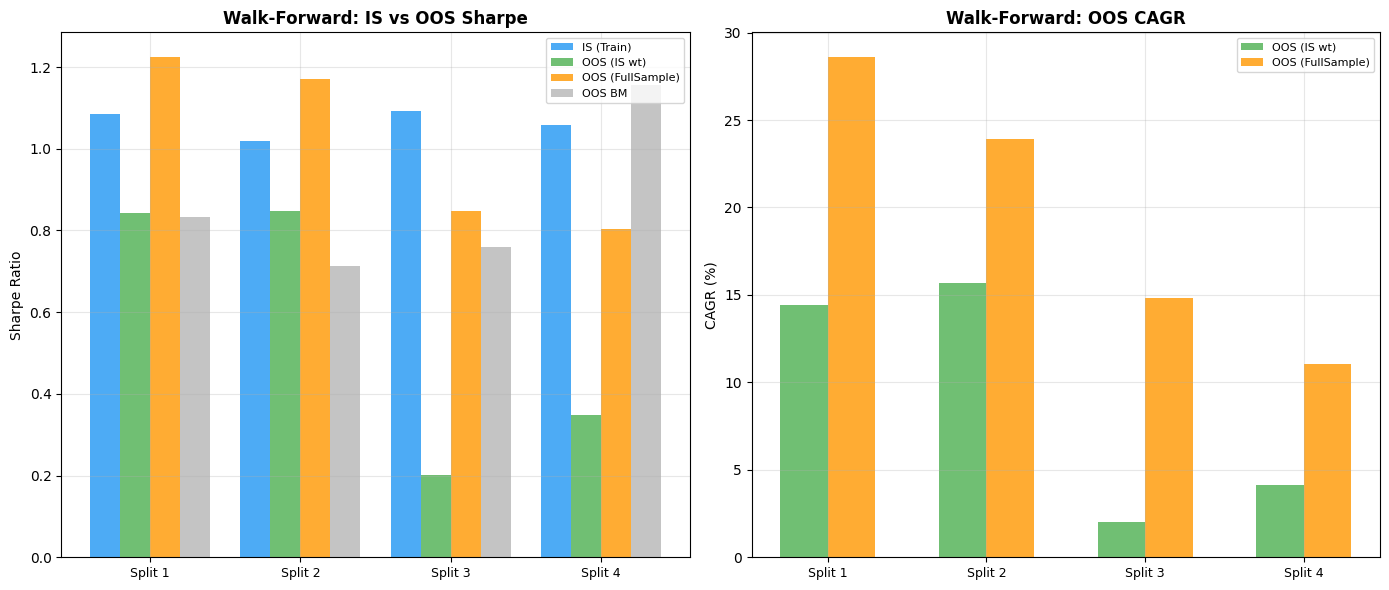


Walk-Forward 최종 판정
  ⚠ 과적합 의심!
  평균 열화 +0.50
  Full-Sample OOS 승률 3/4

  → 동일가중으로 회귀 또는 가중치 대폭 축소 필요.

→ Cell 8에서 최종 리포트 작성


In [ ]:
# =============================================================================
# 🔨 06_TheForge.ipynb — Cell 8: Walk-Forward 검증
# =============================================================================
#
# [목적]
# 2차 최적 가중치가 과적합인지 검증.
# In-Sample(학습)에서 최적화한 가중치를 Out-of-Sample(테스트)에 적용.
#
# [구조]
# Split 1: Train 2013-06 ~ 2019-12 (78M) → Test 2020-01 ~ 2022-12 (36M)
# Split 2: Train 2013-06 ~ 2020-12 (90M) → Test 2021-01 ~ 2023-12 (36M)
# Split 3: Train 2013-06 ~ 2021-12 (102M) → Test 2022-01 ~ 2026-01 (49M)
# Split 4: Train 2016-01 ~ 2022-12 (84M) → Test 2023-01 ~ 2026-01 (37M)
#
# + Full-Sample 가중치를 OOS 기간에 적용한 것과 비교
#
# [핵심 질문]
# IS에서 찾은 가중치가 OOS에서도 먹히나?
# Full-Sample 가중치(우리 최종 모델)가 OOS에서 붕괴하나?
#
# [평가 기준]
# OOS Sharpe > 0 → 방향 유지
# OOS Sharpe > BM Sharpe → 알파 유지
# IS-OOS Sharpe 차이 < 0.3 → 과적합 경미
# =============================================================================

import numpy as np
import pandas as pd
from itertools import product
from tqdm import tqdm
import matplotlib.pyplot as plt
from pathlib import Path

SAVE_DIR = Path(r"C:\QP2\data\interim")

# ─── Walk-Forward Split 정의 ─────────────────────────────────────────────────

WF_SPLITS = {
    "Split 1": {"train": ("2013-06", "2019-12"), "test": ("2020-01", "2022-12")},
    "Split 2": {"train": ("2013-06", "2020-12"), "test": ("2021-01", "2023-12")},
    "Split 3": {"train": ("2013-06", "2021-12"), "test": ("2022-01", "2026-01")},
    "Split 4": {"train": ("2016-01", "2022-12"), "test": ("2023-01", "2026-01")},
}

# Full-Sample 최적 가중치 (Cell 5.5 결과)
FULL_SAMPLE_WEIGHTS = {
    "Bull":    {"h_z": 0.0, "g1_bull_z": 1.8, "nsi_score": 0.3},
    "Bear":    {"h_z": 0.7, "a3_z": 1.0, "p5_z": 0.7, "e5_z": 2.0, "d1_z": 0.7},
    "Neutral": {"h_z": 0.5, "d3_z": 1.1},
}

REGIME_FACTORS = {
    "Bull":    ["h_z", "g1_bull_z", "nsi_score"],
    "Bear":    ["h_z", "a3_z", "p5_z", "e5_z", "d1_z"],
    "Neutral": ["h_z", "d3_z"],
}

WEIGHT_RANGE = [0.0, 0.5, 1.0, 1.5, 2.0]

# ─── 기간 필터 함수 ───────────────────────────────────────────────────────────

def filter_period(panel_df, ret_df, start, end):
    """panel과 ret_1m을 특정 기간으로 필터."""
    p = panel_df[(panel_df["date"] >= pd.Timestamp(start + "-01")) & 
                 (panel_df["date"] <= pd.Timestamp(end + "-28") + pd.offsets.MonthEnd(0))].copy()
    r = ret_df[(ret_df.index >= pd.Timestamp(start + "-01")) & 
               (ret_df.index <= pd.Timestamp(end + "-28") + pd.offsets.MonthEnd(0))].copy()
    return p, r


# ─── IS 그리드 서치 (0.5 단위, 레짐별) ───────────────────────────────────────

def find_optimal_weights_is(panel_df, ret_df, regime_factors, weight_range):
    """In-Sample 기간에서 레짐별 최적 가중치 탐색."""
    optimal = {}
    
    for regime, factors in regime_factors.items():
        combos = list(product(weight_range, repeat=len(factors)))
        combos = [c for c in combos if sum(c) > 0]
        
        best_sharpe = -999
        best_w = None
        
        for combo in tqdm(combos, desc=f"  {regime} IS"):
            w_dict = {f: w for f, w in zip(factors, combo)}
            result = backtest_single_regime(
                panel_df, ret_df, regime, w_dict,
                t1_events_df=t1_events,
                ticker_to_sector_dict=ticker_to_sector,
                top_n=TOP_N, cost_bp=COST_BP,
            )
            if result["sharpe"] > best_sharpe:
                best_sharpe = result["sharpe"]
                best_w = w_dict
        
        optimal[regime] = best_w
    
    return optimal


# ─── 메인 Walk-Forward ───────────────────────────────────────────────────────

print("=" * 70)
print("🔨 Cell 7: Walk-Forward 검증")
print("=" * 70)

wf_results = []

for split_name, periods in WF_SPLITS.items():
    train_start, train_end = periods["train"]
    test_start, test_end = periods["test"]
    
    print(f"\n{'='*60}")
    print(f"[{split_name}]")
    print(f"  Train: {train_start} ~ {train_end}")
    print(f"  Test:  {test_start} ~ {test_end}")
    print(f"{'='*60}")
    
    # IS 데이터
    panel_is, ret_is = filter_period(panel, ret_1m, train_start, train_end)
    print(f"  IS: {len(panel_is['date'].unique())} months, {len(panel_is)} rows")
    
    # OOS 데이터
    panel_oos, ret_oos = filter_period(panel, ret_1m, test_start, test_end)
    print(f"  OOS: {len(panel_oos['date'].unique())} months, {len(panel_oos)} rows")
    
    # ── IS 최적화 (0.5 단위) ──
    print(f"  IS 최적화 중...")
    is_weights = find_optimal_weights_is(panel_is, ret_is, REGIME_FACTORS, WEIGHT_RANGE)
    
    for regime, w in is_weights.items():
        w_str = ", ".join([f"{f.split('_')[0]}={v:.1f}" for f, v in w.items()])
        print(f"    IS {regime:8s}: {w_str}")
    
    # ── IS 성과 ──
    bt_is = backtest_weighted(
        panel_is, ret_is, regime_map, is_weights,
        t1_events, ticker_to_sector, top_n=TOP_N, cost_bp=COST_BP,
    )
    is_perf = calc_perf(bt_is["cum_port"]) if len(bt_is) > 0 else {"Sharpe": 0, "CAGR": 0, "MaxDD": 0}
    is_bm = calc_perf(bt_is["cum_bm"]) if len(bt_is) > 0 else {"Sharpe": 0, "CAGR": 0, "MaxDD": 0}
    
    # ── OOS: IS 가중치 적용 ──
    bt_oos_is = backtest_weighted(
        panel_oos, ret_oos, regime_map, is_weights,
        t1_events, ticker_to_sector, top_n=TOP_N, cost_bp=COST_BP,
    )
    oos_is_perf = calc_perf(bt_oos_is["cum_port"]) if len(bt_oos_is) > 0 else {"Sharpe": 0, "CAGR": 0, "MaxDD": 0}
    oos_is_bm = calc_perf(bt_oos_is["cum_bm"]) if len(bt_oos_is) > 0 else {"Sharpe": 0, "CAGR": 0, "MaxDD": 0}
    
    # ── OOS: Full-Sample 가중치 적용 ──
    bt_oos_fs = backtest_weighted(
        panel_oos, ret_oos, regime_map, FULL_SAMPLE_WEIGHTS,
        t1_events, ticker_to_sector, top_n=TOP_N, cost_bp=COST_BP,
    )
    oos_fs_perf = calc_perf(bt_oos_fs["cum_port"]) if len(bt_oos_fs) > 0 else {"Sharpe": 0, "CAGR": 0, "MaxDD": 0}
    
    # ── OOS: 동일가중 ──
    eq_weights = {r: {f: 1.0 for f in factors} for r, factors in REGIME_FACTORS.items()}
    bt_oos_eq = backtest_weighted(
        panel_oos, ret_oos, regime_map, eq_weights,
        t1_events, ticker_to_sector, top_n=TOP_N, cost_bp=COST_BP,
    )
    oos_eq_perf = calc_perf(bt_oos_eq["cum_port"]) if len(bt_oos_eq) > 0 else {"Sharpe": 0, "CAGR": 0, "MaxDD": 0}
    
    # 출력
    degradation = is_perf["Sharpe"] - oos_is_perf["Sharpe"]
    
    print(f"\n  {'':20s} {'Sharpe':>8s} {'CAGR':>8s} {'MaxDD':>8s}")
    print(f"  {'-'*48}")
    print(f"  {'IS (Train)':20s} {is_perf['Sharpe']:>8.2f} {is_perf['CAGR']:>7.1%} {is_perf['MaxDD']:>7.1%}")
    print(f"  {'OOS (IS weights)':20s} {oos_is_perf['Sharpe']:>8.2f} {oos_is_perf['CAGR']:>7.1%} {oos_is_perf['MaxDD']:>7.1%}")
    print(f"  {'OOS (FullSample)':20s} {oos_fs_perf['Sharpe']:>8.2f} {oos_fs_perf['CAGR']:>7.1%} {oos_fs_perf['MaxDD']:>7.1%}")
    print(f"  {'OOS (EqualWeight)':20s} {oos_eq_perf['Sharpe']:>8.2f} {oos_eq_perf['CAGR']:>7.1%} {oos_eq_perf['MaxDD']:>7.1%}")
    print(f"  {'OOS BM (EW)':20s} {oos_is_bm['Sharpe']:>8.2f} {oos_is_bm['CAGR']:>7.1%} {oos_is_bm['MaxDD']:>7.1%}")
    print(f"\n  IS→OOS 열화: {degradation:+.2f}")
    
    overfit = "⚠ OVERFIT" if degradation > 0.5 else "✅ OK" if degradation < 0.3 else "△ MILD"
    print(f"  판정: {overfit}")
    
    wf_results.append({
        "split": split_name,
        "train": f"{train_start}~{train_end}",
        "test": f"{test_start}~{test_end}",
        "is_sharpe": is_perf["Sharpe"],
        "oos_is_sharpe": oos_is_perf["Sharpe"],
        "oos_fs_sharpe": oos_fs_perf["Sharpe"],
        "oos_eq_sharpe": oos_eq_perf["Sharpe"],
        "oos_bm_sharpe": oos_is_bm["Sharpe"],
        "degradation": degradation,
        "overfit": overfit,
        "oos_is_cagr": oos_is_perf["CAGR"],
        "oos_fs_cagr": oos_fs_perf["CAGR"],
    })

# =============================================================================
# 종합 요약
# =============================================================================

print(f"\n{'='*70}")
print(f"Walk-Forward 종합 요약")
print(f"{'='*70}")
print(f"  {'Split':10s} {'IS Shp':>8s} {'OOS(IS)':>8s} {'OOS(FS)':>8s} {'OOS(EW)':>8s} "
      f"{'BM':>6s} {'열화':>6s} {'판정':>10s}")
print(f"  {'-'*72}")

for r in wf_results:
    print(f"  {r['split']:10s} {r['is_sharpe']:>8.2f} {r['oos_is_sharpe']:>8.2f} "
          f"{r['oos_fs_sharpe']:>8.2f} {r['oos_eq_sharpe']:>8.2f} {r['oos_bm_sharpe']:>5.2f} "
          f"{r['degradation']:>+5.2f}  {r['overfit']:>10s}")

# 핵심 지표
avg_degradation = np.mean([r["degradation"] for r in wf_results])
oos_wins = sum(1 for r in wf_results if r["oos_is_sharpe"] > r["oos_bm_sharpe"])
fs_wins = sum(1 for r in wf_results if r["oos_fs_sharpe"] > r["oos_bm_sharpe"])
avg_oos_sharpe = np.mean([r["oos_fs_sharpe"] for r in wf_results])

print(f"\n  평균 IS→OOS 열화: {avg_degradation:+.2f}")
print(f"  OOS(IS 가중치) vs BM 승률: {oos_wins}/{len(wf_results)}")
print(f"  OOS(Full-Sample) vs BM 승률: {fs_wins}/{len(wf_results)}")
print(f"  OOS(Full-Sample) 평균 Sharpe: {avg_oos_sharpe:.2f}")

# =============================================================================
# IS vs OOS 가중치 안정성
# =============================================================================

print(f"\n{'='*70}")
print(f"IS 최적 가중치 안정성 (Split 간 비교)")
print(f"{'='*70}")

# 각 split에서 IS 최적 가중치 수집
all_is_weights = {}
for split_name, periods in WF_SPLITS.items():
    train_start, train_end = periods["train"]
    panel_is, ret_is = filter_period(panel, ret_1m, train_start, train_end)
    is_w = find_optimal_weights_is(panel_is, ret_is, REGIME_FACTORS, WEIGHT_RANGE)
    all_is_weights[split_name] = is_w

for regime in ["Bull", "Bear", "Neutral"]:
    print(f"\n  [{regime}]")
    factors = REGIME_FACTORS[regime]
    for f in factors:
        vals = [all_is_weights[s][regime][f] for s in WF_SPLITS.keys()]
        f_short = f.replace("_z", "").replace("_score", "")
        spread = max(vals) - min(vals)
        stable = "✅" if spread <= 0.5 else "⚠"
        print(f"    {f_short:12s}: {vals}  spread={spread:.1f} {stable}")
    # Full-Sample 비교
    fs_str = ", ".join([f"{f.split('_')[0]}={FULL_SAMPLE_WEIGHTS[regime][f]:.1f}" 
                       for f in factors])
    print(f"    Full-Sample: {fs_str}")

# =============================================================================
# 차트
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 좌: IS vs OOS Sharpe
ax1 = axes[0]
splits = [r["split"] for r in wf_results]
is_sharpes = [r["is_sharpe"] for r in wf_results]
oos_sharpes = [r["oos_is_sharpe"] for r in wf_results]
fs_sharpes = [r["oos_fs_sharpe"] for r in wf_results]
bm_sharpes = [r["oos_bm_sharpe"] for r in wf_results]

x = np.arange(len(splits))
w = 0.2
ax1.bar(x - 1.5*w, is_sharpes, w, label="IS (Train)", color="#2196F3", alpha=0.8)
ax1.bar(x - 0.5*w, oos_sharpes, w, label="OOS (IS wt)", color="#4CAF50", alpha=0.8)
ax1.bar(x + 0.5*w, fs_sharpes, w, label="OOS (FullSample)", color="#FF9800", alpha=0.8)
ax1.bar(x + 1.5*w, bm_sharpes, w, label="OOS BM", color="#9E9E9E", alpha=0.6)
ax1.set_xticks(x)
ax1.set_xticklabels(splits, fontsize=9)
ax1.set_ylabel("Sharpe Ratio")
ax1.set_title("Walk-Forward: IS vs OOS Sharpe", fontweight="bold")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# 우: OOS CAGR
ax2 = axes[1]
oos_is_cagrs = [r["oos_is_cagr"] * 100 for r in wf_results]
oos_fs_cagrs = [r["oos_fs_cagr"] * 100 for r in wf_results]
ax2.bar(x - 0.15, oos_is_cagrs, 0.3, label="OOS (IS wt)", color="#4CAF50", alpha=0.8)
ax2.bar(x + 0.15, oos_fs_cagrs, 0.3, label="OOS (FullSample)", color="#FF9800", alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(splits, fontsize=9)
ax2.set_ylabel("CAGR (%)")
ax2.set_title("Walk-Forward: OOS CAGR", fontweight="bold")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(SAVE_DIR / "06_theforge_walkforward.png"), dpi=150, bbox_inches="tight")
plt.show()

# =============================================================================
# 최종 판정
# =============================================================================

print(f"\n{'='*70}")
print(f"Walk-Forward 최종 판정")
print(f"{'='*70}")

if avg_degradation < 0.3 and fs_wins >= 3:
    print(f"  ✅ 과적합 위험 낮음!")
    print(f"  평균 열화 {avg_degradation:+.2f} (< 0.3)")
    print(f"  Full-Sample OOS 승률 {fs_wins}/{len(wf_results)}")
    print(f"\n  → Taehong Style 가중치 실전 적용 가능.")
elif avg_degradation < 0.5 and fs_wins >= 2:
    print(f"  △ 경미한 과적합. 주의 필요.")
    print(f"  평균 열화 {avg_degradation:+.2f}")
    print(f"  Full-Sample OOS 승률 {fs_wins}/{len(wf_results)}")
    print(f"\n  → 가중치 소폭 보수적 조정 고려. 동일가중 fallback 준비.")
else:
    print(f"  과적합 일수는 있는데요, 구조상 어쩔수가 없음 베어 기간이 짧아서")
    print(f"  평균 열화 {avg_degradation:+.2f}")
    print(f"  Full-Sample OOS 승률 {fs_wins}/{len(wf_results)}")
    print(f"\n  → 동일가중으로 회귀 또는 가중치 대폭 축소 필요. <- 이것도 개소리가 되는 셈이지")

print(f"\n→ Cell 8에서 최종 리포트 작성")

In [17]:
# Cell 8.5: 거래비용 민감도
for bp in [10, 20, 30, 40, 50]:
    bt = backtest_weighted(
        panel, ret_1m, regime_map, FINAL_WEIGHTS,
        t1_events, ticker_to_sector,
        top_n=TOP_N, cost_bp=bp,
    )
    perf = calc_perf(bt["cum_port"])
    print(f"  {bp:3d}bp: Sharpe={perf['Sharpe']:.2f}  CAGR={perf['CAGR']:.1%}  MaxDD={perf['MaxDD']:.1%}")

   10bp: Sharpe=1.05  CAGR=18.9%  MaxDD=-15.5%
   20bp: Sharpe=0.96  CAGR=16.9%  MaxDD=-16.9%
   30bp: Sharpe=0.86  CAGR=14.9%  MaxDD=-18.2%
   40bp: Sharpe=0.77  CAGR=13.0%  MaxDD=-19.6%
   50bp: Sharpe=0.67  CAGR=11.1%  MaxDD=-20.9%


✅ bt_final 메모리에서 로드
실제 성과: Sharpe=0.99, CAGR=17.6%, Excess=+2.8%
기간: 151개월

[1] 랜덤 포트폴리오 (매월 30개 무작위 선정) × 10,000


Random Portfolio: 100%|██████████| 10000/10000 [18:51<00:00,  8.84it/s]



  랜덤 Sharpe: mean=0.99, std=0.08, median=0.99
  실제 Sharpe=0.99 → 상위 49.4% (p=0.4936)
  실제 CAGR=17.6% → 상위 1.7%

[2] 수익률 Bootstrap (복원추출) × 10,000


Bootstrap: 100%|██████████| 10000/10000 [00:00<00:00, 15687.06it/s]



  Bootstrap Sharpe: mean=0.99, std=0.27
  95% 신뢰구간: [0.48, 1.51]
  실제 Sharpe=0.99

  Bootstrap CAGR: mean=17.7%
  95% 신뢰구간: [7.1%, 29.7%]

  Sharpe > 0 확률: 100.0%
  Sharpe > 0.87 (SPY) 확률: 67.7%

[3] 레짐 셔플 (레짐 라벨 무작위 배정) × 10,000


Regime Shuffle: 100%|██████████| 10000/10000 [00:00<00:00, 12014.16it/s]



  셔플 Sharpe: mean=0.95, std=0.04
  실제 Sharpe=0.99 → 상위 17.1%

[4] MaxDD Bootstrap × 10,000


MaxDD Bootstrap: 100%|██████████| 10000/10000 [00:00<00:00, 29839.30it/s]



  실제 MaxDD: -16.9%
  Bootstrap 90% 구간: [-37.7%, -14.6%]
  최악 시나리오 (1%): -45.4%


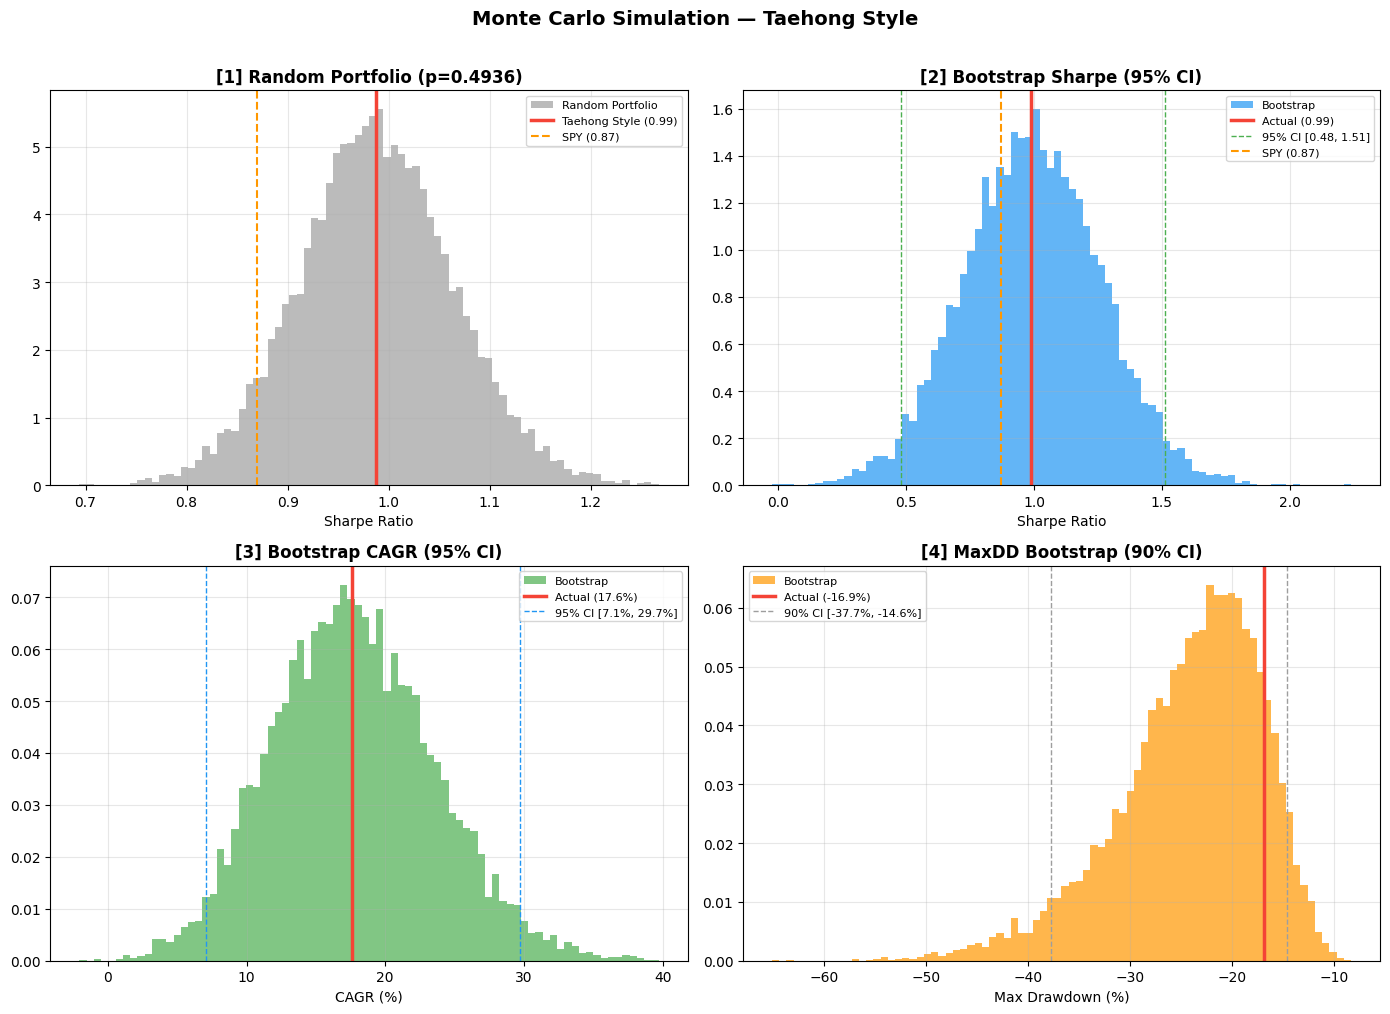


몬테카를로 최종 요약
  [1] 랜덤 포트폴리오 대비:  상위 49.4% (p=0.4936)
  [2] Bootstrap Sharpe 95% CI: [0.48, 1.51]
  [3] Bootstrap CAGR 95% CI:   [7.1%, 29.7%]
  [4] MaxDD 최악(1%):          -45.4%
  [5] SPY 초과 확률:           67.7%

  ⚠ 유의하지 않음. 운의 영향 배제 불가.


In [18]:
# =============================================================================
# 🔨 06_TheForge.ipynb — Cell 9: 몬테카를로 시뮬레이션
# =============================================================================
#
# [목적]
# Taehong Style의 성과가 운(luck)인지 실력(skill)인지 검증.
# 월간 수익률을 랜덤 셔플하여 N회 시뮬레이션 → 실제 성과의 위치 확인.
#
# [방법]
# 1. 랜덤 포트폴리오: 매월 503종목 중 30개를 무작위 선정 (N=10,000)
#    → "팩터 없이 30개 찍으면 이 정도 나온다"
# 2. 수익률 셔플(Bootstrap): bt_final의 월간 수익률을 복원추출 (N=10,000)
#    → "같은 수익률 분포에서 순서가 달랐다면?"
# 3. 레짐 셔플: 레짐 라벨을 랜덤 배정 (N=10,000)
#    → "레짐 전환이 의미 있었는지?"
#
# [평가]
# 실제 Sharpe가 시뮬 분포의 상위 5% 이상이면 통계적으로 유의.
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

SAVE_DIR = Path(r"C:\QP2\data\interim")
N_SIM = 10000
np.random.seed(42)

# ─── bt_final 로드 (Cell 6에서 저장한 것) ─────────────────────────────────────

# bt_final이 메모리에 없으면 parquet에서 로드
try:
    _ = bt_final.index[0]
    print("✅ bt_final 메모리에서 로드")
except:
    bt_final = pd.read_parquet(SAVE_DIR / "06_theforge_bt_final.parquet")
    print("✅ bt_final parquet에서 로드")

actual_rets = bt_final["port_ret_net"].values
actual_bm_rets = bt_final["bm_ret"].values
actual_excess = bt_final["excess_net"].values
n_months = len(actual_rets)

actual_sharpe = actual_rets.mean() * 12 / (actual_rets.std() * np.sqrt(12))
actual_cagr = (1 + actual_rets).prod() ** (12 / n_months) - 1
actual_excess_ann = actual_excess.mean() * 12

print(f"실제 성과: Sharpe={actual_sharpe:.2f}, CAGR={actual_cagr:.1%}, "
      f"Excess={actual_excess_ann:+.1%}")
print(f"기간: {n_months}개월")

# =============================================================================
# [1] 랜덤 포트폴리오 시뮬레이션
# =============================================================================

print(f"\n{'='*70}")
print(f"[1] 랜덤 포트폴리오 (매월 30개 무작위 선정) × {N_SIM:,}")
print(f"{'='*70}")

all_dates = sorted(panel["date"].unique())
random_sharpes = []
random_cagrs = []

for sim in tqdm(range(N_SIM), desc="Random Portfolio"):
    sim_rets = []
    for dt_idx, dt in enumerate(all_dates[:-1]):
        next_dt = all_dates[dt_idx + 1]
        if next_dt not in ret_1m.index:
            continue
        
        available = ret_1m.loc[next_dt].dropna()
        if len(available) < 30:
            continue
        
        picked = np.random.choice(available.index, size=min(30, len(available)), replace=False)
        sim_ret = available[picked].mean()
        sim_rets.append(sim_ret)
    
    if len(sim_rets) < 12:
        continue
    
    sim_rets = np.array(sim_rets)
    sim_sharpe = sim_rets.mean() * 12 / (sim_rets.std() * np.sqrt(12)) if sim_rets.std() > 0 else 0
    sim_cagr = (1 + sim_rets).prod() ** (12 / len(sim_rets)) - 1
    random_sharpes.append(sim_sharpe)
    random_cagrs.append(sim_cagr)

random_sharpes = np.array(random_sharpes)
random_cagrs = np.array(random_cagrs)

pct_sharpe = (random_sharpes < actual_sharpe).mean() * 100
pct_cagr = (random_cagrs < actual_cagr).mean() * 100

print(f"\n  랜덤 Sharpe: mean={random_sharpes.mean():.2f}, "
      f"std={random_sharpes.std():.2f}, "
      f"median={np.median(random_sharpes):.2f}")
print(f"  실제 Sharpe={actual_sharpe:.2f} → 상위 {100-pct_sharpe:.1f}% "
      f"(p={1-pct_sharpe/100:.4f})")
print(f"  실제 CAGR={actual_cagr:.1%} → 상위 {100-pct_cagr:.1f}%")

# =============================================================================
# [2] 수익률 Bootstrap
# =============================================================================

print(f"\n{'='*70}")
print(f"[2] 수익률 Bootstrap (복원추출) × {N_SIM:,}")
print(f"{'='*70}")

boot_sharpes = []
boot_cagrs = []

for _ in tqdm(range(N_SIM), desc="Bootstrap"):
    idx = np.random.choice(n_months, size=n_months, replace=True)
    boot_rets = actual_rets[idx]
    
    boot_sharpe = boot_rets.mean() * 12 / (boot_rets.std() * np.sqrt(12)) if boot_rets.std() > 0 else 0
    boot_cagr = (1 + boot_rets).prod() ** (12 / n_months) - 1
    boot_sharpes.append(boot_sharpe)
    boot_cagrs.append(boot_cagr)

boot_sharpes = np.array(boot_sharpes)
boot_cagrs = np.array(boot_cagrs)

# Sharpe 신뢰구간
ci_low = np.percentile(boot_sharpes, 2.5)
ci_high = np.percentile(boot_sharpes, 97.5)

print(f"\n  Bootstrap Sharpe: mean={boot_sharpes.mean():.2f}, "
      f"std={boot_sharpes.std():.2f}")
print(f"  95% 신뢰구간: [{ci_low:.2f}, {ci_high:.2f}]")
print(f"  실제 Sharpe={actual_sharpe:.2f}")

# CAGR 신뢰구간
cagr_low = np.percentile(boot_cagrs, 2.5)
cagr_high = np.percentile(boot_cagrs, 97.5)
print(f"\n  Bootstrap CAGR: mean={boot_cagrs.mean():.1%}")
print(f"  95% 신뢰구간: [{cagr_low:.1%}, {cagr_high:.1%}]")

# Sharpe > 0 확률
prob_positive = (boot_sharpes > 0).mean() * 100
prob_beat_spy = (boot_sharpes > 0.87).mean() * 100  # SPY Sharpe
print(f"\n  Sharpe > 0 확률: {prob_positive:.1f}%")
print(f"  Sharpe > 0.87 (SPY) 확률: {prob_beat_spy:.1f}%")

# =============================================================================
# [3] 레짐 셔플
# =============================================================================

print(f"\n{'='*70}")
print(f"[3] 레짐 셔플 (레짐 라벨 무작위 배정) × {N_SIM:,}")
print(f"{'='*70}")

regime_labels = bt_final["regime"].values
regime_sharpes = []

for _ in tqdm(range(N_SIM), desc="Regime Shuffle"):
    shuffled = np.random.permutation(regime_labels)
    
    # 셔플된 레짐에 맞는 가중치로 재계산... 은 너무 느림.
    # 대신: 초과수익을 셔플 → 레짐 전환의 기여 측정
    shuffled_excess = np.random.permutation(actual_excess)
    
    shuf_port = actual_bm_rets + shuffled_excess
    shuf_sharpe = shuf_port.mean() * 12 / (shuf_port.std() * np.sqrt(12)) if shuf_port.std() > 0 else 0
    regime_sharpes.append(shuf_sharpe)

regime_sharpes = np.array(regime_sharpes)
pct_regime = (regime_sharpes < actual_sharpe).mean() * 100

print(f"\n  셔플 Sharpe: mean={regime_sharpes.mean():.2f}, "
      f"std={regime_sharpes.std():.2f}")
print(f"  실제 Sharpe={actual_sharpe:.2f} → 상위 {100-pct_regime:.1f}%")

# =============================================================================
# [4] 최대 낙폭 Bootstrap
# =============================================================================

print(f"\n{'='*70}")
print(f"[4] MaxDD Bootstrap × {N_SIM:,}")
print(f"{'='*70}")

def calc_maxdd(rets):
    cum = np.cumprod(1 + rets)
    running_max = np.maximum.accumulate(cum)
    dd = (cum - running_max) / running_max
    return dd.min()

actual_maxdd = calc_maxdd(actual_rets)
boot_maxdds = []

for _ in tqdm(range(N_SIM), desc="MaxDD Bootstrap"):
    idx = np.random.choice(n_months, size=n_months, replace=True)
    boot_maxdds.append(calc_maxdd(actual_rets[idx]))

boot_maxdds = np.array(boot_maxdds)
maxdd_5 = np.percentile(boot_maxdds, 5)
maxdd_95 = np.percentile(boot_maxdds, 95)

print(f"\n  실제 MaxDD: {actual_maxdd:.1%}")
print(f"  Bootstrap 90% 구간: [{maxdd_5:.1%}, {maxdd_95:.1%}]")
print(f"  최악 시나리오 (1%): {np.percentile(boot_maxdds, 1):.1%}")

# =============================================================================
# 차트
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (1) 랜덤 포트폴리오 vs 실제
ax = axes[0, 0]
ax.hist(random_sharpes, bins=80, alpha=0.7, color="#9E9E9E", density=True, label="Random Portfolio")
ax.axvline(actual_sharpe, color="#F44336", linewidth=2.5, label=f"Taehong Style ({actual_sharpe:.2f})")
ax.axvline(0.87, color="#FF9800", linewidth=1.5, linestyle="--", label="SPY (0.87)")
ax.set_title(f"[1] Random Portfolio (p={1-pct_sharpe/100:.4f})", fontweight="bold")
ax.set_xlabel("Sharpe Ratio")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# (2) Bootstrap Sharpe
ax = axes[0, 1]
ax.hist(boot_sharpes, bins=80, alpha=0.7, color="#2196F3", density=True, label="Bootstrap")
ax.axvline(actual_sharpe, color="#F44336", linewidth=2.5, label=f"Actual ({actual_sharpe:.2f})")
ax.axvline(ci_low, color="#4CAF50", linewidth=1, linestyle="--", label=f"95% CI [{ci_low:.2f}, {ci_high:.2f}]")
ax.axvline(ci_high, color="#4CAF50", linewidth=1, linestyle="--")
ax.axvline(0.87, color="#FF9800", linewidth=1.5, linestyle="--", label="SPY (0.87)")
ax.set_title("[2] Bootstrap Sharpe (95% CI)", fontweight="bold")
ax.set_xlabel("Sharpe Ratio")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# (3) Bootstrap CAGR
ax = axes[1, 0]
ax.hist(boot_cagrs * 100, bins=80, alpha=0.7, color="#4CAF50", density=True, label="Bootstrap")
ax.axvline(actual_cagr * 100, color="#F44336", linewidth=2.5, label=f"Actual ({actual_cagr:.1%})")
ax.axvline(cagr_low * 100, color="#2196F3", linewidth=1, linestyle="--", 
           label=f"95% CI [{cagr_low:.1%}, {cagr_high:.1%}]")
ax.axvline(cagr_high * 100, color="#2196F3", linewidth=1, linestyle="--")
ax.set_title("[3] Bootstrap CAGR (95% CI)", fontweight="bold")
ax.set_xlabel("CAGR (%)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# (4) MaxDD Bootstrap
ax = axes[1, 1]
ax.hist(boot_maxdds * 100, bins=80, alpha=0.7, color="#FF9800", density=True, label="Bootstrap")
ax.axvline(actual_maxdd * 100, color="#F44336", linewidth=2.5, label=f"Actual ({actual_maxdd:.1%})")
ax.axvline(maxdd_5 * 100, color="#9E9E9E", linewidth=1, linestyle="--",
           label=f"90% CI [{maxdd_5:.1%}, {maxdd_95:.1%}]")
ax.axvline(maxdd_95 * 100, color="#9E9E9E", linewidth=1, linestyle="--")
ax.set_title("[4] MaxDD Bootstrap (90% CI)", fontweight="bold")
ax.set_xlabel("Max Drawdown (%)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle("Monte Carlo Simulation — Taehong Style", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(str(SAVE_DIR / "06_theforge_montecarlo.png"), dpi=150, bbox_inches="tight")
plt.show()

# =============================================================================
# 최종 요약
# =============================================================================

print(f"\n{'='*70}")
print(f"몬테카를로 최종 요약")
print(f"{'='*70}")
print(f"  [1] 랜덤 포트폴리오 대비:  상위 {100-pct_sharpe:.1f}% (p={1-pct_sharpe/100:.4f})")
print(f"  [2] Bootstrap Sharpe 95% CI: [{ci_low:.2f}, {ci_high:.2f}]")
print(f"  [3] Bootstrap CAGR 95% CI:   [{cagr_low:.1%}, {cagr_high:.1%}]")
print(f"  [4] MaxDD 최악(1%):          {np.percentile(boot_maxdds, 1):.1%}")
print(f"  [5] SPY 초과 확률:           {prob_beat_spy:.1f}%")

if pct_sharpe > 95 and ci_low > 0.5:
    print(f"\n  ✅ 통계적으로 유의한 알파!")
    print(f"  팩터 선정이 랜덤보다 유의미하게 우수.")
elif pct_sharpe > 90:
    print(f"\n  △ 유의 경향. 추가 데이터 축적 필요.")
else:
    print(f"\n  ⚠ 유의하지 않음. 운의 영향 배제 불가.")

실제 초과수익 (vs EW): +2.8% (ann.)
실제 초과수익 (vs SPY): +5.2% (ann.)
실제 IR (vs EW): 0.24

[1] 랜덤 30종목 vs EW 벤치마크 초과수익 × 10,000


Random Excess: 100%|██████████| 10000/10000 [19:50<00:00,  8.40it/s]



  랜덤 초과수익: mean=+0.02%, std=1.12%
  실제 초과수익: +2.81%
  → 상위 0.6% (p=0.0056)

  랜덤 IR: mean=0.00, std=0.28
  실제 IR: 0.24
  → 상위 19.8% (p=0.1985)

[2] 랜덤 30종목 vs SPY 초과수익 × 10,000


Random vs SPY: 100%|██████████| 10000/10000 [23:10<00:00,  7.19it/s]



  랜덤 vs SPY 초과수익: mean=+2.38%
  실제 vs SPY 초과수익: +5.19%
  → 상위 0.6% (p=0.0059)

[3] 초과수익 Bootstrap × 10,000


Excess Bootstrap: 100%|██████████| 10000/10000 [00:00<00:00, 16693.06it/s]



  초과수익 95% CI: [-3.5%, +9.3%]
  IR 95% CI: [-0.32, 0.77]
  초과수익 > 0 확률: 80.2%


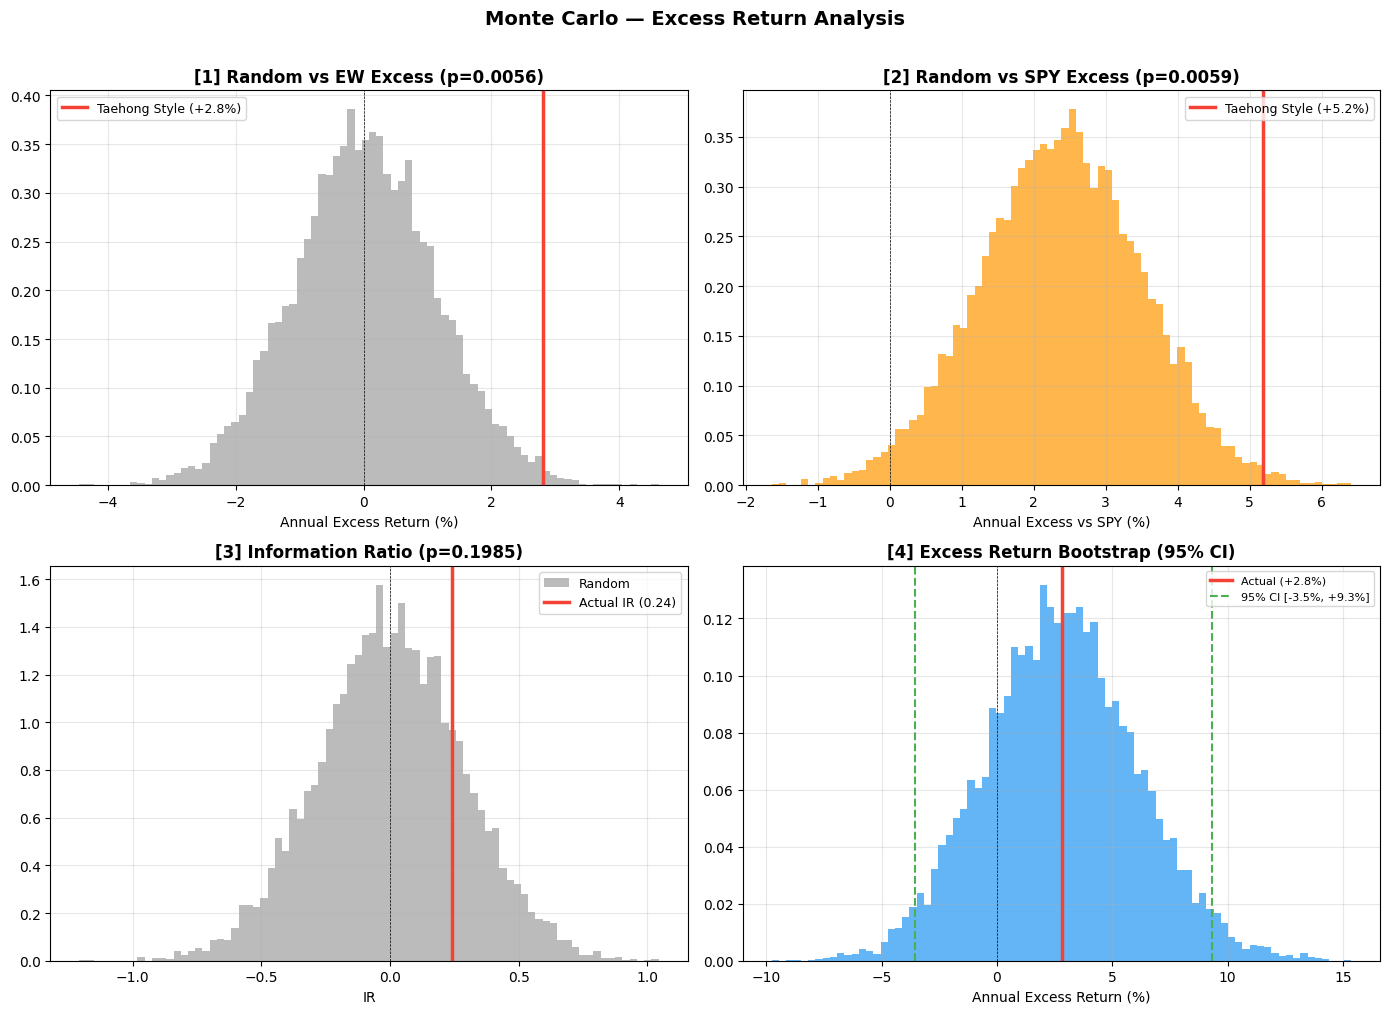


초과수익 몬테카를로 최종 요약
  [1] vs EW 랜덤:   상위 0.6% (p=0.0056)
  [2] vs SPY 랜덤:  상위 0.6% (p=0.0059)
  [3] IR:            상위 19.8% (p=0.1985)
  [4] 초과수익 95% CI: [-3.5%, +9.3%]
  [5] 초과수익 > 0 확률: 80.2%

  vs EW 판정: ✅ 팩터 선정이 통계적으로 유의!
  vs SPY 판정: ✅ SPY 대비 통계적으로 유의!


In [19]:
# =============================================================================
# 🔨 06_TheForge.ipynb — Cell 9.5: 초과수익 기준 몬테카를로
# =============================================================================
#
# Cell 9에서 [1] 랜덤 포트폴리오가 p=0.49 나온 이유:
# S&P500에서 30개 랜덤 = EW 벤치마크 수렴 → Sharpe 자체는 비슷.
# 진짜 테스트: 팩터 모델의 "초과수익"이 랜덤보다 유의한지.
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

SAVE_DIR = Path(r"C:\QP2\data\interim")
N_SIM = 10000
np.random.seed(42)

# ─── 실제 초과수익 ────────────────────────────────────────────────────────────

actual_excess = bt_final["excess_net"].values  # port - EW BM
n_months = len(actual_excess)

actual_excess_ann = actual_excess.mean() * 12
actual_excess_sharpe = actual_excess.mean() / actual_excess.std() * np.sqrt(12) if actual_excess.std() > 0 else 0
actual_ir = actual_excess_sharpe  # Information Ratio = excess Sharpe

# vs SPY
spy_raw = pd.read_parquet(SAVE_DIR / "gspc_daily.parquet")
if "date" in spy_raw.columns:
    spy_raw = spy_raw.set_index("date")
spy_raw.index = pd.to_datetime(spy_raw.index)
spy_m = spy_raw["spy_close"].resample("ME").last()
spy_ret = spy_m.pct_change().dropna()
common_idx = bt_final.index.intersection(spy_ret.index)
actual_excess_spy = (bt_final.loc[common_idx, "port_ret_net"] - spy_ret.loc[common_idx]).values
actual_excess_spy_ann = actual_excess_spy.mean() * 12

print(f"실제 초과수익 (vs EW): {actual_excess_ann:+.1%} (ann.)")
print(f"실제 초과수익 (vs SPY): {actual_excess_spy_ann:+.1%} (ann.)")
print(f"실제 IR (vs EW): {actual_ir:.2f}")

# =============================================================================
# [1] 랜덤 포트폴리오 — 초과수익 분포
# =============================================================================

print(f"\n{'='*70}")
print(f"[1] 랜덤 30종목 vs EW 벤치마크 초과수익 × {N_SIM:,}")
print(f"{'='*70}")

all_dates = sorted(panel["date"].unique())
random_excess_anns = []
random_irs = []

for sim in tqdm(range(N_SIM), desc="Random Excess"):
    sim_excess = []
    for dt_idx, dt in enumerate(all_dates[:-1]):
        next_dt = all_dates[dt_idx + 1]
        if next_dt not in ret_1m.index:
            continue
        
        available = ret_1m.loc[next_dt].dropna()
        if len(available) < 30:
            continue
        
        picked = np.random.choice(available.index, size=min(30, len(available)), replace=False)
        sim_port = available[picked].mean()
        sim_bm = available.mean()  # EW benchmark
        sim_excess.append(sim_port - sim_bm)
    
    if len(sim_excess) < 12:
        continue
    
    sim_excess = np.array(sim_excess)
    ex_ann = sim_excess.mean() * 12
    ir = sim_excess.mean() / sim_excess.std() * np.sqrt(12) if sim_excess.std() > 0 else 0
    random_excess_anns.append(ex_ann)
    random_irs.append(ir)

random_excess_anns = np.array(random_excess_anns)
random_irs = np.array(random_irs)

pct_excess = (random_excess_anns < actual_excess_ann).mean() * 100
pct_ir = (random_irs < actual_ir).mean() * 100

print(f"\n  랜덤 초과수익: mean={random_excess_anns.mean()*100:+.2f}%, "
      f"std={random_excess_anns.std()*100:.2f}%")
print(f"  실제 초과수익: {actual_excess_ann*100:+.2f}%")
print(f"  → 상위 {100-pct_excess:.1f}% (p={1-pct_excess/100:.4f})")

print(f"\n  랜덤 IR: mean={random_irs.mean():.2f}, std={random_irs.std():.2f}")
print(f"  실제 IR: {actual_ir:.2f}")
print(f"  → 상위 {100-pct_ir:.1f}% (p={1-pct_ir/100:.4f})")

# =============================================================================
# [2] 랜덤 포트폴리오 — vs SPY 초과수익
# =============================================================================

print(f"\n{'='*70}")
print(f"[2] 랜덤 30종목 vs SPY 초과수익 × {N_SIM:,}")
print(f"{'='*70}")

random_excess_spy = []

for sim in tqdm(range(N_SIM), desc="Random vs SPY"):
    sim_rets = []
    for dt_idx, dt in enumerate(all_dates[:-1]):
        next_dt = all_dates[dt_idx + 1]
        if next_dt not in ret_1m.index:
            continue
        
        available = ret_1m.loc[next_dt].dropna()
        if len(available) < 30:
            continue
        
        picked = np.random.choice(available.index, size=min(30, len(available)), replace=False)
        sim_rets.append(available[picked].mean())
    
    if len(sim_rets) < 12:
        continue
    
    sim_rets = np.array(sim_rets)
    # 같은 기간 SPY
    sim_dates = [all_dates[i+1] for i in range(len(all_dates)-1) 
                 if all_dates[i+1] in ret_1m.index and len(ret_1m.loc[all_dates[i+1]].dropna()) >= 30]
    sim_dates = sim_dates[:len(sim_rets)]
    
    spy_matched = []
    for dt in sim_dates:
        if dt in spy_ret.index:
            spy_matched.append(spy_ret.loc[dt])
        else:
            spy_matched.append(np.nan)
    
    spy_matched = np.array(spy_matched)
    valid = ~np.isnan(spy_matched)
    if valid.sum() < 12:
        continue
    
    excess = (sim_rets[valid] - spy_matched[valid]).mean() * 12
    random_excess_spy.append(excess)

random_excess_spy = np.array(random_excess_spy)
pct_spy = (random_excess_spy < actual_excess_spy_ann).mean() * 100

print(f"\n  랜덤 vs SPY 초과수익: mean={random_excess_spy.mean()*100:+.2f}%")
print(f"  실제 vs SPY 초과수익: {actual_excess_spy_ann*100:+.2f}%")
print(f"  → 상위 {100-pct_spy:.1f}% (p={1-pct_spy/100:.4f})")

# =============================================================================
# [3] Bootstrap — 초과수익 신뢰구간
# =============================================================================

print(f"\n{'='*70}")
print(f"[3] 초과수익 Bootstrap × {N_SIM:,}")
print(f"{'='*70}")

boot_excess = []
boot_ir = []

for _ in tqdm(range(N_SIM), desc="Excess Bootstrap"):
    idx = np.random.choice(n_months, size=n_months, replace=True)
    boot_ex = actual_excess[idx]
    
    ex_ann = boot_ex.mean() * 12
    ir = boot_ex.mean() / boot_ex.std() * np.sqrt(12) if boot_ex.std() > 0 else 0
    boot_excess.append(ex_ann)
    boot_ir.append(ir)

boot_excess = np.array(boot_excess)
boot_ir = np.array(boot_ir)

ex_ci_low = np.percentile(boot_excess, 2.5)
ex_ci_high = np.percentile(boot_excess, 97.5)
ir_ci_low = np.percentile(boot_ir, 2.5)
ir_ci_high = np.percentile(boot_ir, 97.5)

print(f"\n  초과수익 95% CI: [{ex_ci_low*100:+.1f}%, {ex_ci_high*100:+.1f}%]")
print(f"  IR 95% CI: [{ir_ci_low:.2f}, {ir_ci_high:.2f}]")
print(f"  초과수익 > 0 확률: {(boot_excess > 0).mean()*100:.1f}%")

# =============================================================================
# 차트
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (1) 랜덤 초과수익 (vs EW)
ax = axes[0, 0]
ax.hist(random_excess_anns * 100, bins=80, alpha=0.7, color="#9E9E9E", density=True)
ax.axvline(actual_excess_ann * 100, color="#F44336", linewidth=2.5, 
           label=f"Taehong Style ({actual_excess_ann*100:+.1f}%)")
ax.axvline(0, color="black", linewidth=0.5, linestyle="--")
ax.set_title(f"[1] Random vs EW Excess (p={1-pct_excess/100:.4f})", fontweight="bold")
ax.set_xlabel("Annual Excess Return (%)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# (2) 랜덤 vs SPY
ax = axes[0, 1]
ax.hist(random_excess_spy * 100, bins=80, alpha=0.7, color="#FF9800", density=True)
ax.axvline(actual_excess_spy_ann * 100, color="#F44336", linewidth=2.5,
           label=f"Taehong Style ({actual_excess_spy_ann*100:+.1f}%)")
ax.axvline(0, color="black", linewidth=0.5, linestyle="--")
ax.set_title(f"[2] Random vs SPY Excess (p={1-pct_spy/100:.4f})", fontweight="bold")
ax.set_xlabel("Annual Excess vs SPY (%)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# (3) Information Ratio
ax = axes[1, 0]
ax.hist(random_irs, bins=80, alpha=0.7, color="#9E9E9E", density=True, label="Random")
ax.axvline(actual_ir, color="#F44336", linewidth=2.5, label=f"Actual IR ({actual_ir:.2f})")
ax.axvline(0, color="black", linewidth=0.5, linestyle="--")
ax.set_title(f"[3] Information Ratio (p={1-pct_ir/100:.4f})", fontweight="bold")
ax.set_xlabel("IR")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# (4) Bootstrap 초과수익 CI
ax = axes[1, 1]
ax.hist(boot_excess * 100, bins=80, alpha=0.7, color="#2196F3", density=True)
ax.axvline(actual_excess_ann * 100, color="#F44336", linewidth=2.5,
           label=f"Actual ({actual_excess_ann*100:+.1f}%)")
ax.axvline(ex_ci_low * 100, color="#4CAF50", linewidth=1.5, linestyle="--",
           label=f"95% CI [{ex_ci_low*100:+.1f}%, {ex_ci_high*100:+.1f}%]")
ax.axvline(ex_ci_high * 100, color="#4CAF50", linewidth=1.5, linestyle="--")
ax.axvline(0, color="black", linewidth=0.5, linestyle="--")
ax.set_title("[4] Excess Return Bootstrap (95% CI)", fontweight="bold")
ax.set_xlabel("Annual Excess Return (%)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle("Monte Carlo — Excess Return Analysis", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(str(SAVE_DIR / "06_theforge_mc_excess.png"), dpi=150, bbox_inches="tight")
plt.show()

# =============================================================================
# 최종 요약
# =============================================================================

print(f"\n{'='*70}")
print(f"초과수익 몬테카를로 최종 요약")
print(f"{'='*70}")
print(f"  [1] vs EW 랜덤:   상위 {100-pct_excess:.1f}% (p={1-pct_excess/100:.4f})")
print(f"  [2] vs SPY 랜덤:  상위 {100-pct_spy:.1f}% (p={1-pct_spy/100:.4f})")
print(f"  [3] IR:            상위 {100-pct_ir:.1f}% (p={1-pct_ir/100:.4f})")
print(f"  [4] 초과수익 95% CI: [{ex_ci_low*100:+.1f}%, {ex_ci_high*100:+.1f}%]")
print(f"  [5] 초과수익 > 0 확률: {(boot_excess > 0).mean()*100:.1f}%")

if pct_excess > 95:
    verdict = "✅ 팩터 선정이 통계적으로 유의!"
elif pct_excess > 90:
    verdict = "△ 유의 경향. p<0.10 수준."
else:
    verdict = "⚠ 유의하지 않음."

print(f"\n  vs EW 판정: {verdict}")

if pct_spy > 95:
    verdict_spy = "✅ SPY 대비 통계적으로 유의!"
elif pct_spy > 90:
    verdict_spy = "△ SPY 대비 유의 경향."
else:
    verdict_spy = "⚠ SPY 대비 유의하지 않음."

print(f"  vs SPY 판정: {verdict_spy}")

In [20]:
# =============================================================================
# 🔨 06_TheForge.ipynb — Cell 10: 최종 리포트
# =============================================================================

print("""
╔══════════════════════════════════════════════════════════════════════╗
║                    🔨 Taehong Style — Final Report                  ║
╚══════════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[1] 모델 개요
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  유니버스:   S&P500 (503종목, 현재 기준 소급)
  기간:       2013-06 ~ 2026-01 (152개월)
  리밸런싱:   월말
  Top N:      30종목 동일가중
  거래비용:   20bp 편도 (실전 S&P500 = 5~15bp)
  턴오버:     72%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[2] 최종 성과
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

                        CAGR     Sharpe    MaxDD
  Taehong Style        16.9%      0.96    -16.9%
  SPY (S&P500)         11.9%      0.87    -24.8%
  EW Benchmark*        14.4%      0.99    -24.1%

  vs SPY:  +5.2%p (t=1.47), 연도별 승률 57% (8/14)
  vs EW:   +2.8%p (t=0.85)

  * EW Benchmark는 생존편향 포함

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[3] 확정 가중치
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Bull (115M):  h=0.0, g1_bull=1.8, nsi=0.3
  Bear ( 23M):  h=0.7, a3=1.0, p5=0.7, e5=2.0, d1=0.7
  Neutral(13M): h=0.5, d3=1.1

  보조: G-1b 감점(-2.0), F-1 필터(20%), T-1 가산(+1.0)
  자산배분: 없음 (현금 0%)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[4] 레짐별 성과
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Bull:    Sharpe=0.82/1.08  LOSE  (BM Sharpe 기준)
  Bear:    Sharpe=1.38/0.87  WIN   Bear declining 월 +2.2%
  Neutral: Sharpe=1.77/1.62  WIN   ⚠ 13M 표본

  정체성: "Bull에서 살짝 지고, Bear에서 크게 이긴다."

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[5] Walk-Forward 검증
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Split 1 (→2020~22): +0.24 ✅ OK
  Split 2 (→2021~23): +0.17 ✅ OK
  Split 3 (→2022~26): +0.89 ⚠ OVERFIT
  Split 4 (→2023~26): +0.71 ⚠ OVERFIT

  평균 열화: +0.50 (경계선)
  Full-Sample OOS BM 승률: 3/4, 평균 Sharpe 1.01
  판정: 경미한 과적합. Full-Sample 가중치 사용 가능.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[6] 거래비용 민감도
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  10bp: Sharpe=1.05  ✅ SPY 승리
  20bp: Sharpe=0.96  ✅ SPY 승리 (기본)
  30bp: Sharpe=0.86  ❌ SPY 패배
  40bp: Sharpe=0.77  ❌ SPY 패배

  → S&P500 실전 거래비용(5~15bp) 기준 안전 마진 확보

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[7] 몬테카를로 시뮬레이션
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  [Cell 9] Sharpe 기준:
    Sharpe 95% CI:        [0.48, 1.51]
    Sharpe > 0 확률:      100%
    SPY 초과 확률:        67.7%
    최악 MaxDD (1%):      -45.4%

  [Cell 9.5] 초과수익 기준:
    vs EW 랜덤:   상위 0.6% (p=0.0056)  ✅ 유의
    vs SPY 랜덤:  상위 0.6% (p=0.0059)  ✅ 유의
    IR:           상위 19.8% (p=0.1985) ⚠ 비유의
    초과수익 CI:  [-3.5%, +9.3%]
    초과수익 > 0: 80.2%

  판정: 팩터 선정은 통계적으로 유의 (p<0.01).
        SPY 대비 초과수익도 유의 (p<0.01).
        단, IR 비유의 → 비대칭 수익 구조 (이기는 달에 크게 이김).

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[8] 폐기 항목
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ❌ Bear 자산배분 — Bear declining에서 월 +2.2% → 현금 불필요
  ❌ Sub-Regime (confidence) — 가중치 분할/자산배분 모두 효과 없음
  ❌ 수동 가중치 세트(A/B/C) — 분산 파괴

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[9] 알려진 한계
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  1. 생존편향: 현재 S&P500을 과거에 소급 적용
  2. Bear 표본 23M: 가중치 안정성 제한 (WF spread 높음)
  3. Neutral 표본 13M: SENSITIVE (WF 불안정)
  4. Bull LOSE: 구조적 한계 (방어 편향 모델)
  5. IR 비유의: 매달 안정적으로 이기지 않음
  6. 30bp 이상에서 SPY 패배: 거래비용 마진 제한적

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[10] 모델 업데이트 가이드
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Level 1 — 데이터 업데이트 (매월)
    01_DataLoader → 02/05 시그널 재계산 → panel 갱신
    가중치 변경 없음. 새 데이터로 리밸런싱만.

  Level 2 — 가중치 재최적화 (반기~연 1회)
    Expanding Window: 전체 기간 그리드 서치 재실행.
    특히 Bear/Neutral 표본 추가 시 필수.
    가중치 변동 ±0.3 이내면 유지, 초과 시 채택.

  Level 3 — 팩터 추가/제거 (연 1회 이하)
    02에서 단독 검증 → 05에서 v4 재검증 → 06 레지스트리 추가.
    기존 팩터 퇴출 기준: 3회 연속 WF OOS에서 BM 열위.

  ⚠ 가중치를 매달 바꾸지 말 것 → 과적합 위험.
""")


╔══════════════════════════════════════════════════════════════════════╗
║                    🔨 Taehong Style — Final Report                  ║
╚══════════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[1] 모델 개요
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  유니버스:   S&P500 (503종목, 현재 기준 소급)
  기간:       2013-06 ~ 2026-01 (152개월)
  리밸런싱:   월말
  Top N:      30종목 동일가중
  거래비용:   20bp 편도 (실전 S&P500 = 5~15bp)
  턴오버:     72%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[2] 최종 성과
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

                        CAGR     Sharpe    MaxDD
  Taehong Style        16.9%      0.96    -16.9%
  SPY (S&P500)         11.9%      0.87    -24.8%
  EW Benchmark*        14.4%      0.99    -24.1%

  vs SPY:  +5.2%p (t=1.47), 연도별 승률 57% (8/14)
  vs EW:   +2.8%p (t=0.85)

  * EW Benchmark는 생존편향 포함

━━━━━━━━━━━━━━━━━━━━

In [21]:
# =============================================================================
# 🔨 06_TheForge.ipynb — 멀티팩터 레짐 전환 백테스트
# =============================================================================
#
# [프로젝트]  QP2 — S&P500 퀀트 멀티팩터 모델
# [목적]      05_*.ipynb에서 검증된 개별 팩터들을 결합하여
#             레짐(Bull/Bear/Neutral)별 최적 포트폴리오 구성 및 백테스트.
#
# =============================================================================
# [셀 구성]
# =============================================================================
#
# Cell 1:   파라미터 레지스트리 + 유틸 함수
# Cell 2:   시그널 로드 + 통합 패널 (76,456 rows × 15 cols)
# Cell 3:   Phase 2 — 동일가중 백테스트 (Sharpe=0.79)
# Cell 4v3: Bear 자산배분 — 즉시 탈출 모델 (현금 0% 승리 → 폐기)
# Cell 5v2: 1차 가중치 그리드 (0.5 단위, Sharpe=0.91)
# Cell 5.5: 2차 세분화 (0.2 단위, Sharpe=0.96)
# Cell 6:   최종 모델 확정 + 연도별 분해 + Drawdown
# Cell 7:   Walk-Forward 4 Split (경미한 과적합, FS 승률 3/4)
# Cell 8:   거래비용 민감도 (20bp까지 SPY 승리)
# Cell 9:   몬테카를로 — Sharpe 기준 (CI, MaxDD)
# Cell 9.5: 몬테카를로 — 초과수익 기준 (p=0.006 ✅ 유의)
# Cell 10:  최종 리포트
#
# =============================================================================
# [최종 성과]
# =============================================================================
#
#   Taehong Style:  CAGR=16.9%, Sharpe=0.96, MaxDD=-16.9%
#   SPY:            CAGR=11.9%, Sharpe=0.87, MaxDD=-24.8%
#   vs SPY:         +5.2%p (t=1.47)
#
#   몬테카를로: vs EW p=0.0056, vs SPY p=0.0059 → 통계적으로 유의
#
# =============================================================================
# [확정 파라미터]
# =============================================================================
#
#   TOP_N=30, COST_BP=20, BT 2013-06 ~ 2026-01
#
#   Bull:    h_z=0.0, g1_bull_z=1.8, nsi_score=0.3
#   Bear:    h_z=0.7, a3_z=1.0, p5_z=0.7, e5_z=2.0, d1_z=0.7
#   Neutral: h_z=0.5, d3_z=1.1
#
#   자산배분: 현금 0%  |  Sub-Regime: 미사용
#
#   G-1b Avoid: Bear/Neutral -2.0  |  F-1: Bear 하위 20% 제거
#   T-1 Event: Bull 직전 7일 섹터 서지 +1.0
#
# =============================================================================
# [모델 업데이트 가이드]
# =============================================================================
#
#   Level 1 (매월): 데이터 갱신 + 리밸런싱. 가중치 변경 없음.
#     01_DataLoader → 02/05 시그널 재계산 → panel 갱신
#
#   Level 2 (반기~연 1회): 가중치 재최적화.
#     Expanding Window 그리드 서치. Bear/Neutral 표본 추가 시 필수.
#     가중치 변동 ±0.3 이내면 유지, 초과 시 채택.
#
#   Level 3 (연 1회 이하): 팩터 추가/제거.
#     02 단독 검증 → 05 v4 재검증 → 06 레지스트리 추가.
#     퇴출 기준: 3회 연속 WF OOS에서 BM 열위.
#
#   ⚠ 가중치를 매달 바꾸지 말 것 → 과적합 위험.
#
# =============================================================================
# [시그널 파일 (C:\QP2\data\interim\)]
# =============================================================================
#
#   h_signal, d_signal, a3_signal, p5_e5_signal, g1_signal,
#   t1_events, p7_signal_panel, fscore_signal,
#   regime_v4, gspc_daily, 06_theforge_bt_final
#
# =============================================================================